# 🏞️ **Water Quality Prediction and Contamination Detection using **Machine** Learning**

## 🎛️ **Preliminaries**

In [1]:
# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Data manipulation and analysis
import numpy as np  
import pandas as pd

# Feature preprocessing and data splitting
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Machine Learning & Deep Learning
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from torch.utils.data import DataLoader, TensorDataset
import torch
import torch.nn as nn
import torch.optim as optim
import xgboost as xgb
import lightgbm
import pickle

# Others
from tqdm import tqdm
import random
import copy
import os

# Planetary Computer tools
from odc.stac import stac_load
import planetary_computer

# Google Cloud
from google.cloud import bigquery

# Model Interpretation
import shap

In [2]:
base_dir = os.path.dirname(os.getcwd())
print(f"Base directory: {base_dir}")

data_dir = os.path.join(base_dir, "data")
model_dir = os.path.join(base_dir, "model")
os.makedirs(data_dir, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)

Base directory: /Users/nqb/Documents/water-quality-prediction-contamination-assessment


In [ ]:
# gcloud init
# gcloud auth application-default login

zsh:1: command not found: gcloud


In [3]:
client = bigquery.Client()

# Query final processed dataset
query = """
SELECT *
FROM `river-water-quality-prediction.river_water_quality_dataset.final_river_water_quality`
"""

# Load into pandas dataframe
Cleaned_River_Water_Quality_df = client.query(query).to_dataframe()

data_path = os.path.join(data_dir, "final_river_water_quality.csv")

# Save locally inside workbench
Cleaned_River_Water_Quality_df.to_csv(data_path, index=False)

print(f"Dataset saved to: {data_path}")
print(Cleaned_River_Water_Quality_df.shape)

Dataset saved to: /Users/nqb/Documents/water-quality-prediction-contamination-assessment/data/final_river_water_quality.csv
(35431, 34)


In [4]:
Cleaned_River_Water_Quality_df.head(10)

,River,Date,Latitude,Longitude,EC,Temp_C,SS_mgL,pH,TP_mgL,NO2_N_mgL,...,red,blue,Country,NDVI,NDWI,MNDWI,NDBI,NDMI,NDTI,WQI
0,Mui Wo River,2005-05-12,22.265083,113.993833,30304.0,25.7,4.0,7.5,0.07,0.023,...,9936.0,9515.5,Hong Kong,0.736694,0.0,0.607156,-0.607156,0.607156,-0.736694,58.476165
1,Mui Wo River,2006-05-25,22.265083,113.993833,21510.0,28.3,24.0,7.0,0.15,0.016,...,65535.0,65535.0,Hong Kong,0.000000,0.0,0.565146,-0.565146,0.565146,0.000000,60.933158
2,Mui Wo River,2006-04-21,22.265083,113.993833,44204.0,25.3,12.0,7.4,0.08,0.010,...,65535.0,65535.0,Hong Kong,0.000000,0.0,0.565146,-0.565146,0.565146,0.000000,54.304389
3,Mui Wo River,2006-06-28,22.265083,113.993833,22166.0,28.2,7.4,7.6,0.10,0.014,...,65535.0,65535.0,Hong Kong,0.000000,0.0,0.565146,-0.565146,0.565146,0.000000,62.530367
4,Mui Wo River,2009-06-10,22.265083,113.993833,12222.0,27.8,54.0,8.0,0.13,0.012,...,9987.0,9315.5,Hong Kong,0.735521,0.0,0.564361,-0.564361,0.564361,-0.735521,64.919309
5,Mui Wo River,2003-05-26,22.265083,113.993833,7318.0,31.5,12.0,7.4,0.16,0.012,...,65535.0,65535.0,Hong Kong,0.000000,0.0,0.531022,-0.531022,0.531022,0.000000,78.955818
6,Mui Wo River,2003-06-12,22.265083,113.993833,3032.0,27.1,9.8,6.9,0.16,0.006,...,10262.0,10028.0,Hong Kong,0.729224,0.0,0.531022,-0.531022,0.531022,-0.729224,89.220172
7,Mui Wo River,2011-03-10,22.265083,113.993833,35729.0,17.7,7.8,7.1,0.08,0.015,...,10319.0,9539.5,Hong Kong,0.727925,0.0,0.408257,-0.408257,0.408257,-0.727925,56.553919
8,Mui Wo River,2011-04-13,22.265083,113.993833,26181.0,26.5,7.4,7.6,0.11,0.014,...,65535.0,65535.0,Hong Kong,0.000000,0.0,0.408257,-0.408257,0.408257,0.000000,60.309939
9,Mui Wo River,2005-04-15,22.265083,113.993833,42076.0,21.1,2.7,7.8,0.06,0.026,...,65535.0,65535.0,Hong Kong,0.000000,0.0,0.397454,-0.397454,0.397454,0.000000,54.801912


In [5]:
print(Cleaned_River_Water_Quality_df.isna().sum())

River        0
Date         0
Latitude     0
Longitude    0
EC           0
Temp_C       0
SS_mgL       0
pH           0
TP_mgL       0
NO2_N_mgL    0
NO3_N_mgL    0
DO_mgL       0
Al_mgL       0
Fe_mgL       0
Mn_mgL       0
Zn_mgL       0
Cu_mgL       0
Chl_a_mgL    0
lat_round    0
lon_round    0
nir          0
green        0
swir16       0
swir22       0
red          0
blue         0
Country      0
NDVI         0
NDWI         0
MNDWI        0
NDBI         0
NDMI         0
NDTI         0
WQI          0
dtype: int64


In [6]:
# Hong Kong Dataset
Hong_Kong_River_Water_Quality_df = (Cleaned_River_Water_Quality_df[Cleaned_River_Water_Quality_df["Country"] == "Hong Kong"].copy().reset_index(drop=True))

# England Dataset
England_River_Water_Quality_df = (Cleaned_River_Water_Quality_df[Cleaned_River_Water_Quality_df["Country"] == "England"].copy().reset_index(drop=True))

print("Hong Kong shape:", Hong_Kong_River_Water_Quality_df.shape)
print("England shape:", England_River_Water_Quality_df.shape)

print(Hong_Kong_River_Water_Quality_df["Country"].value_counts())

print(England_River_Water_Quality_df["Country"].value_counts())

Hong Kong shape: (22724, 34)
England shape: (12707, 34)
Country
Hong Kong    22724
Name: count, dtype: int64
Country
England    12707
Name: count, dtype: int64


In [7]:
SEED = 42

def set_seed(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    try:
        torch.use_deterministic_algorithms(True)
        
    except Exception:
        pass


set_seed(SEED)

device = torch.device("cpu")

print(f"Seed: {SEED}")
print(f"Using device: {device}")

Seed: 42
Using device: cpu


In [8]:
df_features = Cleaned_River_Water_Quality_df.copy()

# Drop unused columns
cols_to_drop = ["River", "Date", "Year", "Country", 
                "Latitude", "Longitude", "lat_round", "lon_round"
]
df_features = df_features.drop(columns=[col for col in cols_to_drop if col in df_features.columns])

feature_names = [col for col in df_features.columns if col != "WQI"]

feature_names

['EC',
 'Temp_C',
 'SS_mgL',
 'pH',
 'TP_mgL',
 'NO2_N_mgL',
 'NO3_N_mgL',
 'DO_mgL',
 'Al_mgL',
 'Fe_mgL',
 'Mn_mgL',
 'Zn_mgL',
 'Cu_mgL',
 'Chl_a_mgL',
 'nir',
 'green',
 'swir16',
 'swir22',
 'red',
 'blue',
 'NDVI',
 'NDWI',
 'MNDWI',
 'NDBI',
 'NDMI',
 'NDTI']

### ⚙️ **Helper Function**

In [9]:
def train_benchmark_ML_model(model, model_name, model_type,
                             dataset_name, X_train, y_train
):
    """
    Train and save a machine learning benchmark model.

    Supported benchmark models:
    - XGBoost
    - LightGBM

    Parameters
    ----------
    model :
        Initialized regression model.

    model_name : str
        Descriptive model name, e.g. "XGBoost" or "LightGBM".

    model_type : str
        Either "xgboost" or "lightgbm".
        
    dataset_name : str
        Dataset identifier,
        e.g. "hongkong", "england", or "combined".

    X_train :
        Training feature matrix.

    y_train :
        Training target values.

    Returns
    -------
    model :
        Trained machine learning model.
    """
    model_type = model_type.lower()

    model_filename = (model_name.lower().replace(" ", "_").replace("-", "_"))
    dataset_filename = (dataset_name.lower().replace(" ", "_").replace("-", "_"))
    print(f"\n{'=' * 60}")
    print(f"Training {model_name} Benchmark Model")
    print(f"{'=' * 60}")

    # Train model
    model.fit(X_train, y_train)

    print(f"{model_name} training completed.")

    # Create model directory
    os.makedirs(model_dir, exist_ok=True)
    model_path = os.path.join(model_dir, f"{model_filename}_benchmark_{dataset_filename}.pkl")

    # Save model
    with open(model_path, "wb") as file:
        pickle.dump(model, file)

    print(f"{model_name} saved to:")
    print(model_path)

    return model

In [10]:
# Train Deep Learning Benchmark Model
def train_benchmark_DL_model(model, model_name, model_type, dataset_name,
                             train_loader, val_loader, device, epochs=100, patience=5
):
    """
    Train a deep learning benchmark model.

    Supported benchmark model:
    - DNN

    Parameters
    ----------
    model :
        Initialized PyTorch DNN model.

    model_name : str
        Descriptive model name, e.g. "DNN".

    model_type : str
        Must be "pytorch".

    dataset_name : str
        Dataset identifier, e.g.
        "HongKong", "England", or "Combined".

    train_loader :
        Training DataLoader.

    val_loader :
        Validation DataLoader.

    device :
        PyTorch training device.

    epochs : int
        Maximum number of training epochs.

    patience : int
        Early stopping patience.

    Returns
    -------
    model :
        Best trained DNN model.

    train_losses :
        Training MSE loss history.

    val_losses :
        Validation MSE loss history.
    """
    model_type = model_type.lower()

    if model_type != "pytorch":
        raise ValueError(
            "train_benchmark_DL_model only supports "
            "model_type='pytorch'."
        )

    model_filename = (model_name.lower().replace(" ", "_").replace("-", "_"))
    dataset_filename = (dataset_name.lower().replace(" ", "_").replace("-", "_"))

    os.makedirs(model_dir, exist_ok=True)
    model_path = os.path.join(model_dir, f"{model_filename}_benchmark_{dataset_filename}.pth")

    # Training information    
    print(f"\n{'=' * 60}")
    print(f"Training {model_name} Benchmark Model")
    print(f"Dataset: {dataset_name}")
    print(f"Using device: {device}")
    print(f"{'=' * 60}")

    model = model.to(device)

    criterion = nn.MSELoss()

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_losses = []
    val_losses = []

    best_val_loss = float("inf")
    counter = 0

    for epoch in range(epochs):
        model.train()

        total_train_loss = 0.0
        total_train_samples = 0

        train_progress = tqdm(train_loader, desc=(f"Epoch {epoch + 1}/{epochs} " f"[Training]"), leave=False)

        for batch_X, batch_y in train_progress:

            batch_X = batch_X.to(device, dtype=torch.float32)
            batch_y = batch_y.to(device, dtype=torch.float32)

            if batch_y.ndim == 1:
                batch_y = batch_y.unsqueeze(1)

            optimizer.zero_grad()
            train_output = model(batch_X)

            # Ensure shape = (batch_size, 1)
            if isinstance(train_output, (tuple, list)):
                train_predictions = train_output[0]
            else:
                train_predictions = train_output

            if train_predictions.ndim == 1:
                train_predictions = train_predictions.unsqueeze(1)

            loss = criterion(train_predictions, batch_y)
            loss.backward()
            optimizer.step()

            batch_size = batch_X.size(0)

            total_train_loss += (loss.item() * batch_size)
            total_train_samples += (batch_size)

            train_progress.set_postfix(loss=loss.item())

        avg_train_loss = (total_train_loss / total_train_samples)

        train_losses.append(avg_train_loss)

        # VALIDATION
        model.eval()

        total_val_loss = 0.0
        total_val_samples = 0

        val_progress = tqdm(val_loader, desc=(f"Epoch {epoch + 1}/{epochs} " f"[Validation]"), leave=False)

        with torch.no_grad():
            for val_X, val_y in val_progress:

                val_X = val_X.to(device, dtype=torch.float32)
                val_y = val_y.to(device,dtype=torch.float32)

                if val_y.ndim == 1:
                    val_y = val_y.unsqueeze(1)

                val_output = model(val_X)

                if isinstance(val_output, (tuple, list)):
                    val_predictions = val_output[0]
                else:
                    val_predictions = val_output

                if val_predictions.ndim == 1:
                    val_predictions = val_predictions.unsqueeze(1)
                    
                loss = criterion(val_predictions, val_y)

                batch_size = val_X.size(0)

                total_val_loss += (loss.item() * batch_size)
                total_val_samples += (batch_size)

                val_progress.set_postfix(val_loss=loss.item())

        avg_val_loss = (total_val_loss / total_val_samples)

        val_losses.append(avg_val_loss)

        train_rmse_wqi = (np.sqrt(avg_train_loss)* 100.0)
        val_rmse_wqi = (np.sqrt(avg_val_loss)* 100.0)

        # Epoch summary
        print(
            f"Epoch [{epoch + 1}/{epochs}] | "
            f"Train Loss: {avg_train_loss:.6f} | "
            f"Val Loss: {avg_val_loss:.6f} | "
            f"Train RMSE: {train_rmse_wqi:.4f} WQI | "
            f"Val RMSE: {val_rmse_wqi:.4f} WQI"
        )

        # Early stopping
        if avg_val_loss < best_val_loss:

            best_val_loss = (avg_val_loss)

            counter = 0

            # Save best model
            torch.save(model.state_dict(), model_path)

            print(
                "Validation loss improved. "
                "Best model saved."
            )

        else:
            counter += 1

            print(
                f"Early Stopping Counter: "
                f"{counter}/{patience}"
            )

            if counter >= patience:
                print("Early stopping triggered.")
                break

    # Reload best model
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))

    model.eval()

    # Final summary
    best_val_rmse_wqi = (np.sqrt(best_val_loss) * 100.0)

    print(f"\n{'=' * 60}")
    print(f"{model_name} Training Complete")
    print(f"{'=' * 60}")

    print(
        f"Best Validation Loss: "
        f"{best_val_loss:.6f}"
    )

    print(
        f"Best Validation RMSE: "
        f"{best_val_rmse_wqi:.4f} WQI"
    )

    print(
        f"Model saved to: "
        f"{model_path}"
    )

    return (model, train_losses,val_losses)

In [11]:
# Evaluate Machine Learning Regression Model
def evaluate_ML_model(model, model_name, X_test, y_test, evaluation_name):
    """
    Evaluate a machine learning regression model.

    Suitable for:
    - LightGBM
    - XGBoost

    Parameters
    ----------
    model :
        Trained regression model.

    model_name : str
        Model name, e.g. "LightGBM".

    X_test :
        Unscaled test features.

    y_test :
        Original WQI target values (0-100).

    evaluation_name : str
        Description of evaluation setting.

    Returns
    -------
    y_pred :
        Predicted WQI values.

    rmse :
        Root Mean Squared Error.

    mae :
        Mean Absolute Error.

    r2 :
        R2 score.
    """
    # Prediction
    y_pred = model.predict(X_test)

    y_pred = np.asarray(y_pred).reshape(-1)
    y_test = np.asarray(y_test).reshape(-1)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\n{'=' * 60}")
    print(f"{model_name} Evaluation Results")
    print(f"Evaluation: {evaluation_name}")
    print(f"{'=' * 60}")

    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R2 Score: {r2:.4f}")
    print(f"Number of predictions: {len(y_pred)}")

    return (y_pred, rmse, mae, r2)

In [12]:
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score)

def evaluate_dnn_model(model, test_loader, device, dataset_name):
    model.eval()

    predictions = []
    actual_values = []

    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X = batch_X.to(device, dtype=torch.float32)

            outputs = model(batch_X)

            # Model output: 0-1
            # Convert back to WQI 0-100
            predictions.extend(outputs.cpu().numpy().reshape(-1)* 100.0)

            # Test target is also 0-1
            # Convert back to WQI 0-100
            actual_values.extend(batch_y.cpu().numpy().reshape(-1)* 100.0)

    y_pred = np.asarray(predictions)
    y_true = np.asarray(actual_values)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    r2 = r2_score(y_true, y_pred)

    print(f"DNN Evaluation Results for {dataset_name}:")

    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2 Score: {r2:.4f}")
    print(f"Number of predictions: {len(y_pred)}")

    return y_true, y_pred, rmse, mae, r2

In [13]:
# Plot Actual vs Predicted + Residual Distribution
def plot_model_residual_evaluation(y_true, y_pred, model_name,
                                   evaluation_name, color="crimson", sample_size=2000, random_state=SEED
):
    # Convert to NumPy
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    # Reproducible random sampling
    rng = np.random.default_rng(random_state)

    sample_size = min(sample_size,len(y_true))

    sample_idx = rng.choice(len(y_true), size=sample_size, replace=False)

    y_true_sample = y_true[sample_idx]
    y_pred_sample = y_pred[sample_idx]

    # Create plots
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: Actual vs Predicted
    axes[0].scatter(y_true_sample, y_pred_sample, alpha=0.4,
                    color=color, edgecolors="black"
    )

    min_val = min(y_true_sample.min(), y_pred_sample.min())
    max_val = max(y_true_sample.max(), y_pred_sample.max())

    axes[0].plot([min_val, max_val], [min_val, max_val], "r--", lw=2)
    axes[0].set_title(f"{model_name}: Actual vs Predicted\n{evaluation_name}", fontsize=14, fontweight="bold")

    axes[0].set_xlabel("Actual WQI Values", fontsize=12)
    axes[0].set_ylabel("Predicted WQI Values", fontsize=12)

    # Plot 2: Residual Distribution
    residuals = (y_true_sample - y_pred_sample)

    sns.histplot(residuals, kde=True, ax=axes[1], color=color, bins=40)

    axes[1].axvline(0, color="black", linestyle="--", lw=2)
    axes[1].set_title(f"{model_name}: Prediction Error (Residuals)\n" f"{evaluation_name}", fontsize=14, fontweight="bold")

    axes[1].set_xlabel("Error (Actual - Predicted)", fontsize=12)

    axes[1].set_ylabel("Frequency", fontsize=12)

    plt.tight_layout()
    plt.show()

In [14]:
# Plot ML Model Evaluation
# Actual vs Predicted + Feature Importance
def plot_model_importance_evaluation(y_true, y_pred, model, feature_names,
                                     model_name, evaluation_name, sample_size=2000, random_state=SEED
):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    rng = np.random.default_rng(random_state)

    sample_size = min(sample_size, len(y_true))

    sample_idx = rng.choice(len(y_true), size=sample_size, replace=False)

    y_true_sample = y_true[sample_idx]
    y_pred_sample = y_pred[sample_idx]

    sns.set_theme(style="whitegrid")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: Actual vs Predicted
    axes[0].scatter(y_true_sample, y_pred_sample, alpha=0.4,
                    color="darkorange", edgecolors="black"
    )

    min_val = min(y_true_sample.min(), y_pred_sample.min())
    max_val = max(y_true_sample.max(), y_pred_sample.max())

    axes[0].plot([min_val, max_val], [min_val, max_val], "r--", lw=2)

    axes[0].set_title(
        f"{model_name}: Actual vs Predicted\n"
        f"{evaluation_name}",
        fontsize=14,
        fontweight="bold"
    )

    axes[0].set_xlabel("Actual WQI Values", fontsize=12)
    axes[0].set_ylabel("Predicted WQI Values", fontsize=12)

    # Plot 2: Feature Importance
    if not hasattr(model, "feature_importances_"):
        raise AttributeError(
            f"{model_name} does not contain "
            "'feature_importances_'."
        )

    importances = model.feature_importances_

    feature_names = np.asarray(feature_names)

    if len(importances) != len(feature_names):
        raise ValueError(
            "Number of feature importance values does not "
            "match number of feature names."
        )

    indices = np.argsort(importances)[::-1]

    top_n = min(10, len(feature_names))

    top_features = feature_names[indices[:top_n]]
    top_importances = importances[indices[:top_n]]

    sns.barplot(x=top_importances, y=top_features, ax=axes[1], palette="magma")

    axes[1].set_title(
        f"{model_name}: Top {top_n} Feature Importances\n"
        f"{evaluation_name}",
        fontsize=14,
        fontweight="bold"
    )

    axes[1].set_xlabel("Relative Importance", fontsize=12)
    axes[1].set_ylabel("Features", fontsize=12)

    plt.tight_layout()
    plt.show()

### 🗂️ **Hong Kong Dataset**

In [15]:
df_hongkong = Hong_Kong_River_Water_Quality_df.copy()

# Drop unused columns
cols_to_drop = ["River", "Date", "Year", "Country", 
                "Latitude", "Longitude", "lat_round", "lon_round"
]

df_hongkong = df_hongkong.drop(columns=[col for col in cols_to_drop if col in df_hongkong.columns])

# Prepare features and target
X_hongkong = df_hongkong.drop(columns=["WQI"]).copy()
y_hongkong = df_hongkong["WQI"].copy()

print(f"Input shape: {X_hongkong.shape} | " f"Target shape: {y_hongkong.shape}")

Input shape: (22724, 26) | Target shape: (22724,)


In [16]:
# Train-test split for Hong Kong dataset
X_train_hongkong, X_test_hongkong_final, y_train_hongkong, y_test_hongkong_final = train_test_split(X_hongkong, y_hongkong, test_size=0.2, random_state=SEED)

X_train_hongkong_final, X_val_hongkong_final, y_train_hongkong_final, y_val_hongkong_final = train_test_split(X_train_hongkong, y_train_hongkong, test_size=0.1, random_state=SEED)

# Scale the features
scaler_hongkong = StandardScaler()

X_train_hongkong_final_scaled = scaler_hongkong.fit_transform(X_train_hongkong_final)
X_val_hongkong_final_scaled = scaler_hongkong.transform(X_val_hongkong_final)
X_test_hongkong_final_scaled = scaler_hongkong.transform(X_test_hongkong_final)

# Save scaler
with open(os.path.join(model_dir, "scaler_hongkong.pkl"), "wb") as file:
    pickle.dump(scaler_hongkong, file)

print(f"Training samples:   {X_train_hongkong_final_scaled.shape[0]}")
print(f"Validation samples: {X_val_hongkong_final_scaled.shape[0]}")
print(f"Testing samples:    {X_test_hongkong_final_scaled.shape[0]}")

Training samples:   16361
Validation samples: 1818
Testing samples:    4545


In [17]:
# Scale WQI for DNN
y_train_hongkong_final_scaled = y_train_hongkong_final / 100.0
y_val_hongkong_final_scaled = y_val_hongkong_final / 100.0
y_test_hongkong_final_scaled = y_test_hongkong_final / 100.0

In [18]:
# Tensor conversion for PyTorch
generator_hongkong = torch.Generator()
generator_hongkong.manual_seed(SEED)

# Train tensors
X_train_tensor_hongkong = torch.tensor(X_train_hongkong_final_scaled, dtype=torch.float32)
y_train_tensor_hongkong = torch.tensor(y_train_hongkong_final_scaled.to_numpy(), dtype=torch.float32).view(-1, 1)

# Val tensors
X_val_tensor_hongkong = torch.tensor(X_val_hongkong_final_scaled, dtype=torch.float32)
y_val_tensor_hongkong = torch.tensor(y_val_hongkong_final_scaled.to_numpy(), dtype=torch.float32).view(-1, 1)

# Test tensors
X_test_tensor_hongkong = torch.tensor(X_test_hongkong_final_scaled, dtype=torch.float32)
y_test_tensor_hongkong = torch.tensor(y_test_hongkong_final_scaled.to_numpy(), dtype=torch.float32).view(-1, 1)

# Train dataset
train_dataset_hongkong = TensorDataset(X_train_tensor_hongkong, y_train_tensor_hongkong)
val_dataset_hongkong = TensorDataset(X_val_tensor_hongkong, y_val_tensor_hongkong)
test_dataset_hongkong = TensorDataset(X_test_tensor_hongkong, y_test_tensor_hongkong)

# Train loader
train_loader_hongkong = DataLoader(train_dataset_hongkong, batch_size=256, shuffle=True, generator=generator_hongkong, num_workers=0)

# Val loader
val_loader_hongkong = DataLoader(val_dataset_hongkong, batch_size=256, shuffle=False, num_workers=0)

# Test loader
test_loader_hongkong = DataLoader(test_dataset_hongkong, batch_size=256, shuffle=False, num_workers=0)

# Used specifically for Hybrid DNN-XGBoost feature extraction
train_loader_extract_hongkong = DataLoader(train_dataset_hongkong, batch_size=256, shuffle=False, num_workers=0)

### 🗂️ **England Dataset**

In [19]:
df_england = England_River_Water_Quality_df.copy()

# Drop unused columns
cols_to_drop = ["River", "Date", "Year", "Country", 
                "Latitude", "Longitude", "lat_round", "lon_round"
]

df_england = df_england.drop(columns=[col for col in cols_to_drop if col in df_england.columns])

# Prepare features and target
X_england = df_england.drop(columns=["WQI"]).copy()
y_england = df_england["WQI"].copy()

print(f"Input shape: {X_england.shape} | " f"Target shape: {y_england.shape}")

Input shape: (12707, 26) | Target shape: (12707,)


In [20]:
# Train-test split for England dataset
X_train_england, X_test_england_final, y_train_england, y_test_england_final = train_test_split(X_england, y_england, test_size=0.2, random_state=SEED)

X_train_england_final, X_val_england_final, y_train_england_final, y_val_england_final = train_test_split(X_train_england, y_train_england, test_size=0.1, random_state=SEED)

# Scale the features
scaler_england = StandardScaler()

X_train_england_final_scaled = scaler_england.fit_transform(X_train_england_final)
X_val_england_final_scaled = scaler_england.transform(X_val_england_final)
X_test_england_final_scaled = scaler_england.transform(X_test_england_final)

# Save scaler
with open(os.path.join(model_dir, "scaler_england.pkl"), "wb") as file:
    pickle.dump(scaler_england, file)

print(f"Training samples:   {X_train_england_final_scaled.shape[0]}")
print(f"Validation samples: {X_val_england_final_scaled.shape[0]}")
print(f"Testing samples:    {X_test_england_final_scaled.shape[0]}")

Training samples:   9148
Validation samples: 1017
Testing samples:    2542


In [21]:
# Scale WQI for DNN
y_train_england_final_scaled = y_train_england_final / 100.0
y_val_england_final_scaled = y_val_england_final / 100.0
y_test_england_final_scaled = y_test_england_final / 100.0

In [22]:
# Tensor conversion for PyTorch
generator_england = torch.Generator()
generator_england.manual_seed(SEED)

# Train tensors
X_train_tensor_england = torch.tensor(X_train_england_final_scaled, dtype=torch.float32)
y_train_tensor_england = torch.tensor(y_train_england_final_scaled.to_numpy(), dtype=torch.float32).view(-1, 1)

# Val tensors
X_val_tensor_england = torch.tensor(X_val_england_final_scaled, dtype=torch.float32)
y_val_tensor_england = torch.tensor(y_val_england_final_scaled.to_numpy(), dtype=torch.float32).view(-1, 1)

# Test tensors
X_test_tensor_england = torch.tensor(X_test_england_final_scaled, dtype=torch.float32)
y_test_tensor_england = torch.tensor(y_test_england_final_scaled.to_numpy(), dtype=torch.float32).view(-1, 1)

# Train dataset
train_dataset_england = TensorDataset(X_train_tensor_england, y_train_tensor_england)
val_dataset_england = TensorDataset(X_val_tensor_england, y_val_tensor_england)
test_dataset_england = TensorDataset(X_test_tensor_england, y_test_tensor_england)

# Train loader
train_loader_england = DataLoader(train_dataset_england, batch_size=256, shuffle=True, generator=generator_england, num_workers=0)

# Val loader
val_loader_england = DataLoader(val_dataset_england, batch_size=256, shuffle=False, num_workers=0)

# Test loader
test_loader_england = DataLoader(test_dataset_england, batch_size=256, shuffle=False, num_workers=0)

# Used specifically for Hybrid DNN-XGBoost feature extraction
train_loader_extract_england = DataLoader(train_dataset_england, batch_size=256, shuffle=False, num_workers=0)

### 🗂️ **Combined Dataset**

In [23]:
# Combined Dataset
X_train_combined_final = pd.concat([X_train_hongkong_final, X_train_england_final], ignore_index=True)
y_train_combined_final = pd.concat([y_train_hongkong_final, y_train_england_final], ignore_index=True)

X_val_combined_final = pd.concat([X_val_hongkong_final, X_val_england_final], ignore_index=True)
y_val_combined_final = pd.concat([y_val_hongkong_final, y_val_england_final], ignore_index=True)

X_test_combined_final = pd.concat([X_test_hongkong_final, X_test_england_final], ignore_index=True)
y_test_combined_final = pd.concat([y_test_hongkong_final, y_test_england_final], ignore_index=True)

In [24]:
# Scale the features
scaler_combined = StandardScaler()

X_train_combined_final_scaled = scaler_combined.fit_transform(X_train_combined_final)
X_val_combined_final_scaled = scaler_combined.transform(X_val_combined_final)
X_test_combined_final_scaled = scaler_combined.transform(X_test_combined_final)

# Save scaler
with open(os.path.join(model_dir, "scaler_combined.pkl"), "wb") as file:
    pickle.dump(scaler_combined, file)

print(f"Training samples:   {X_train_combined_final_scaled.shape[0]}")
print(f"Validation samples: {X_val_combined_final_scaled.shape[0]}")
print(f"Testing samples:    {X_test_combined_final_scaled.shape[0]}")

Training samples:   25509
Validation samples: 2835
Testing samples:    7087


In [25]:
# Scale WQI for DNN
y_train_combined_final_scaled = y_train_combined_final / 100.0
y_val_combined_final_scaled = y_val_combined_final / 100.0
y_test_combined_final_scaled = y_test_combined_final / 100.0

In [26]:
# Tensor conversion for PyTorch
generator_combined = torch.Generator()
generator_combined.manual_seed(SEED)

# Train tensors
X_train_tensor_combined = torch.tensor(X_train_combined_final_scaled, dtype=torch.float32)
y_train_tensor_combined = torch.tensor(y_train_combined_final_scaled.to_numpy(), dtype=torch.float32).view(-1, 1)

# Val tensors
X_val_tensor_combined = torch.tensor(X_val_combined_final_scaled, dtype=torch.float32)
y_val_tensor_combined = torch.tensor(y_val_combined_final_scaled.to_numpy(), dtype=torch.float32).view(-1, 1)

# Test tensors
X_test_tensor_combined = torch.tensor(X_test_combined_final_scaled, dtype=torch.float32)
y_test_tensor_combined = torch.tensor(y_test_combined_final_scaled.to_numpy(), dtype=torch.float32).view(-1, 1)

# Train dataset
train_dataset_combined = TensorDataset(X_train_tensor_combined, y_train_tensor_combined)
val_dataset_combined = TensorDataset(X_val_tensor_combined, y_val_tensor_combined)
test_dataset_combined = TensorDataset(X_test_tensor_combined, y_test_tensor_combined)

# Train loader
train_loader_combined = DataLoader(train_dataset_combined, batch_size=256, shuffle=True, generator=generator_combined, num_workers=0)

# Val loader
val_loader_combined = DataLoader(val_dataset_combined, batch_size=256, shuffle=False, num_workers=0)

# Test loader
test_loader_combined = DataLoader(test_dataset_combined, batch_size=256, shuffle=False, num_workers=0)

# Used specifically for Hybrid DNN-XGBoost feature extraction
train_loader_extract_combined = DataLoader(train_dataset_combined, batch_size=256, shuffle=False, num_workers=0)

### 🗂️ **Hong Kong-Trained for England Dataset**

In [27]:
# Hong Kong-Trained -> England Dataset
X_test_hongkong_to_england_scaled = scaler_hongkong.transform(X_test_england_final)

# Neural-network targets remain scaled to 0-1
y_test_hongkong_to_england_scaled = (y_test_england_final / 100.0)

# Convert to tensors
X_test_tensor_hongkong_to_england = torch.tensor(X_test_hongkong_to_england_scaled,dtype=torch.float32)
y_test_tensor_hongkong_to_england = torch.tensor(y_test_hongkong_to_england_scaled.to_numpy(), dtype=torch.float32).view(-1, 1)

test_dataset_hongkong_to_england = TensorDataset(X_test_tensor_hongkong_to_england, y_test_tensor_hongkong_to_england)
test_loader_hongkong_to_england = DataLoader(test_dataset_hongkong_to_england, batch_size=256, shuffle=False, num_workers=0)

print("Hong Kong-trained -> England samples:",len(test_dataset_hongkong_to_england))
print(list(X_train_hongkong_final.columns) == list(X_test_england_final.columns))

Hong Kong-trained -> England samples: 2542
True


### 🗂️ **England-Trained for Hong Kong Dataset** 

In [28]:
# England-Trained -> Hong Kong Dataset
X_test_england_to_hongkong_scaled = scaler_england.transform(X_test_hongkong_final)

# Neural-network targets remain scaled to 0-1
y_test_england_to_hongkong_scaled = (y_test_hongkong_final / 100.0)

# Convert to tensors
X_test_tensor_england_to_hongkong = torch.tensor(X_test_england_to_hongkong_scaled,dtype=torch.float32)
y_test_tensor_england_to_hongkong = torch.tensor(y_test_england_to_hongkong_scaled.to_numpy(), dtype=torch.float32).view(-1, 1)

test_dataset_england_to_hongkong = TensorDataset(X_test_tensor_england_to_hongkong, y_test_tensor_england_to_hongkong)
test_loader_england_to_hongkong = DataLoader(test_dataset_england_to_hongkong, batch_size=256, shuffle=False, num_workers=0)

print("England-trained -> Hong Kong samples:",len(test_dataset_england_to_hongkong))
print(list(X_train_england_final.columns) == list(X_test_hongkong_final.columns))

England-trained -> Hong Kong samples: 4545
True


### 🗂️ **Combined-Trained for Hong Kong Dataset**

In [29]:
# Combined-Trained -> Hong Kong Dataset
X_test_combined_to_hongkong_scaled = scaler_combined.transform(X_test_hongkong_final)

# Neural-network targets remain scaled to 0-1
y_test_combined_to_hongkong_scaled = (y_test_hongkong_final / 100.0)

# Convert to tensors
X_test_tensor_combined_to_hongkong = torch.tensor(X_test_combined_to_hongkong_scaled, dtype=torch.float32)
y_test_tensor_combined_to_hongkong = torch.tensor(y_test_combined_to_hongkong_scaled.to_numpy(), dtype=torch.float32).view(-1, 1)

test_dataset_combined_to_hongkong = TensorDataset(X_test_tensor_combined_to_hongkong, y_test_tensor_combined_to_hongkong)
test_loader_combined_to_hongkong = DataLoader(test_dataset_combined_to_hongkong, batch_size=256, shuffle=False, num_workers=0)

print("Combined-trained -> Hong Kong samples:", len(test_dataset_combined_to_hongkong))
print(list(X_train_combined_final.columns) == list(X_test_hongkong_final.columns))

Combined-trained -> Hong Kong samples: 4545
True


### 🗂️ **Combined-Trained for England Dataset**

In [30]:
# Combined-Trained -> England Dataset
X_test_combined_to_england_scaled = scaler_combined.transform(X_test_england_final)

# Neural-network targets remain scaled to 0-1
y_test_combined_to_england_scaled = (y_test_england_final / 100.0)

# Convert to tensors
X_test_tensor_combined_to_england = torch.tensor(X_test_combined_to_england_scaled, dtype=torch.float32)
y_test_tensor_combined_to_england = torch.tensor(y_test_combined_to_england_scaled.to_numpy(), dtype=torch.float32).view(-1, 1)

test_dataset_combined_to_england = TensorDataset(X_test_tensor_combined_to_england, y_test_tensor_combined_to_england)
test_loader_combined_to_england = DataLoader(test_dataset_combined_to_england, batch_size=256, shuffle=False, num_workers=0)

print("Combined-trained -> England samples:", len(test_dataset_combined_to_england))
print(list(X_train_combined_final.columns) == list(X_test_england_final.columns))

Combined-trained -> England samples: 2542
True


## 📊 **Exploratory Data Analysis (EDA)**

### 📍 **In-Situ EDA**

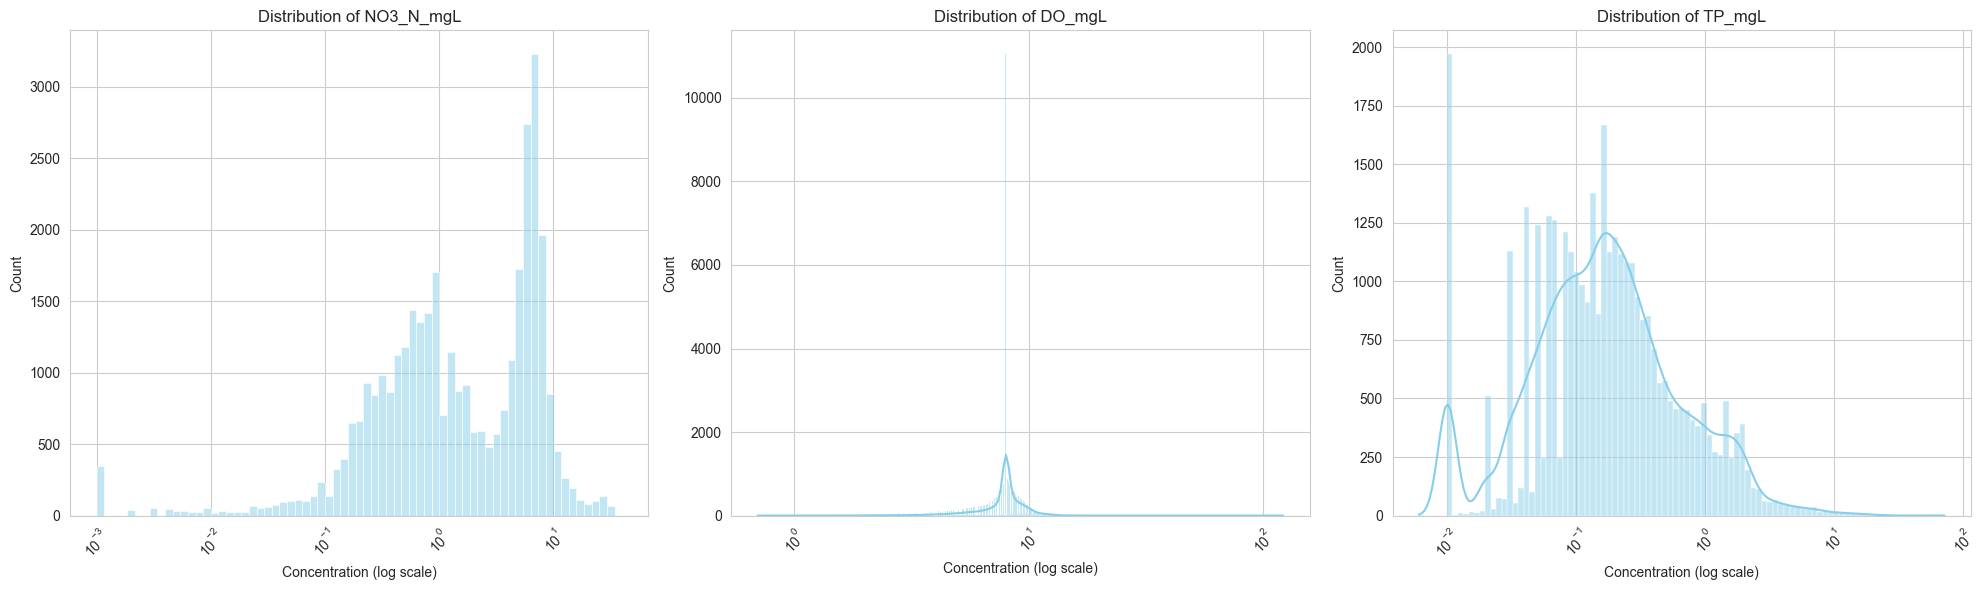

In [59]:
# Univariate Distribution Analysis This helps identify outliers and the distribution shape of key metrics
# Set plot style
sns.set_style("whitegrid")

# Select numeric columns
cols_to_plot = ['NO3_N_mgL', 'DO_mgL', 'TP_mgL']

# Create subplots with adjusted spacing
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, col in enumerate(cols_to_plot):
    if col in Cleaned_River_Water_Quality_df.columns:
        # Use log_scale=True to handle skewed water quality data
        # This makes the distribution visible instead of one giant spike
        sns.histplot(Cleaned_River_Water_Quality_df[col], kde=True, ax=axes[i], color='skyblue', log_scale=True)

        # Set title and labels
        axes[i].set_title(f'Distribution of {col}', fontsize=12)
        axes[i].set_xlabel('Concentration (log scale)')

        # Rotate x-axis labels to prevent overlap
        axes[i].tick_params(axis='x', rotation=45)

# Adjust layout
plt.tight_layout()
plt.show()

In [60]:
# Time Series Trend Analysis Observing how water quality metrics have evolved over the years
# Convert Date column to datetime
Cleaned_River_Water_Quality_df['Date'] = pd.to_datetime(Cleaned_River_Water_Quality_df['Date'], errors='coerce')

# Extract year and calculate the yearly average
Cleaned_River_Water_Quality_df['Year'] = Cleaned_River_Water_Quality_df['Date'].dt.year

# Group by Year and Country
yearly_country_avg = Cleaned_River_Water_Quality_df.groupby(['Year', 'Country'])[['NO3_N_mgL', 'DO_mgL', 'TP_mgL']].mean().reset_index()

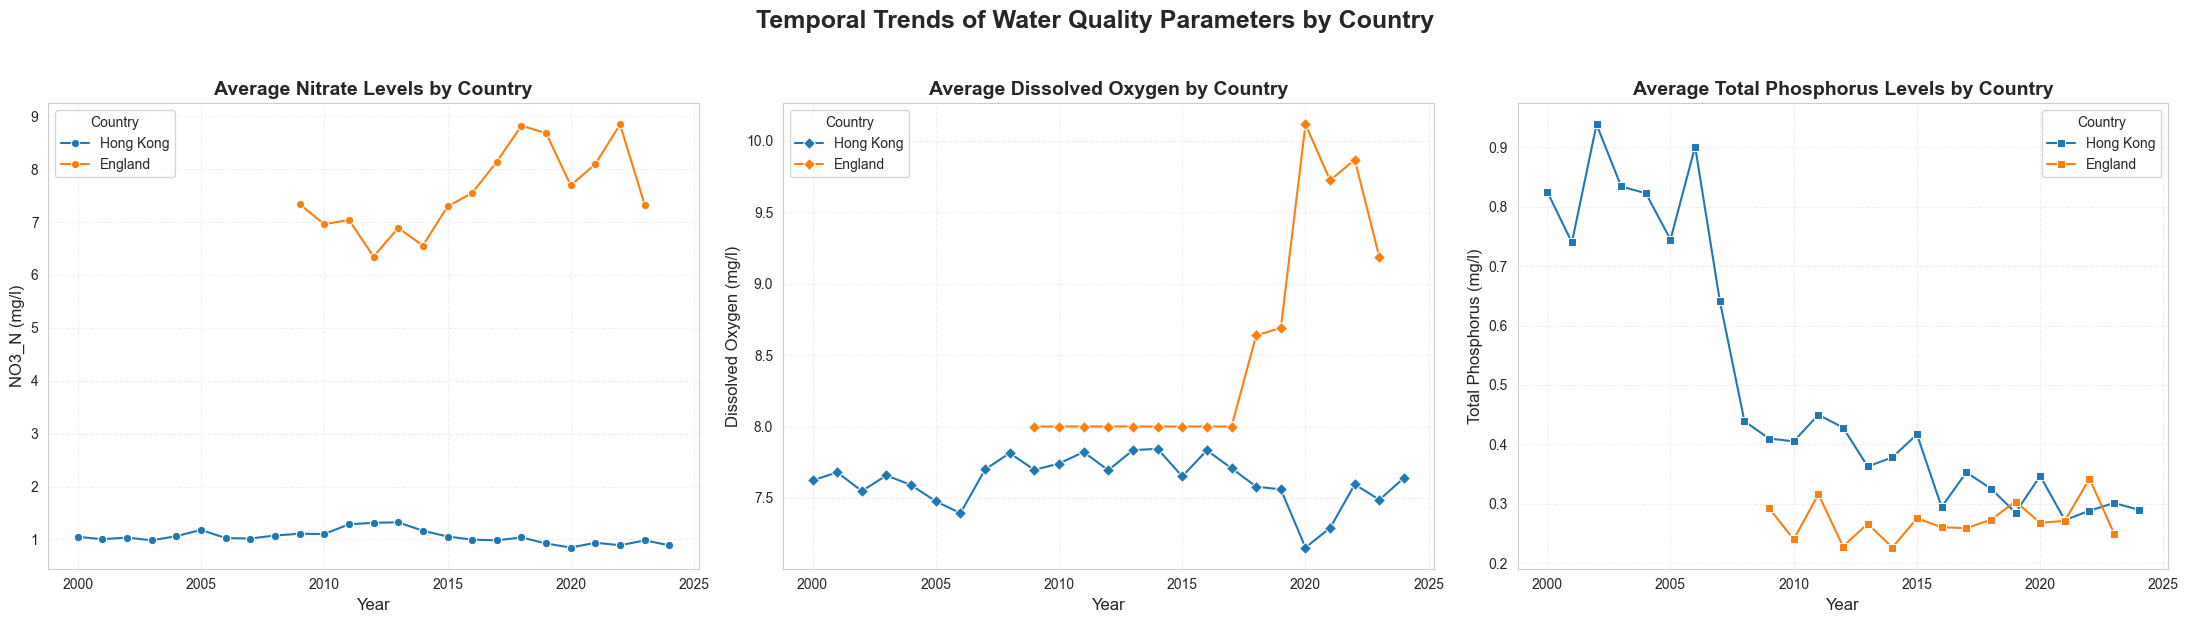

In [61]:
# Plot Trends
fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharex=True)

# --- Plot 1: Nitrate Trends ---
sns.lineplot(data=yearly_country_avg, x='Year', y='NO3_N_mgL',
             hue='Country', marker='o', ax=axes[0])

axes[0].set_title('Average Nitrate Levels by Country', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Year', fontsize=12)
axes[0].set_ylabel('NO3_N (mg/l)', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.3)

# --- Plot 2: Dissolved Oxygen Trends ---
sns.lineplot(data=yearly_country_avg, x='Year', y='DO_mgL',
             hue='Country', marker='D', ax=axes[1])

axes[1].set_title('Average Dissolved Oxygen by Country', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year', fontsize=12)
axes[1].set_ylabel('Dissolved Oxygen (mg/l)', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.3)

# --- Plot 3: Orthophosphate Trends ---
sns.lineplot(data=yearly_country_avg, x='Year', y='TP_mgL',
             hue='Country', marker='s', ax=axes[2])

axes[2].set_title('Average Total Phosphorus Levels by Country', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Year', fontsize=12)
axes[2].set_ylabel('Total Phosphorus (mg/l)', fontsize=12)
axes[2].grid(True, linestyle='--', alpha=0.3)

fig.suptitle(
    'Temporal Trends of Water Quality Parameters by Country',
    fontsize=18,
    fontweight='bold',
    y=1.03
)

plt.tight_layout()
plt.show()

### 🛰️ **Satellite EDA**

In [15]:
# Define the bounding box for the entire data region using (Latitude, Longitude)
sample = Cleaned_River_Water_Quality_df.sample(1)

# Extract lat and lon coordinates
lat = sample['Latitude'].values[0]
lon = sample['Longitude'].values[0]
date = pd.to_datetime(sample['Date'].values[0])

In [16]:
import pystac_client
import planetary_computer

stac = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace
)

In [17]:
for idx, row in Cleaned_River_Water_Quality_df.iterrows():

    # Define the bounding box for the entire data region using (Latitude, Longitude)
    lat = row["Latitude"]
    lon = row["Longitude"]
    date = pd.to_datetime(row["Date"])
    
    # Calculate the bounds for doing an archive data search
    # bounds = (min_lon, min_lat, max_lon, max_lat)
    bounds = (
        lon - 0.1,
        lat - 0.1,
        lon + 0.1,
        lat + 0.1
    )

    time_window = (
        f"{date.strftime('%Y-%m-%d')}/"
        f"{(date + pd.Timedelta(days=30)).strftime('%Y-%m-%d')}"
    )

    search_landsat = stac.search(
        collections=["landsat-c2-l2"],
        bbox=bounds,
        datetime=time_window,
        query={"eo:cloud_cover": {"lt": 10}},
        limit=10
    )

    items = list(search_landsat.items())

    if len(items) == 0:
        continue

    print("Scene found!")
    break

Scene found!


In [18]:
items_landsat = list(search_landsat.get_items())

print('This is the number of scenes that touch our region:',len(items_landsat))

This is the number of scenes that touch our region: 1


In [19]:
import planetary_computer

signed_items_landsat = [planetary_computer.sign(item) for item in items_landsat]

In [20]:
# Define the pixel resolution for the final product
# Define the scale according to our selected crs, so we will use degrees
resolution = 10  # meters per pixel
scale = resolution / 111320.0 # degrees per pixel for crs=4326

In [21]:
from odc.stac import stac_load

data_landsat = stac_load(
    signed_items_landsat,
    bands=["red", "green", "blue", "nir08", "swir16", "swir22"],
    crs="EPSG:4326",
    resolution=scale,
    chunks={"x": 2048, "y": 2048},
    dtype="uint16",
    patch_url=planetary_computer.sign,
    bbox=bounds
)

In [22]:
# View the dimensions of our XARRAY and the loaded variables
# This insures we have the right coordinates and spectral bands in our xarray
print(data_landsat)

<xarray.Dataset> Size: 60MB
Dimensions:      (latitude: 2228, longitude: 2227, time: 1)
Coordinates:
  * latitude     (latitude) float64 18kB 22.37 22.37 22.36 ... 22.17 22.17 22.17
  * longitude    (longitude) float64 18kB 113.9 113.9 113.9 ... 114.1 114.1
    spatial_ref  int32 4B 4326
  * time         (time) datetime64[ns] 8B 2005-05-24T02:33:42.125038
Data variables:
    red          (time, latitude, longitude) uint16 10MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    green        (time, latitude, longitude) uint16 10MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    blue         (time, latitude, longitude) uint16 10MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    nir08        (time, latitude, longitude) uint16 10MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    swir16       (time, latitude, longitude) uint16 10MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    swir22       (time, latitude, longitude) uint16 10MB dask.arra

In [23]:
# Persist the data in memory for faster operations
data_landsat = data_landsat.persist()

In [24]:
# Scale Factors for the RGB and NIR bands
scale = 0.0000275
offset = -0.2
data_landsat = data_landsat.astype(float) * scale + offset

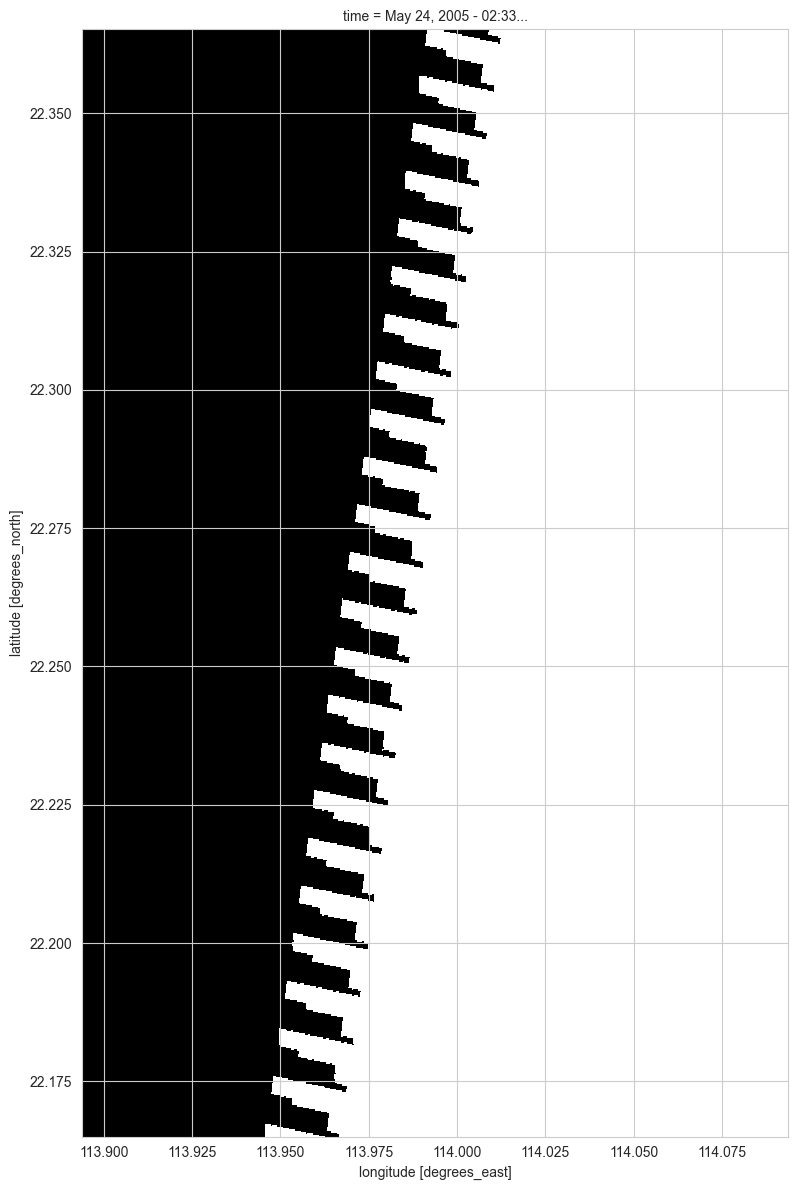

In [25]:
plot_data_landsat = data_landsat[["red","green","blue"]].to_array()

# Format the time axis with readable date strings
formatted_time = pd.to_datetime(plot_data_landsat["time"].values).strftime("%B %d, %Y - %I:%M %p")
unique_time_labels = [f"{t} ({i})" for i, t in enumerate(formatted_time)]

# Reassign the formatted time labels back to the array
plot_data_landsat.coords["time"] = ("time", unique_time_labels)

plot_data_landsat.plot.imshow(col='time', col_wrap=4, figsize = (30,12), robust=True, vmin=0, vmax=0.25)
plt.show()

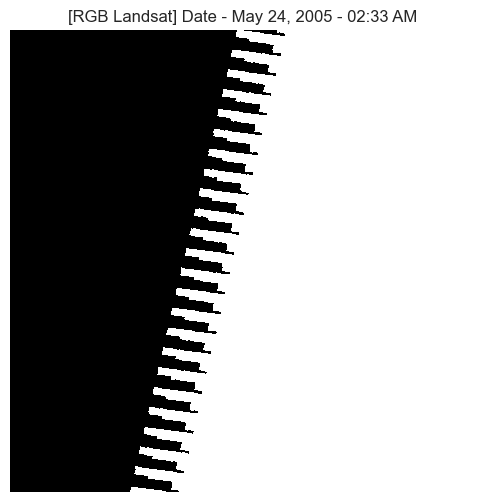

In [26]:
# Plot an image for a single date (Landsat)
time_index = 0

selected_time = pd.to_datetime(data_landsat.time.values[time_index]).strftime("%B %d, %Y - %I:%M %p")
fig, ax = plt.subplots(figsize=(6,6))
data_landsat.isel(time=time_index)[["red", "green", "blue"]].to_array().plot.imshow(robust=True, ax=ax, vmin=0.0, vmax=0.25)
ax.set_title(f"[RGB Landsat] Date - {selected_time}")
ax.axis('off')
plt.show()

In [27]:
median_landsat = data_landsat.median(dim="time").compute()

KeyboardInterrupt: 

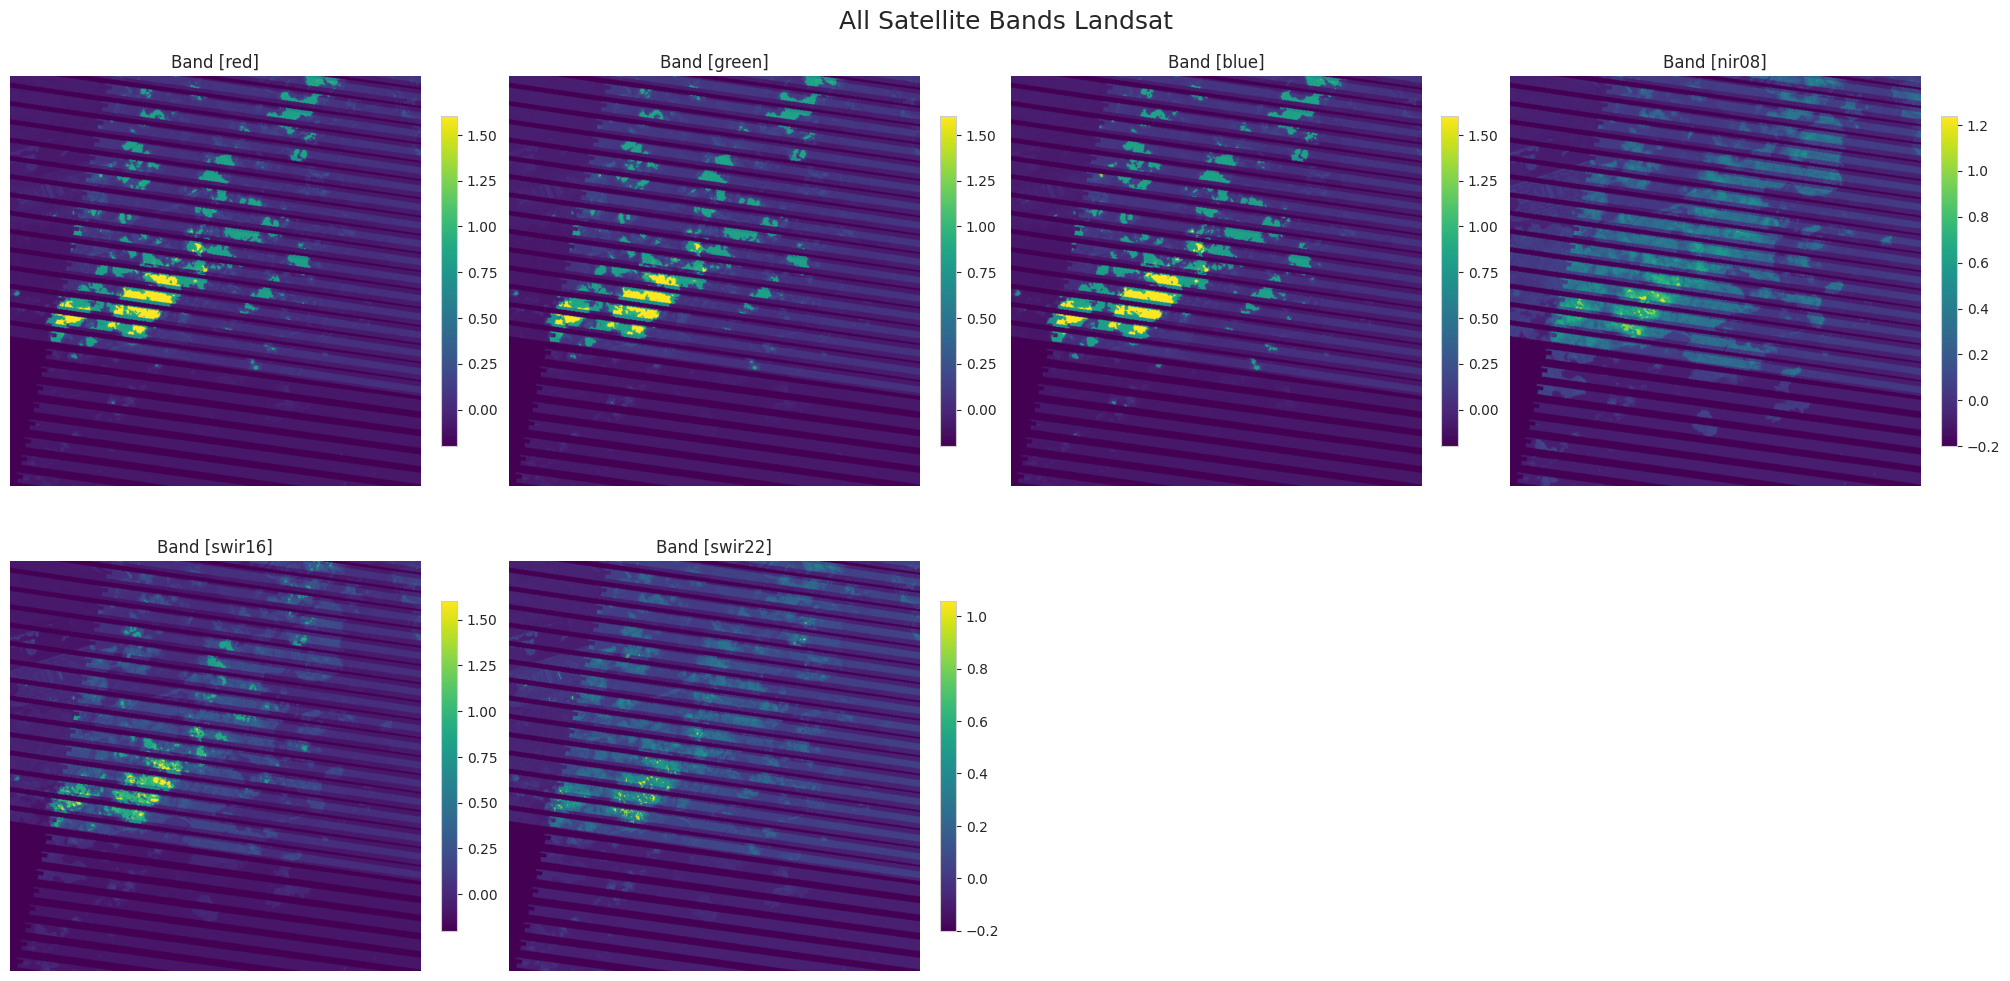

In [ ]:
import math

# Get the list of band names from the median composite
band_names = list(median_landsat.data_vars)
num_bands = len(band_names)

cols = 4
rows = math.ceil(num_bands / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 5), constrained_layout=True)
axes = axes.flatten()

# Plot each band
for i, band in enumerate(band_names):
  im = axes[i].imshow(median_landsat[band], cmap='viridis')
  axes[i].set_title(f"Band [{band}]", fontsize=12)
  axes[i].axis('off')
  fig.colorbar(im, ax=axes[i], shrink=0.7)

# Turn off any unused axes
for j in range(i + 1, len(axes)):
  axes[j].remove()

plt.suptitle("All Satellite Bands Landsat", fontsize=18)
plt.show()

In [ ]:
# Calculate derived indices from median Landsat mosaic
eps = 1e-6

# NDVI
ndvi_median_landsat = ((median_landsat.nir08 - median_landsat.red) / (median_landsat.nir08 + median_landsat.red + eps))

# NDWI
ndwi_median_landsat = ((median_landsat.green - median_landsat.nir08) / (median_landsat.green + median_landsat.nir08 + eps))

# MNDWI
mndwi_median_landsat = ((median_landsat.green - median_landsat.swir16) / (median_landsat.green + median_landsat.swir16 + eps))

# NDBI
ndbi_median_landsat = ((median_landsat.swir16 - median_landsat.nir08) / (median_landsat.swir16 + median_landsat.nir08 + eps)) 

# NDMI
ndmi_median_landsat = ((median_landsat.nir08 - median_landsat.swir16) / (median_landsat.nir08 + median_landsat.swir16 + eps))

# NDTI
ndti_median_landsat = ((median_landsat.red - median_landsat.green) / (median_landsat.red + median_landsat.green + eps))

# Store indices and plotting configs
indices = {
    "NDVI": (ndvi_median_landsat, "RdYlGn", -1, 1),
    "NDWI": (ndwi_median_landsat, "Blues", -1, 1),
    "MNDWI": (mndwi_median_landsat, "PuBu", -1, 1),
    "NDBI": (ndbi_median_landsat, "jet", -1, 1),
    "NDMI": (ndmi_median_landsat, "BrBG", -1, 1),
    "NDTI": (ndti_median_landsat, "RdBu", -1, 1),
}

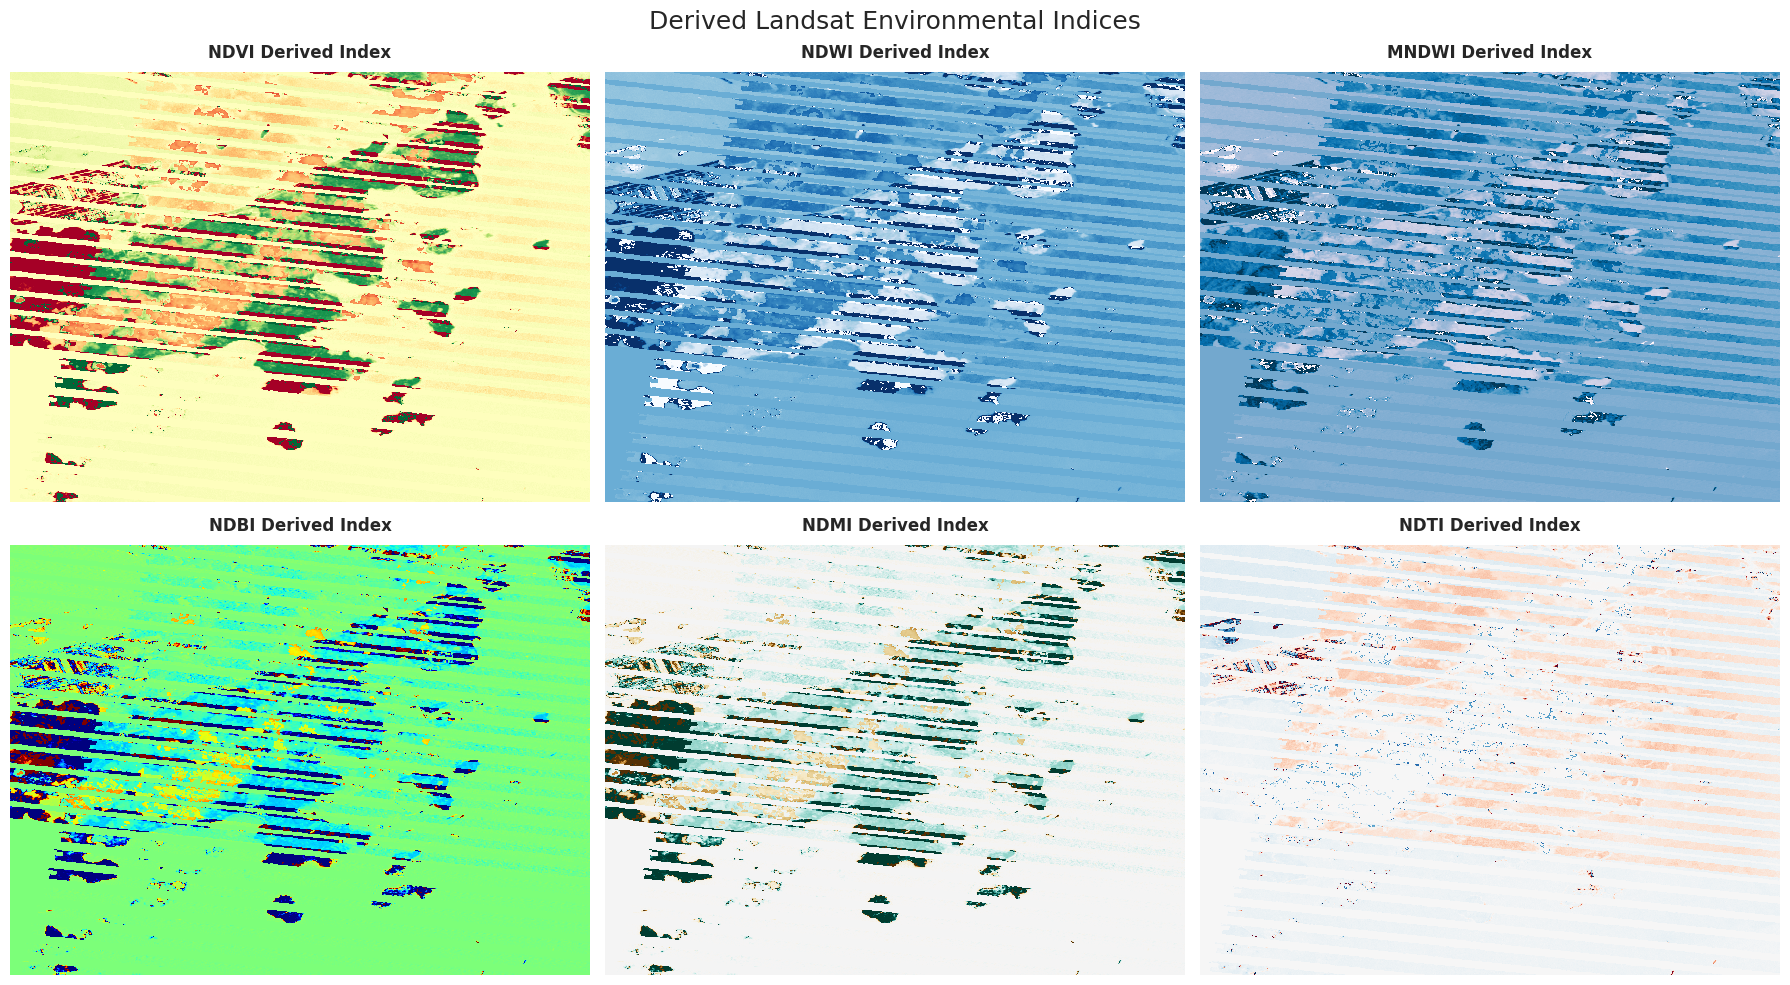

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Plot all indices
for ax, (index_name, (index_data, cmap, vmin, vmax)) in zip(axes, indices.items()):

    index_data.plot.imshow(ax=ax, cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=False)
    ax.set_title(f"{index_name} Derived Index", fontsize=12, fontweight='bold', pad=10)
    ax.axis('off')

plt.suptitle("Derived Landsat Environmental Indices", fontsize=18, y=0.98)

plt.tight_layout()
plt.show()

In [ ]:
numeric_cols = Cleaned_River_Water_Quality_df.select_dtypes(include=np.number)

skewness = Cleaned_River_Water_Quality_df[numeric_cols.columns].skew()

print(skewness.sort_values(ascending=False))

Zn_mgL       71.057864
SS_mgL       43.358610
Cu_mgL       43.333737
Mn_mgL       32.983147
TP_mgL       20.766877
DO_mgL       19.411625
Al_mgL       17.298997
Fe_mgL       14.265844
Chl_a_mgL    12.604381
swir16        6.289797
NO2_N_mgL     6.249847
swir22        5.631447
green         4.533682
red           4.376335
nir           4.320041
blue          3.981232
MNDWI         3.494194
EC            2.858441
NO3_N_mgL     2.508324
NDMI          1.649130
pH            1.306606
NDWI          1.008296
Latitude      0.589423
lat_round     0.589423
NDTI          0.161691
Year         -0.240593
Temp_C       -0.436041
lon_round    -0.589382
Longitude    -0.589382
WQI          -0.686437
NDVI         -1.506110
NDBI         -1.649130
dtype: float64


### 📊 **Correlation Analysis**

WQI          1.000000
EC           0.696538
TP_mgL       0.427217
NO2_N_mgL    0.398645
Mn_mgL       0.387413
DO_mgL       0.335426
Fe_mgL       0.331736
NDWI         0.307339
Temp_C       0.288418
Cu_mgL       0.281432
NDVI         0.240080
SS_mgL       0.195921
MNDWI        0.170129
NDMI         0.168551
NDBI         0.168551
pH           0.152285
Zn_mgL       0.107110
swir22       0.097227
blue         0.093452
red          0.092800
green        0.082503
NO3_N_mgL    0.068022
Chl_a_mgL    0.047663
swir16       0.042126
Al_mgL       0.031445
NDTI         0.030959
nir          0.011248
Name: WQI, dtype: float64


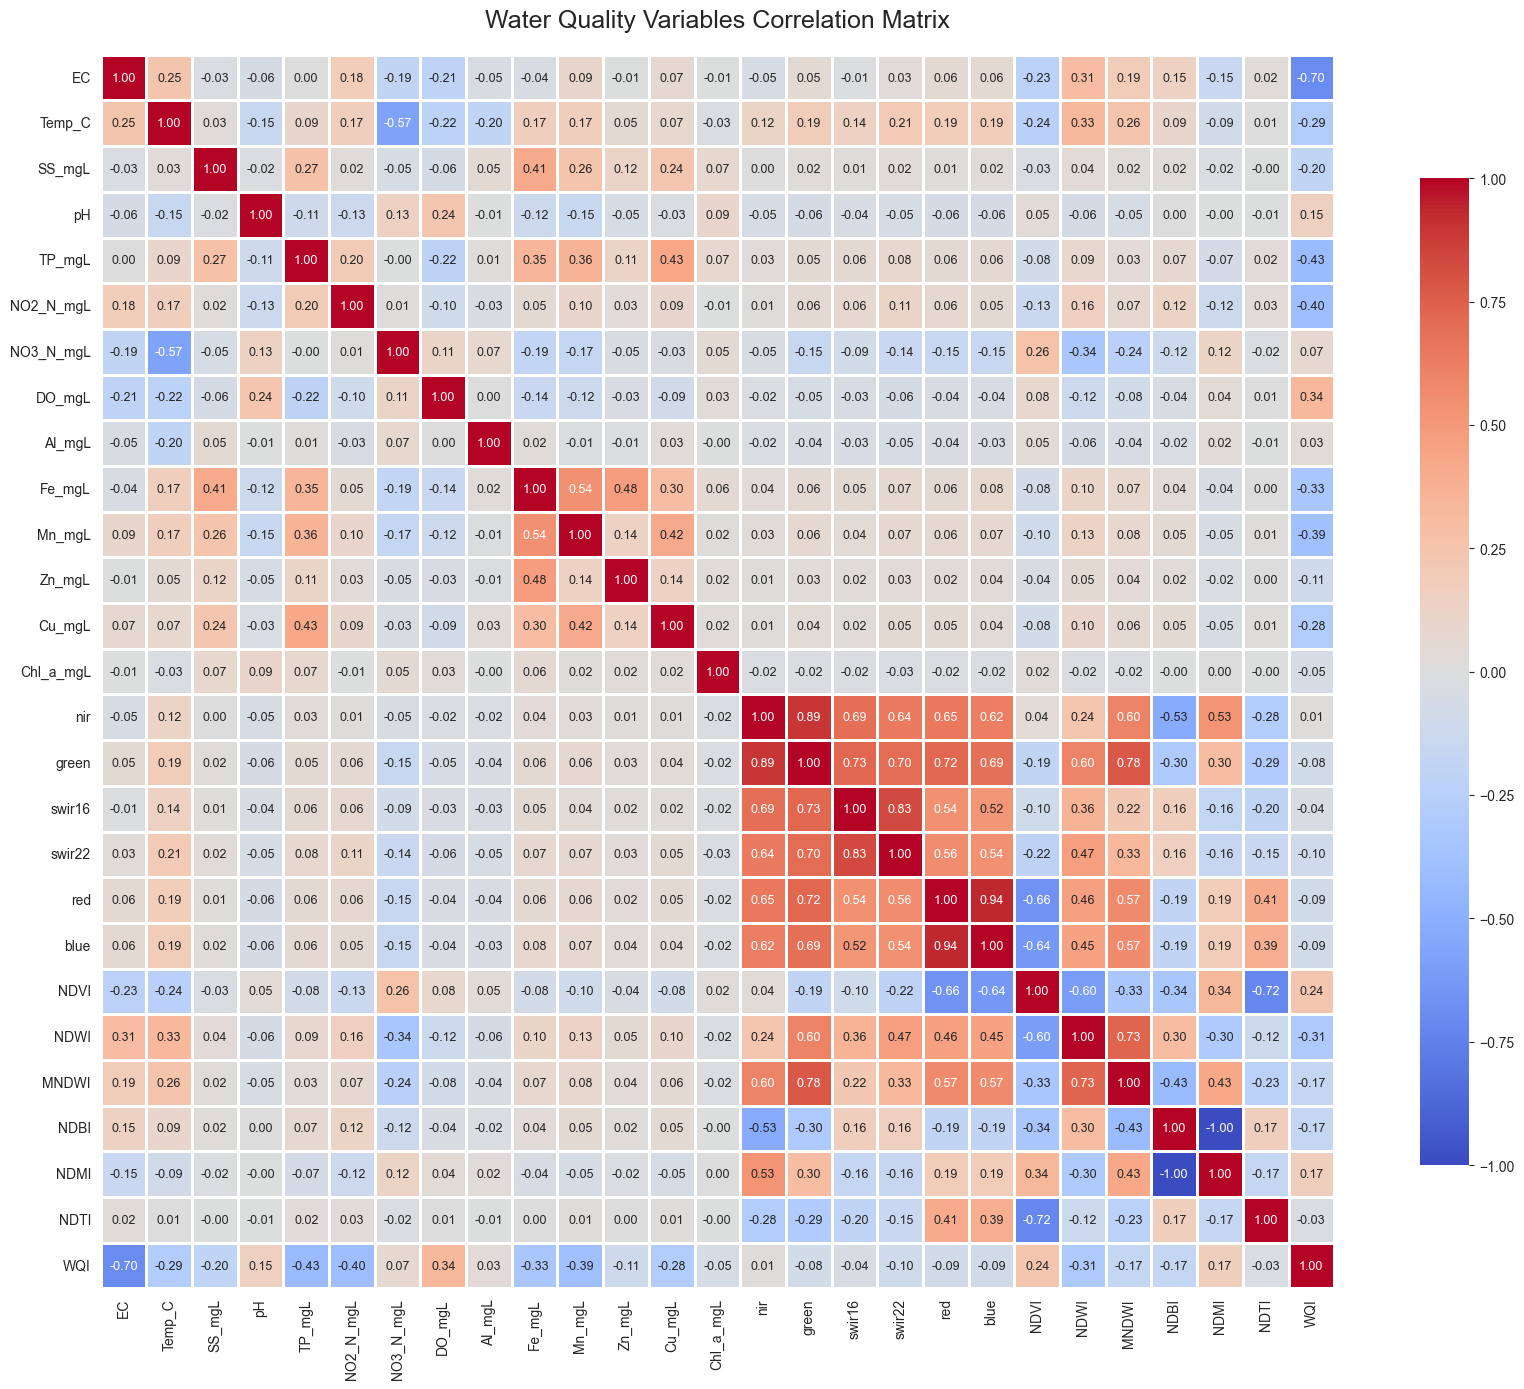

In [64]:
# Correlation Analysis Using a heatmap to identify linear relationships between features

# Select all numeric columns
numeric_cols = Cleaned_River_Water_Quality_df.select_dtypes(include=np.number).columns.tolist()

# Define selected features
selected_features = list(numeric_cols)

selected_features = [col for col in selected_features if col not in ['River', 'Year', 'Latitude', 'Longitude', 'lat_round', 'lon_round']]

# Keep only existing columns
selected_features = [col for col in selected_features if col in Cleaned_River_Water_Quality_df.columns]

# Create subset
subset_df = Cleaned_River_Water_Quality_df[selected_features]

# Compute correlation
corr_matrix = subset_df.corr()

# Extract correlation with WQI
wqi_corr = corr_matrix["WQI"].abs().sort_values(ascending=False)
print(wqi_corr)

# Plot full heatmap
plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',
            fmt=".2f", linewidths=0.8, annot_kws={"size": 9},
            square=True, cbar_kws={"shrink": 0.8}
)

plt.title('Water Quality Variables Correlation Matrix', fontsize=18, pad=20)
plt.tight_layout()
plt.show()

## ⚙️ **Model Training**

**Regression models** are designed to handle problem with numeric target variable.

Model | Description
--- | ---
**Deep Neural Network (DNN)** | A deep learning model capable of learning complex nonlinear relationships through multiple hidden layers (Benchmark from Literature)
**LightGBM** | An efficient gradient boosting framework that uses leaf-wise tree growth to achieve high predictive performance with reduced computational cost for structured data problems (Benchmark from Literature)
**XGBoost** | An optimized gradient boosting framework that offers regularization and high performance for structured data problems (Benchmark from Literature)
**Hybrid DNN-XGBoost** | A hybrid model that combines Deep Neural Network (DNN) based feature extraction with XGBoost regression to capture complex patterns and improve predictive performance

### 🧪 **Deep Neural Network (DNN)**

In [31]:
class DNNBenchmark(nn.Module):
    """
    Deep Neural Network benchmark model for regression.

    Input shape:
        (batch_size, number_of_features)

    Output shape:
        (batch_size, 1)
    """
    def __init__(self, num_features):
        super(DNNBenchmark, self).__init__()

        # Feature extraction layers
        self.feature_extractor = nn.Sequential(

            nn.Linear(num_features, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        # Regression layer
        self.regressor = nn.Linear(64, 1)

    def forward(self, x):
        features = self.feature_extractor(x)

        # Constrain output to 0-1
        # WQI is converted back to 0-100 during evaluation
        output = torch.sigmoid(self.regressor(features))

        return output

In [32]:
# Hong Kong DNN
set_seed(SEED)
generator_hongkong.manual_seed(SEED)

num_features_hongkong = X_train_hongkong_final_scaled.shape[1]

dnn_model_hongkong = DNNBenchmark(num_features=num_features_hongkong)
print(dnn_model_hongkong)

DNNBenchmark(
  (feature_extractor): Sequential(
    (0): Linear(in_features=26, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
  )
  (regressor): Linear(in_features=64, out_features=1, bias=True)
)


In [33]:
# England DNN
set_seed(SEED)
generator_england.manual_seed(SEED)

num_features_england = X_train_england_final_scaled.shape[1]

dnn_model_england = DNNBenchmark(num_features=num_features_england)
print(dnn_model_england)

DNNBenchmark(
  (feature_extractor): Sequential(
    (0): Linear(in_features=26, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
  )
  (regressor): Linear(in_features=64, out_features=1, bias=True)
)


In [34]:
# Combined DNN
set_seed(SEED)
generator_combined.manual_seed(SEED)

num_features_combined = X_train_combined_final_scaled.shape[1]

dnn_model_combined = DNNBenchmark(num_features=num_features_combined)
print(dnn_model_combined)

DNNBenchmark(
  (feature_extractor): Sequential(
    (0): Linear(in_features=26, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
  )
  (regressor): Linear(in_features=64, out_features=1, bias=True)
)


In [35]:
dnn_model_hongkong, dnn_train_losses_hongkong, dnn_valid_losses_hongkong = train_benchmark_DL_model(
    model=dnn_model_hongkong,
    model_name="DNN",
    model_type="pytorch",
    dataset_name="HongKong",
    train_loader=train_loader_hongkong,
    val_loader=val_loader_hongkong,
    device=device,
    epochs=100,
    patience=5
)


Training DNN Benchmark Model
Dataset: HongKong
Using device: cpu


Epoch [1/100] | Train Loss: 0.045594 | Val Loss: 0.009703 | Train RMSE: 21.3526 WQI | Val RMSE: 9.8504 WQI
Validation loss improved. Best model saved.


Epoch [2/100] | Train Loss: 0.006492 | Val Loss: 0.003599 | Train RMSE: 8.0574 WQI | Val RMSE: 5.9994 WQI
Validation loss improved. Best model saved.


Epoch [3/100] | Train Loss: 0.003995 | Val Loss: 0.002404 | Train RMSE: 6.3203 WQI | Val RMSE: 4.9035 WQI
Validation loss improved. Best model saved.


Epoch [4/100] | Train Loss: 0.003263 | Val Loss: 0.001679 | Train RMSE: 5.7124 WQI | Val RMSE: 4.0972 WQI
Validation loss improved. Best model saved.


Epoch [5/100] | Train Loss: 0.002647 | Val Loss: 0.001707 | Train RMSE: 5.1447 WQI | Val RMSE: 4.1316 WQI
Early Stopping Counter: 1/5


Epoch [6/100] | Train Loss: 0.002340 | Val Loss: 0.001647 | Train RMSE: 4.8374 WQI | Val RMSE: 4.0589 WQI
Validation loss improved. Best model saved.


Epoch [7/100] | Train Loss: 0.002164 | Val Loss: 0.001251 | Train RMSE: 4.6520 WQI | Val RMSE: 3.5365 WQI
Validation loss improved. Best model saved.


Epoch [8/100] | Train Loss: 0.002056 | Val Loss: 0.001286 | Train RMSE: 4.5339 WQI | Val RMSE: 3.5855 WQI
Early Stopping Counter: 1/5


Epoch [9/100] | Train Loss: 0.001924 | Val Loss: 0.001243 | Train RMSE: 4.3869 WQI | Val RMSE: 3.5251 WQI
Validation loss improved. Best model saved.


Epoch [10/100] | Train Loss: 0.001843 | Val Loss: 0.001134 | Train RMSE: 4.2933 WQI | Val RMSE: 3.3672 WQI
Validation loss improved. Best model saved.


Epoch [11/100] | Train Loss: 0.001808 | Val Loss: 0.001047 | Train RMSE: 4.2517 WQI | Val RMSE: 3.2359 WQI
Validation loss improved. Best model saved.


Epoch [12/100] | Train Loss: 0.001727 | Val Loss: 0.001425 | Train RMSE: 4.1557 WQI | Val RMSE: 3.7744 WQI
Early Stopping Counter: 1/5


Epoch [13/100] | Train Loss: 0.001708 | Val Loss: 0.001440 | Train RMSE: 4.1324 WQI | Val RMSE: 3.7946 WQI
Early Stopping Counter: 2/5


Epoch [14/100] | Train Loss: 0.001657 | Val Loss: 0.001295 | Train RMSE: 4.0711 WQI | Val RMSE: 3.5992 WQI
Early Stopping Counter: 3/5


Epoch [15/100] | Train Loss: 0.001609 | Val Loss: 0.000949 | Train RMSE: 4.0111 WQI | Val RMSE: 3.0798 WQI
Validation loss improved. Best model saved.


Epoch [16/100] | Train Loss: 0.001515 | Val Loss: 0.001757 | Train RMSE: 3.8918 WQI | Val RMSE: 4.1921 WQI
Early Stopping Counter: 1/5


Epoch [17/100] | Train Loss: 0.001571 | Val Loss: 0.000941 | Train RMSE: 3.9639 WQI | Val RMSE: 3.0676 WQI
Validation loss improved. Best model saved.


Epoch [18/100] | Train Loss: 0.001478 | Val Loss: 0.001740 | Train RMSE: 3.8443 WQI | Val RMSE: 4.1719 WQI
Early Stopping Counter: 1/5


Epoch [19/100] | Train Loss: 0.001473 | Val Loss: 0.000878 | Train RMSE: 3.8375 WQI | Val RMSE: 2.9629 WQI
Validation loss improved. Best model saved.


Epoch [20/100] | Train Loss: 0.001415 | Val Loss: 0.000855 | Train RMSE: 3.7613 WQI | Val RMSE: 2.9242 WQI
Validation loss improved. Best model saved.


Epoch [21/100] | Train Loss: 0.001439 | Val Loss: 0.000927 | Train RMSE: 3.7932 WQI | Val RMSE: 3.0450 WQI
Early Stopping Counter: 1/5


Epoch [22/100] | Train Loss: 0.001404 | Val Loss: 0.000818 | Train RMSE: 3.7466 WQI | Val RMSE: 2.8596 WQI
Validation loss improved. Best model saved.


Epoch [23/100] | Train Loss: 0.001378 | Val Loss: 0.000833 | Train RMSE: 3.7118 WQI | Val RMSE: 2.8860 WQI
Early Stopping Counter: 1/5


Epoch [24/100] | Train Loss: 0.001371 | Val Loss: 0.001428 | Train RMSE: 3.7029 WQI | Val RMSE: 3.7786 WQI
Early Stopping Counter: 2/5


Epoch [25/100] | Train Loss: 0.001328 | Val Loss: 0.000847 | Train RMSE: 3.6435 WQI | Val RMSE: 2.9103 WQI
Early Stopping Counter: 3/5


Epoch [26/100] | Train Loss: 0.001318 | Val Loss: 0.000806 | Train RMSE: 3.6308 WQI | Val RMSE: 2.8383 WQI
Validation loss improved. Best model saved.


Epoch [27/100] | Train Loss: 0.001320 | Val Loss: 0.000849 | Train RMSE: 3.6326 WQI | Val RMSE: 2.9143 WQI
Early Stopping Counter: 1/5


Epoch [28/100] | Train Loss: 0.001269 | Val Loss: 0.000806 | Train RMSE: 3.5628 WQI | Val RMSE: 2.8394 WQI
Early Stopping Counter: 2/5


Epoch [29/100] | Train Loss: 0.001273 | Val Loss: 0.000759 | Train RMSE: 3.5678 WQI | Val RMSE: 2.7550 WQI
Validation loss improved. Best model saved.


Epoch [30/100] | Train Loss: 0.001250 | Val Loss: 0.000781 | Train RMSE: 3.5357 WQI | Val RMSE: 2.7953 WQI
Early Stopping Counter: 1/5


Epoch [31/100] | Train Loss: 0.001235 | Val Loss: 0.001361 | Train RMSE: 3.5139 WQI | Val RMSE: 3.6886 WQI
Early Stopping Counter: 2/5


Epoch [32/100] | Train Loss: 0.001245 | Val Loss: 0.000741 | Train RMSE: 3.5281 WQI | Val RMSE: 2.7222 WQI
Validation loss improved. Best model saved.


Epoch [33/100] | Train Loss: 0.001216 | Val Loss: 0.000713 | Train RMSE: 3.4870 WQI | Val RMSE: 2.6711 WQI
Validation loss improved. Best model saved.


Epoch [34/100] | Train Loss: 0.001202 | Val Loss: 0.001188 | Train RMSE: 3.4673 WQI | Val RMSE: 3.4471 WQI
Early Stopping Counter: 1/5


Epoch [35/100] | Train Loss: 0.001238 | Val Loss: 0.000741 | Train RMSE: 3.5186 WQI | Val RMSE: 2.7218 WQI
Early Stopping Counter: 2/5


Epoch [36/100] | Train Loss: 0.001195 | Val Loss: 0.001736 | Train RMSE: 3.4562 WQI | Val RMSE: 4.1662 WQI
Early Stopping Counter: 3/5


Epoch [37/100] | Train Loss: 0.001169 | Val Loss: 0.000731 | Train RMSE: 3.4194 WQI | Val RMSE: 2.7032 WQI
Early Stopping Counter: 4/5


Epoch [38/100] | Train Loss: 0.001150 | Val Loss: 0.000719 | Train RMSE: 3.3916 WQI | Val RMSE: 2.6821 WQI
Early Stopping Counter: 5/5
Early stopping triggered.

DNN Training Complete
Best Validation Loss: 0.000713
Best Validation RMSE: 2.6711 WQI
Model saved to: /Users/nqb/Documents/water-quality-prediction-contamination-assessment/model/dnn_benchmark_hongkong.pth


In [36]:
dnn_model_england, dnn_train_losses_england, dnn_valid_losses_england = train_benchmark_DL_model(
    model=dnn_model_england,
    model_name="DNN",
    model_type="pytorch",
    dataset_name="England",
    train_loader=train_loader_england,
    val_loader=val_loader_england,
    device=device,
    epochs=100,
    patience=5
)


Training DNN Benchmark Model
Dataset: England
Using device: cpu


Epoch [1/100] | Train Loss: 0.107155 | Val Loss: 0.054318 | Train RMSE: 32.7346 WQI | Val RMSE: 23.3061 WQI
Validation loss improved. Best model saved.


Epoch [2/100] | Train Loss: 0.027208 | Val Loss: 0.017622 | Train RMSE: 16.4949 WQI | Val RMSE: 13.2748 WQI
Validation loss improved. Best model saved.


Epoch [3/100] | Train Loss: 0.009140 | Val Loss: 0.005853 | Train RMSE: 9.5605 WQI | Val RMSE: 7.6505 WQI
Validation loss improved. Best model saved.


Epoch [4/100] | Train Loss: 0.004962 | Val Loss: 0.003400 | Train RMSE: 7.0444 WQI | Val RMSE: 5.8312 WQI
Validation loss improved. Best model saved.


Epoch [5/100] | Train Loss: 0.003571 | Val Loss: 0.002799 | Train RMSE: 5.9757 WQI | Val RMSE: 5.2907 WQI
Validation loss improved. Best model saved.


Epoch [6/100] | Train Loss: 0.002891 | Val Loss: 0.001873 | Train RMSE: 5.3764 WQI | Val RMSE: 4.3282 WQI
Validation loss improved. Best model saved.


Epoch [7/100] | Train Loss: 0.002509 | Val Loss: 0.001757 | Train RMSE: 5.0089 WQI | Val RMSE: 4.1919 WQI
Validation loss improved. Best model saved.


Epoch [8/100] | Train Loss: 0.002283 | Val Loss: 0.001489 | Train RMSE: 4.7776 WQI | Val RMSE: 3.8591 WQI
Validation loss improved. Best model saved.


Epoch [9/100] | Train Loss: 0.002220 | Val Loss: 0.001439 | Train RMSE: 4.7114 WQI | Val RMSE: 3.7929 WQI
Validation loss improved. Best model saved.


Epoch [10/100] | Train Loss: 0.002026 | Val Loss: 0.001332 | Train RMSE: 4.5009 WQI | Val RMSE: 3.6496 WQI
Validation loss improved. Best model saved.


Epoch [11/100] | Train Loss: 0.001904 | Val Loss: 0.001277 | Train RMSE: 4.3638 WQI | Val RMSE: 3.5740 WQI
Validation loss improved. Best model saved.


Epoch [12/100] | Train Loss: 0.001868 | Val Loss: 0.001185 | Train RMSE: 4.3217 WQI | Val RMSE: 3.4429 WQI
Validation loss improved. Best model saved.


Epoch [13/100] | Train Loss: 0.001803 | Val Loss: 0.001099 | Train RMSE: 4.2467 WQI | Val RMSE: 3.3146 WQI
Validation loss improved. Best model saved.


Epoch [14/100] | Train Loss: 0.001752 | Val Loss: 0.001026 | Train RMSE: 4.1856 WQI | Val RMSE: 3.2034 WQI
Validation loss improved. Best model saved.


Epoch [15/100] | Train Loss: 0.001672 | Val Loss: 0.001050 | Train RMSE: 4.0890 WQI | Val RMSE: 3.2402 WQI
Early Stopping Counter: 1/5


Epoch [16/100] | Train Loss: 0.001628 | Val Loss: 0.001021 | Train RMSE: 4.0351 WQI | Val RMSE: 3.1959 WQI
Validation loss improved. Best model saved.


Epoch [17/100] | Train Loss: 0.001638 | Val Loss: 0.001062 | Train RMSE: 4.0477 WQI | Val RMSE: 3.2583 WQI
Early Stopping Counter: 1/5


Epoch [18/100] | Train Loss: 0.001574 | Val Loss: 0.000938 | Train RMSE: 3.9668 WQI | Val RMSE: 3.0626 WQI
Validation loss improved. Best model saved.


Epoch [19/100] | Train Loss: 0.001534 | Val Loss: 0.000965 | Train RMSE: 3.9163 WQI | Val RMSE: 3.1067 WQI
Early Stopping Counter: 1/5


Epoch [20/100] | Train Loss: 0.001540 | Val Loss: 0.000904 | Train RMSE: 3.9246 WQI | Val RMSE: 3.0061 WQI
Validation loss improved. Best model saved.


Epoch [21/100] | Train Loss: 0.001464 | Val Loss: 0.000898 | Train RMSE: 3.8268 WQI | Val RMSE: 2.9965 WQI
Validation loss improved. Best model saved.


Epoch [22/100] | Train Loss: 0.001494 | Val Loss: 0.000884 | Train RMSE: 3.8649 WQI | Val RMSE: 2.9739 WQI
Validation loss improved. Best model saved.


Epoch [23/100] | Train Loss: 0.001460 | Val Loss: 0.000868 | Train RMSE: 3.8214 WQI | Val RMSE: 2.9463 WQI
Validation loss improved. Best model saved.


Epoch [24/100] | Train Loss: 0.001406 | Val Loss: 0.000858 | Train RMSE: 3.7492 WQI | Val RMSE: 2.9291 WQI
Validation loss improved. Best model saved.


Epoch [25/100] | Train Loss: 0.001423 | Val Loss: 0.000883 | Train RMSE: 3.7720 WQI | Val RMSE: 2.9712 WQI
Early Stopping Counter: 1/5


Epoch [26/100] | Train Loss: 0.001405 | Val Loss: 0.000925 | Train RMSE: 3.7479 WQI | Val RMSE: 3.0417 WQI
Early Stopping Counter: 2/5


Epoch [27/100] | Train Loss: 0.001367 | Val Loss: 0.000822 | Train RMSE: 3.6967 WQI | Val RMSE: 2.8665 WQI
Validation loss improved. Best model saved.


Epoch [28/100] | Train Loss: 0.001381 | Val Loss: 0.000794 | Train RMSE: 3.7164 WQI | Val RMSE: 2.8171 WQI
Validation loss improved. Best model saved.


Epoch [29/100] | Train Loss: 0.001374 | Val Loss: 0.000820 | Train RMSE: 3.7064 WQI | Val RMSE: 2.8638 WQI
Early Stopping Counter: 1/5


Epoch [30/100] | Train Loss: 0.001328 | Val Loss: 0.000825 | Train RMSE: 3.6448 WQI | Val RMSE: 2.8731 WQI
Early Stopping Counter: 2/5


Epoch [31/100] | Train Loss: 0.001328 | Val Loss: 0.000777 | Train RMSE: 3.6436 WQI | Val RMSE: 2.7869 WQI
Validation loss improved. Best model saved.


Epoch [32/100] | Train Loss: 0.001285 | Val Loss: 0.000818 | Train RMSE: 3.5853 WQI | Val RMSE: 2.8596 WQI
Early Stopping Counter: 1/5


Epoch [33/100] | Train Loss: 0.001328 | Val Loss: 0.000803 | Train RMSE: 3.6447 WQI | Val RMSE: 2.8343 WQI
Early Stopping Counter: 2/5


Epoch [34/100] | Train Loss: 0.001274 | Val Loss: 0.000793 | Train RMSE: 3.5690 WQI | Val RMSE: 2.8152 WQI
Early Stopping Counter: 3/5


Epoch [35/100] | Train Loss: 0.001273 | Val Loss: 0.000775 | Train RMSE: 3.5678 WQI | Val RMSE: 2.7836 WQI
Validation loss improved. Best model saved.


Epoch [36/100] | Train Loss: 0.001273 | Val Loss: 0.000759 | Train RMSE: 3.5681 WQI | Val RMSE: 2.7549 WQI
Validation loss improved. Best model saved.


Epoch [37/100] | Train Loss: 0.001265 | Val Loss: 0.000759 | Train RMSE: 3.5561 WQI | Val RMSE: 2.7549 WQI
Early Stopping Counter: 1/5


Epoch [38/100] | Train Loss: 0.001238 | Val Loss: 0.000814 | Train RMSE: 3.5187 WQI | Val RMSE: 2.8528 WQI
Early Stopping Counter: 2/5


Epoch [39/100] | Train Loss: 0.001236 | Val Loss: 0.000761 | Train RMSE: 3.5158 WQI | Val RMSE: 2.7591 WQI
Early Stopping Counter: 3/5


Epoch [40/100] | Train Loss: 0.001213 | Val Loss: 0.000736 | Train RMSE: 3.4831 WQI | Val RMSE: 2.7127 WQI
Validation loss improved. Best model saved.


Epoch [41/100] | Train Loss: 0.001242 | Val Loss: 0.000750 | Train RMSE: 3.5247 WQI | Val RMSE: 2.7378 WQI
Early Stopping Counter: 1/5


Epoch [42/100] | Train Loss: 0.001243 | Val Loss: 0.000816 | Train RMSE: 3.5262 WQI | Val RMSE: 2.8564 WQI
Early Stopping Counter: 2/5


Epoch [43/100] | Train Loss: 0.001220 | Val Loss: 0.000778 | Train RMSE: 3.4935 WQI | Val RMSE: 2.7890 WQI
Early Stopping Counter: 3/5


Epoch [44/100] | Train Loss: 0.001184 | Val Loss: 0.000771 | Train RMSE: 3.4414 WQI | Val RMSE: 2.7758 WQI
Early Stopping Counter: 4/5


Epoch [45/100] | Train Loss: 0.001175 | Val Loss: 0.000741 | Train RMSE: 3.4280 WQI | Val RMSE: 2.7216 WQI
Early Stopping Counter: 5/5
Early stopping triggered.

DNN Training Complete
Best Validation Loss: 0.000736
Best Validation RMSE: 2.7127 WQI
Model saved to: /Users/nqb/Documents/water-quality-prediction-contamination-assessment/model/dnn_benchmark_england.pth


In [37]:
dnn_model_combined, dnn_train_losses_combined, dnn_valid_losses_combined = train_benchmark_DL_model(
    model=dnn_model_combined,
    model_name="DNN",
    model_type="pytorch",
    dataset_name="Combined",
    train_loader=train_loader_combined,
    val_loader=val_loader_combined,
    device=device,
    epochs=100,
    patience=5
)


Training DNN Benchmark Model
Dataset: Combined
Using device: cpu


Epoch [1/100] | Train Loss: 0.039125 | Val Loss: 0.005618 | Train RMSE: 19.7801 WQI | Val RMSE: 7.4955 WQI
Validation loss improved. Best model saved.


Epoch [2/100] | Train Loss: 0.004611 | Val Loss: 0.002345 | Train RMSE: 6.7906 WQI | Val RMSE: 4.8426 WQI
Validation loss improved. Best model saved.


Epoch [3/100] | Train Loss: 0.003150 | Val Loss: 0.001696 | Train RMSE: 5.6127 WQI | Val RMSE: 4.1184 WQI
Validation loss improved. Best model saved.


Epoch [4/100] | Train Loss: 0.002602 | Val Loss: 0.001597 | Train RMSE: 5.1007 WQI | Val RMSE: 3.9963 WQI
Validation loss improved. Best model saved.


Epoch [5/100] | Train Loss: 0.002250 | Val Loss: 0.001334 | Train RMSE: 4.7436 WQI | Val RMSE: 3.6518 WQI
Validation loss improved. Best model saved.


Epoch [6/100] | Train Loss: 0.002126 | Val Loss: 0.001193 | Train RMSE: 4.6104 WQI | Val RMSE: 3.4536 WQI
Validation loss improved. Best model saved.


Epoch [7/100] | Train Loss: 0.001921 | Val Loss: 0.001149 | Train RMSE: 4.3833 WQI | Val RMSE: 3.3898 WQI
Validation loss improved. Best model saved.


Epoch [8/100] | Train Loss: 0.001818 | Val Loss: 0.001174 | Train RMSE: 4.2633 WQI | Val RMSE: 3.4261 WQI
Early Stopping Counter: 1/5


Epoch [9/100] | Train Loss: 0.001786 | Val Loss: 0.001038 | Train RMSE: 4.2257 WQI | Val RMSE: 3.2220 WQI
Validation loss improved. Best model saved.


Epoch [10/100] | Train Loss: 0.001672 | Val Loss: 0.001005 | Train RMSE: 4.0890 WQI | Val RMSE: 3.1696 WQI
Validation loss improved. Best model saved.


Epoch [11/100] | Train Loss: 0.001662 | Val Loss: 0.000982 | Train RMSE: 4.0767 WQI | Val RMSE: 3.1342 WQI
Validation loss improved. Best model saved.


Epoch [12/100] | Train Loss: 0.001606 | Val Loss: 0.000948 | Train RMSE: 4.0072 WQI | Val RMSE: 3.0790 WQI
Validation loss improved. Best model saved.


Epoch [13/100] | Train Loss: 0.001583 | Val Loss: 0.000988 | Train RMSE: 3.9786 WQI | Val RMSE: 3.1436 WQI
Early Stopping Counter: 1/5


Epoch [14/100] | Train Loss: 0.001519 | Val Loss: 0.000956 | Train RMSE: 3.8976 WQI | Val RMSE: 3.0920 WQI
Early Stopping Counter: 2/5


Epoch [15/100] | Train Loss: 0.001475 | Val Loss: 0.001657 | Train RMSE: 3.8402 WQI | Val RMSE: 4.0709 WQI
Early Stopping Counter: 3/5


Epoch [16/100] | Train Loss: 0.001467 | Val Loss: 0.002031 | Train RMSE: 3.8302 WQI | Val RMSE: 4.5072 WQI
Early Stopping Counter: 4/5


Epoch [17/100] | Train Loss: 0.001407 | Val Loss: 0.000821 | Train RMSE: 3.7511 WQI | Val RMSE: 2.8660 WQI
Validation loss improved. Best model saved.


Epoch [18/100] | Train Loss: 0.001386 | Val Loss: 0.001023 | Train RMSE: 3.7236 WQI | Val RMSE: 3.1990 WQI
Early Stopping Counter: 1/5


Epoch [19/100] | Train Loss: 0.001362 | Val Loss: 0.000816 | Train RMSE: 3.6899 WQI | Val RMSE: 2.8571 WQI
Validation loss improved. Best model saved.


Epoch [20/100] | Train Loss: 0.001366 | Val Loss: 0.000768 | Train RMSE: 3.6959 WQI | Val RMSE: 2.7714 WQI
Validation loss improved. Best model saved.


Epoch [21/100] | Train Loss: 0.001317 | Val Loss: 0.000777 | Train RMSE: 3.6289 WQI | Val RMSE: 2.7869 WQI
Early Stopping Counter: 1/5


Epoch [22/100] | Train Loss: 0.001316 | Val Loss: 0.000752 | Train RMSE: 3.6276 WQI | Val RMSE: 2.7431 WQI
Validation loss improved. Best model saved.


Epoch [23/100] | Train Loss: 0.001254 | Val Loss: 0.000878 | Train RMSE: 3.5406 WQI | Val RMSE: 2.9635 WQI
Early Stopping Counter: 1/5


Epoch [24/100] | Train Loss: 0.001256 | Val Loss: 0.003488 | Train RMSE: 3.5443 WQI | Val RMSE: 5.9061 WQI
Early Stopping Counter: 2/5


Epoch [25/100] | Train Loss: 0.001248 | Val Loss: 0.000775 | Train RMSE: 3.5320 WQI | Val RMSE: 2.7842 WQI
Early Stopping Counter: 3/5


Epoch [26/100] | Train Loss: 0.001259 | Val Loss: 0.000773 | Train RMSE: 3.5484 WQI | Val RMSE: 2.7794 WQI
Early Stopping Counter: 4/5


Epoch [27/100] | Train Loss: 0.001250 | Val Loss: 0.000767 | Train RMSE: 3.5355 WQI | Val RMSE: 2.7691 WQI
Early Stopping Counter: 5/5
Early stopping triggered.

DNN Training Complete
Best Validation Loss: 0.000752
Best Validation RMSE: 2.7431 WQI
Model saved to: /Users/nqb/Documents/water-quality-prediction-contamination-assessment/model/dnn_benchmark_combined.pth


### ✅ **DNN Model Evaluation and Visual Analysis**
We evaluate the DNN's model performance using standard regression metrics (R2, RMSE, and MAE).

Furthermore, we generate visual plots (Actual vs. Predicted curve and Residual Distribution) to clearly interpret the results.

In [38]:
# DNN: Hong Kong-Trained -> Hong Kong
y_test_dnn_hongkong, y_pred_dnn_hongkong, rmse_dnn_hongkong, mae_dnn_hongkong, r2_dnn_hongkong = evaluate_dnn_model(
    model=dnn_model_hongkong,
    test_loader=test_loader_hongkong,
    device=device,
    dataset_name="Hong Kong"
)

DNN Evaluation Results for Hong Kong:
RMSE: 2.6738
MAE: 2.0419
R2 Score: 0.9774
Number of predictions: 4545


In [39]:
# DNN: England-Trained -> England
y_test_dnn_england, y_pred_dnn_england, rmse_dnn_england, mae_dnn_england, r2_dnn_england = evaluate_dnn_model(
    model=dnn_model_england,
    test_loader=test_loader_england,
    device=device,
    dataset_name="England"
)

DNN Evaluation Results for England:
RMSE: 2.7578
MAE: 2.1782
R2 Score: 0.8511
Number of predictions: 2542


In [40]:
# DNN: Hong Kong-Trained -> England Dataset
dnn_model_hongkong.eval()

dnn_predictions_hongkong_to_england = []
dnn_actual_values_hongkong_to_england = []

with torch.no_grad():
    for batch_X_hongkong_to_england, batch_y_hongkong_to_england in test_loader_hongkong_to_england:

        batch_X_hongkong_to_england = batch_X_hongkong_to_england.to(device, dtype=torch.float32)

        # Hong Kong-trained DNN
        outputs = dnn_model_hongkong(batch_X_hongkong_to_england)

        # Convert prediction from 0-1 -> 0-100 WQI
        dnn_predictions_hongkong_to_england.extend(outputs.cpu().numpy().reshape(-1) * 100.0)

        # Convert actual target from 0-1 -> 0-100 WQI
        dnn_actual_values_hongkong_to_england.extend(batch_y_hongkong_to_england.cpu().numpy().reshape(-1) * 100.0)

# Convert to NumPy arrays
y_pred_dnn_hongkong_to_england = np.asarray(dnn_predictions_hongkong_to_england)
y_test_dnn_hongkong_to_england = np.asarray(dnn_actual_values_hongkong_to_england)

print("Number of predictions:", len(y_pred_dnn_hongkong_to_england))

Number of predictions: 2542


In [41]:
# DNN: Hong Kong-Trained -> England
rmse_dnn_hongkong_to_england = np.sqrt(mean_squared_error(y_test_dnn_hongkong_to_england, y_pred_dnn_hongkong_to_england))
mae_dnn_hongkong_to_england = mean_absolute_error(y_test_dnn_hongkong_to_england, y_pred_dnn_hongkong_to_england)
r2_dnn_hongkong_to_england = r2_score(y_test_dnn_hongkong_to_england, y_pred_dnn_hongkong_to_england)

print("Deep Neural Network (DNN) Evaluation Results for Hong Kong-Trained on England Dataset:")
print(f"RMSE: {rmse_dnn_hongkong_to_england:.4f}")
print(f"MAE:  {mae_dnn_hongkong_to_england:.4f}")
print(f"R2 Score: {r2_dnn_hongkong_to_england:.4f}")

Deep Neural Network (DNN) Evaluation Results for Hong Kong-Trained on England Dataset:
RMSE: 4.6116
MAE:  3.8298
R2 Score: 0.5838


In [42]:
# DNN: England-Trained -> Hong Kong Dataset
dnn_model_england.eval()

dnn_predictions_england_to_hongkong = []
dnn_actual_values_england_to_hongkong = []

with torch.no_grad():
    for batch_X_england_to_hongkong, batch_y_england_to_hongkong in test_loader_england_to_hongkong:

        batch_X = batch_X_england_to_hongkong.to(device, dtype=torch.float32)

        # England-trained DNN
        outputs = dnn_model_england(batch_X)

        # Convert prediction from 0-1 -> 0-100 WQI
        dnn_predictions_england_to_hongkong.extend(outputs.cpu().numpy().reshape(-1) * 100.0)

        # Convert actual target from 0-1 -> 0-100 WQI
        dnn_actual_values_england_to_hongkong.extend(batch_y_england_to_hongkong.cpu().numpy().reshape(-1) * 100.0)

# Convert to NumPy arrays
y_pred_dnn_england_to_hongkong = np.asarray(dnn_predictions_england_to_hongkong)
y_test_dnn_england_to_hongkong = np.asarray(dnn_actual_values_england_to_hongkong)

print("Number of predictions:", len(y_pred_dnn_england_to_hongkong))

Number of predictions: 4545


In [43]:
# DNN: England-Trained -> Hong Kong
rmse_dnn_england_to_hongkong = np.sqrt(mean_squared_error(y_test_dnn_england_to_hongkong, y_pred_dnn_england_to_hongkong))
mae_dnn_england_to_hongkong = mean_absolute_error(y_test_dnn_england_to_hongkong, y_pred_dnn_england_to_hongkong)
r2_dnn_england_to_hongkong = r2_score(y_test_dnn_england_to_hongkong, y_pred_dnn_england_to_hongkong)

print("Deep Neural Network (DNN) Evaluation Results for England-Trained on Hong Kong Dataset:")
print(f"RMSE: {rmse_dnn_england_to_hongkong:.4f}")
print(f"MAE:  {mae_dnn_england_to_hongkong:.4f}")
print(f"R2 Score: {r2_dnn_england_to_hongkong:.4f}")

Deep Neural Network (DNN) Evaluation Results for England-Trained on Hong Kong Dataset:
RMSE: 24.0556
MAE:  16.5605
R2 Score: -0.8302


In [44]:
# DNN: Combined-Trained -> Hong Kong Dataset
dnn_model_combined.eval()

dnn_predictions_combined_to_hongkong = []
dnn_actual_values_combined_to_hongkong = []

with torch.no_grad():
    for batch_X_combined_to_hongkong, batch_y_combined_to_hongkong in test_loader_combined_to_hongkong:

        batch_X = batch_X_combined_to_hongkong.to(device, dtype=torch.float32)

        # Combined-trained DNN
        outputs = dnn_model_combined(batch_X)

        # Convert prediction from 0-1 -> 0-100 WQI
        dnn_predictions_combined_to_hongkong.extend(outputs.cpu().numpy().reshape(-1) * 100.0)

        # Convert actual target from 0-1 -> 0-100 WQI
        dnn_actual_values_combined_to_hongkong.extend(batch_y_combined_to_hongkong.cpu().numpy().reshape(-1) * 100.0)

# Convert to NumPy arrays
y_pred_dnn_combined_to_hongkong = np.asarray(dnn_predictions_combined_to_hongkong)
y_test_dnn_combined_to_hongkong = np.asarray(dnn_actual_values_combined_to_hongkong)

print("Combined-trained -> Hong Kong predictions:", len(y_pred_dnn_combined_to_hongkong))

Combined-trained -> Hong Kong predictions: 4545


In [45]:
# DNN: Combined-Trained -> Hong Kong
rmse_dnn_combined_to_hongkong = np.sqrt(mean_squared_error(y_test_dnn_combined_to_hongkong, y_pred_dnn_combined_to_hongkong))
mae_dnn_combined_to_hongkong = mean_absolute_error(y_test_dnn_combined_to_hongkong, y_pred_dnn_combined_to_hongkong)
r2_dnn_combined_to_hongkong = r2_score(y_test_dnn_combined_to_hongkong, y_pred_dnn_combined_to_hongkong)

print("Deep Neural Network (DNN) Evaluation Results for Combined-Trained on Hong Kong Dataset:")
print(f"RMSE: {rmse_dnn_combined_to_hongkong:.4f}")
print(f"MAE:  {mae_dnn_combined_to_hongkong:.4f}")
print(f"R2 Score: {r2_dnn_combined_to_hongkong:.4f}")

Deep Neural Network (DNN) Evaluation Results for Combined-Trained on Hong Kong Dataset:
RMSE: 2.6704
MAE:  2.0231
R2 Score: 0.9774


In [46]:
# DNN: Combined-Trained -> England Dataset
dnn_model_combined.eval()

dnn_predictions_combined_to_england = []
dnn_actual_values_combined_to_england = []

with torch.no_grad():
    for batch_X_combined_to_england, batch_y_combined_to_england in test_loader_combined_to_england:

        batch_X = batch_X_combined_to_england.to(device, dtype=torch.float32)

        # Combined-trained DNN
        outputs = dnn_model_combined(batch_X)

        # Convert prediction from 0-1 -> 0-100 WQI
        dnn_predictions_combined_to_england.extend(outputs.cpu().numpy().reshape(-1) * 100.0)

        # Convert actual target from 0-1 -> 0-100 WQI
        dnn_actual_values_combined_to_england.extend(batch_y_combined_to_england.cpu().numpy().reshape(-1) * 100.0)

# Convert to NumPy arrays
y_pred_dnn_combined_to_england = np.asarray(dnn_predictions_combined_to_england)
y_test_dnn_combined_to_england = np.asarray(dnn_actual_values_combined_to_england)

print("Combined-trained -> England predictions:",len(y_pred_dnn_combined_to_england))

Combined-trained -> England predictions: 2542


In [47]:
# DNN: Combined-Trained -> England
rmse_dnn_combined_to_england = np.sqrt(mean_squared_error(y_test_dnn_combined_to_england, y_pred_dnn_combined_to_england))
mae_dnn_combined_to_england = mean_absolute_error(y_test_dnn_combined_to_england, y_pred_dnn_combined_to_england)
r2_dnn_combined_to_england = r2_score(y_test_dnn_combined_to_england, y_pred_dnn_combined_to_england)

print("Deep Neural Network (DNN) Evaluation Results for Combined-Trained on England Dataset:")
print(f"RMSE: {rmse_dnn_combined_to_england:.4f}")
print(f"MAE:  {mae_dnn_combined_to_england:.4f}")
print(f"R2 Score: {r2_dnn_combined_to_england:.4f}")

Deep Neural Network (DNN) Evaluation Results for Combined-Trained on England Dataset:
RMSE: 2.8814
MAE:  2.4443
R2 Score: 0.8375


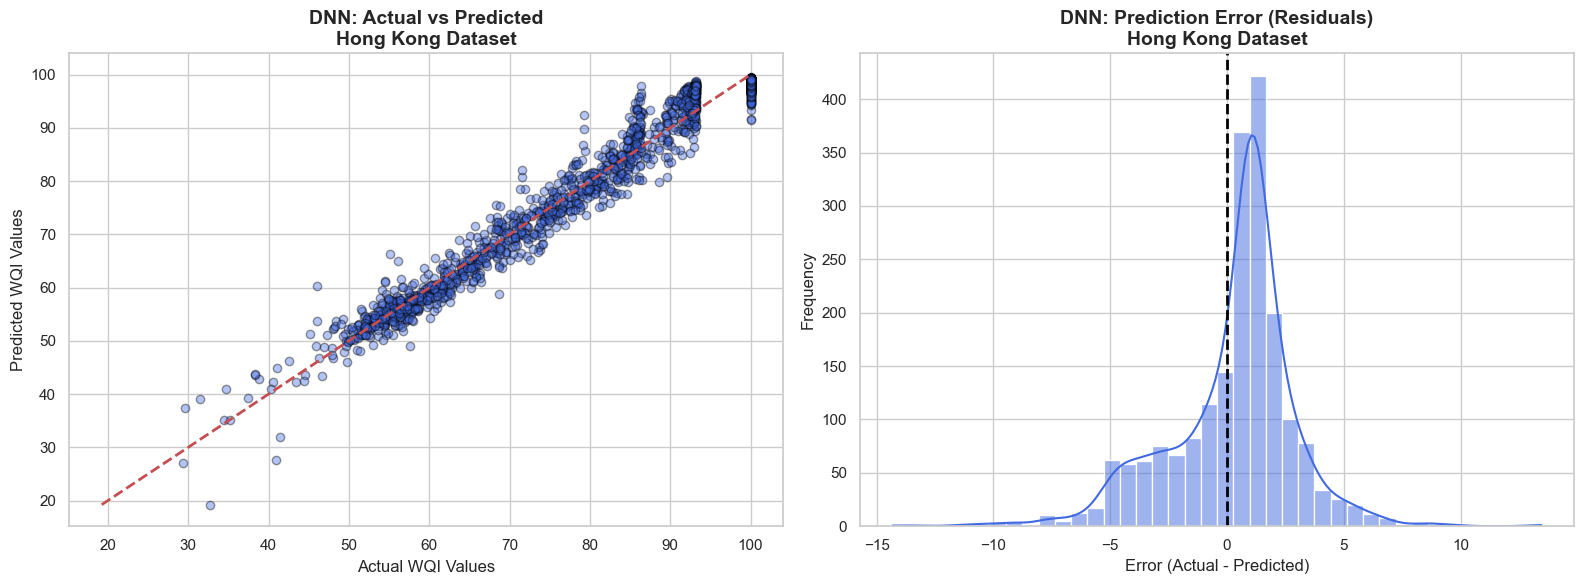

In [48]:
plot_model_residual_evaluation(
    y_test_dnn_hongkong,
    y_pred_dnn_hongkong,
    model_name="DNN",
    evaluation_name="Hong Kong Dataset",
    color="royalblue"
)

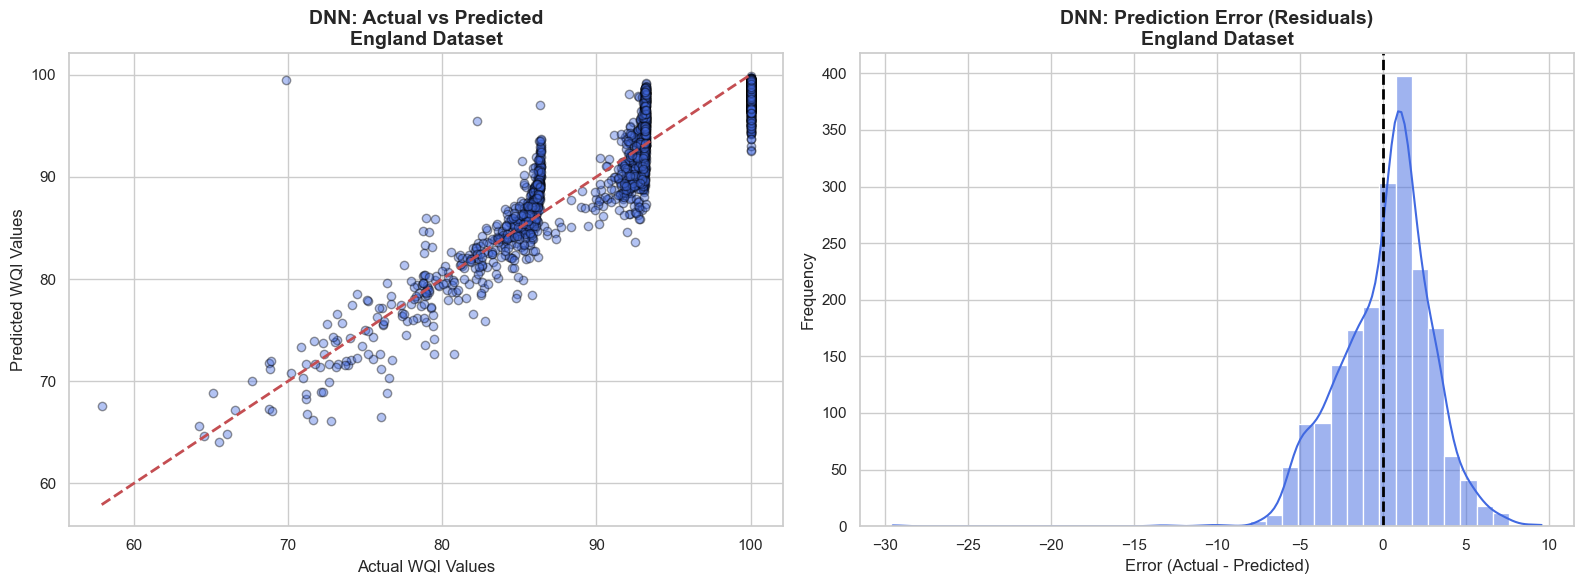

In [49]:
plot_model_residual_evaluation(
    y_test_dnn_england,
    y_pred_dnn_england,
    model_name="DNN",
    evaluation_name="England Dataset",
    color="royalblue"
)

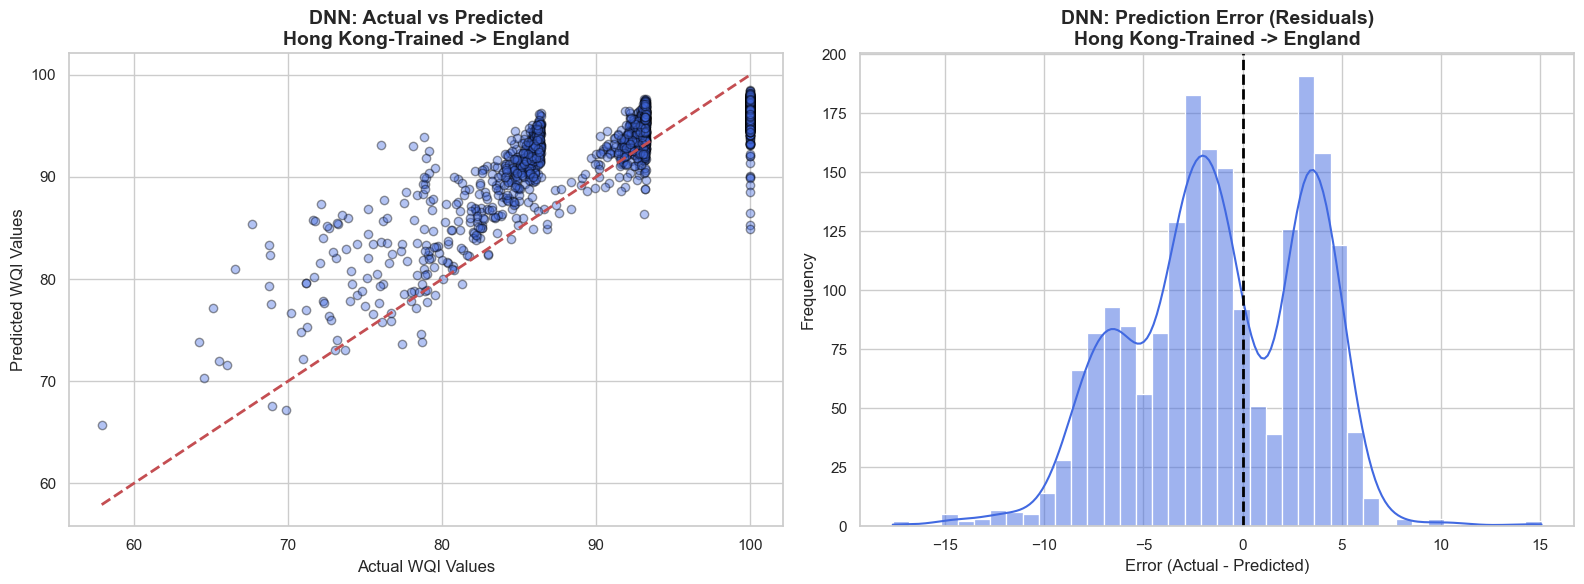

In [50]:
plot_model_residual_evaluation(
    y_test_dnn_hongkong_to_england,
    y_pred_dnn_hongkong_to_england,
    model_name="DNN",
    evaluation_name="Hong Kong-Trained -> England",
    color="royalblue"
)

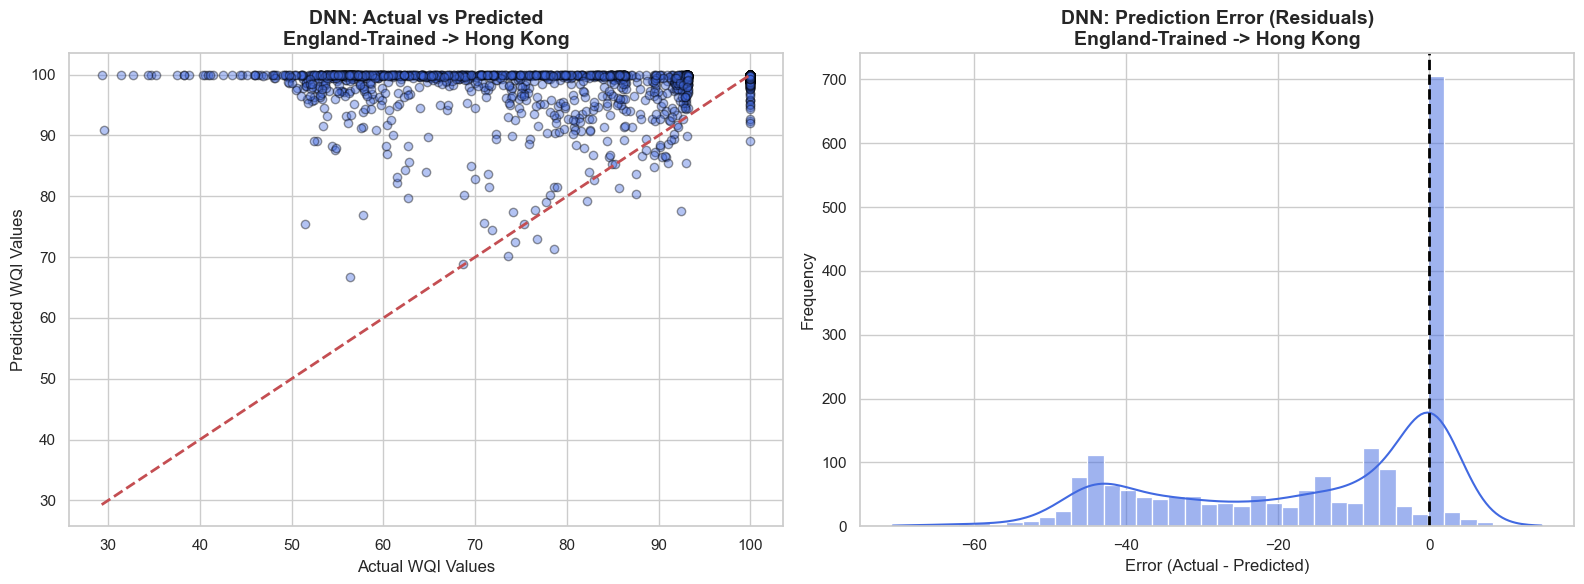

In [51]:
plot_model_residual_evaluation(
    y_test_dnn_england_to_hongkong,
    y_pred_dnn_england_to_hongkong,
    model_name="DNN",
    evaluation_name="England-Trained -> Hong Kong",
    color="royalblue"
)

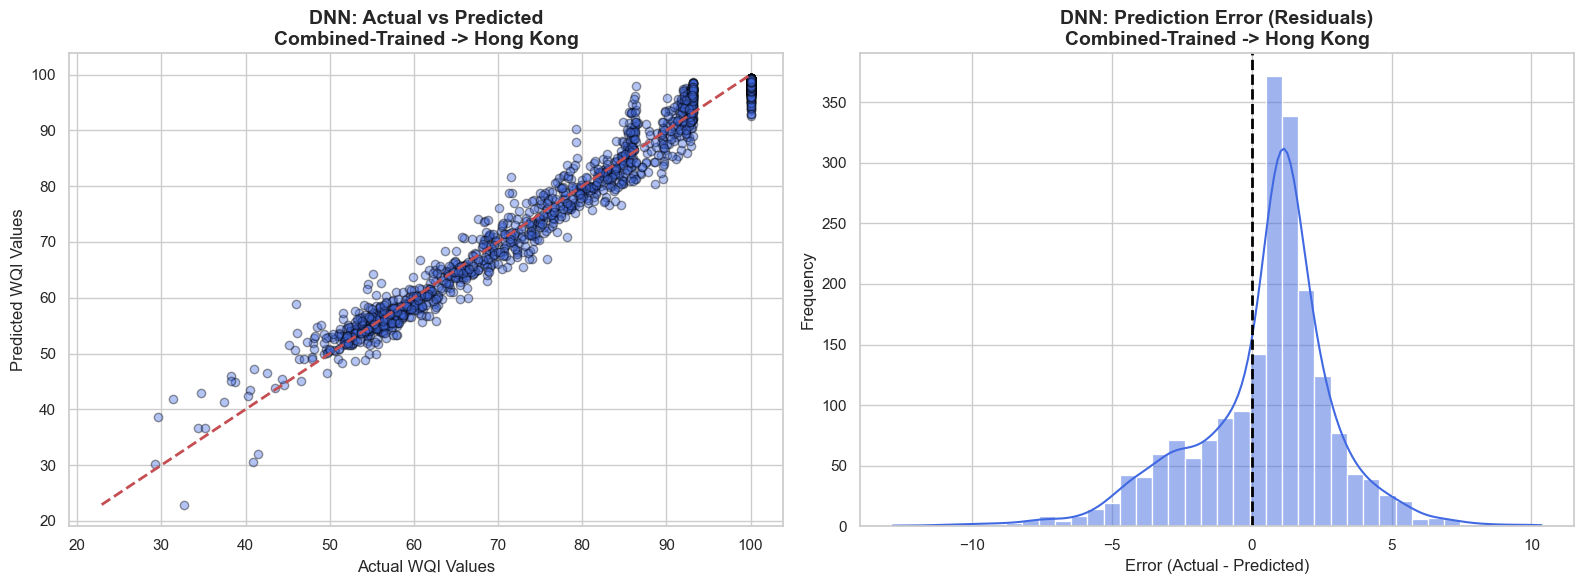

In [52]:
plot_model_residual_evaluation(
    y_test_dnn_combined_to_hongkong,
    y_pred_dnn_combined_to_hongkong,
    model_name="DNN",
    evaluation_name="Combined-Trained -> Hong Kong",
    color="royalblue"
)

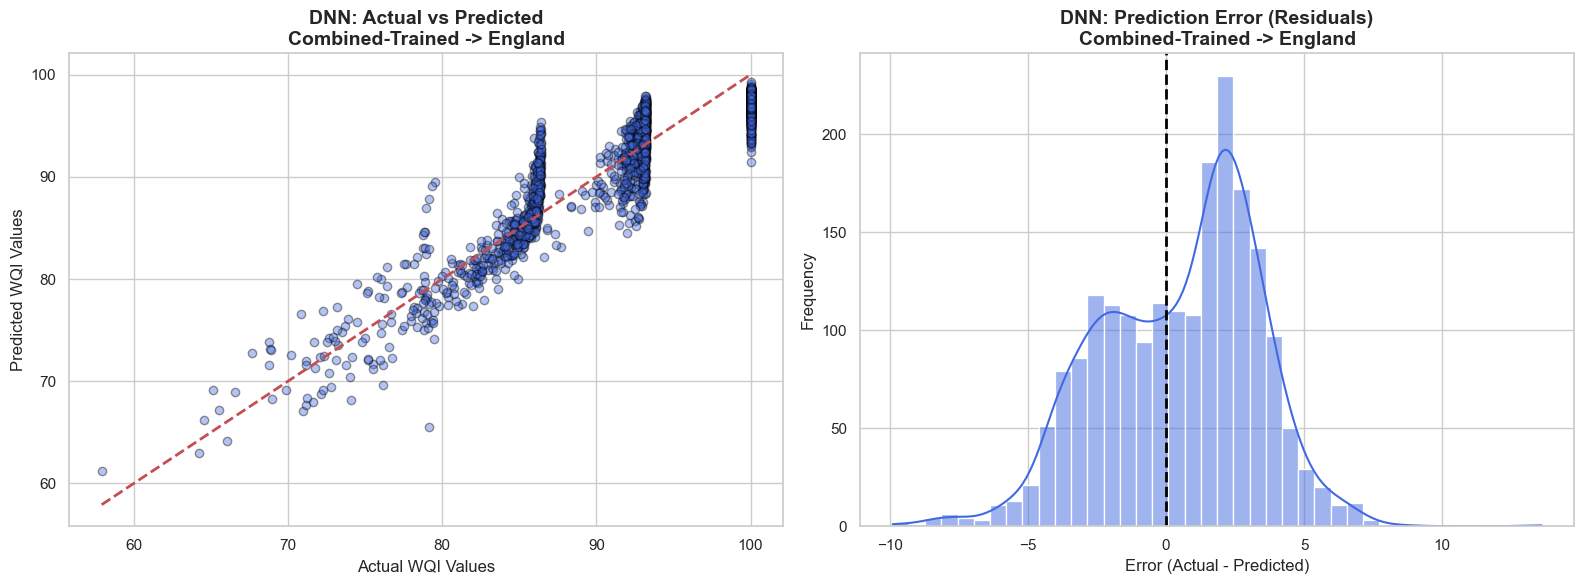

In [53]:
plot_model_residual_evaluation(
    y_test_dnn_combined_to_england,
    y_pred_dnn_combined_to_england,
    model_name="DNN",
    evaluation_name="Combined-Trained -> England",
    color="royalblue"
)

### 🧪 **LightGBM**

In [54]:
from lightgbm import LGBMRegressor

lgbm_model_hongkong = LGBMRegressor(n_estimators=300, max_depth=6, learning_rate=0.1,
                                    subsample=0.8, colsample_bytree=0.8, random_state=SEED,
                                    objective="regression", n_jobs=1
)

lgbm_model_england = LGBMRegressor(n_estimators=300, max_depth=6, learning_rate=0.1,
                                   subsample=0.8, colsample_bytree=0.8, random_state=SEED,
                                   objective="regression", n_jobs=1
)

lgbm_model_combined = LGBMRegressor(n_estimators=300, max_depth=6, learning_rate=0.1,
                                    subsample=0.8, colsample_bytree=0.8, random_state=SEED,
                                    objective="regression", n_jobs=1
)

In [55]:
lgbm_model_hongkong = train_benchmark_ML_model(
    model=lgbm_model_hongkong,
    model_name="LightGBM",
    model_type="lightgbm",
    dataset_name="HongKong",
    X_train=X_train_hongkong_final,
    y_train=y_train_hongkong_final
)


Training LightGBM Benchmark Model
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000762 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5772
[LightGBM] [Info] Number of data points in the train set: 16361, number of used features: 26
[LightGBM] [Info] Start training from score 82.370469
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

In [56]:
lgbm_model_england = train_benchmark_ML_model(
    model=lgbm_model_england,
    model_name="LightGBM",
    model_type="lightgbm",
    dataset_name="England",
    X_train=X_train_england_final,
    y_train=y_train_england_final
)


Training LightGBM Benchmark Model
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000470 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6351
[LightGBM] [Info] Number of data points in the train set: 9148, number of used features: 26
[LightGBM] [Info] Start training from score 92.312551
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

In [57]:
lgbm_model_combined = train_benchmark_ML_model(
    model=lgbm_model_combined,
    model_name="LightGBM",
    model_type="lightgbm",
    dataset_name="Combined",
    X_train=X_train_combined_final,
    y_train=y_train_combined_final
)


Training LightGBM Benchmark Model
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001137 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6560
[LightGBM] [Info] Number of data points in the train set: 25509, number of used features: 26
[LightGBM] [Info] Start training from score 85.935884
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

### ✅ **LightGBM Model Evaluation and Visual Analysis**
We evaluate the LightGBM's model performance using standard regression metrics (R2, RMSE, and MAE).

Furthermore, we generate visual plots (Actual vs. Predicted curve and Feature Importance) to clearly interpret the results and identify which data indicators are the main drivers of the water quality index.

In [58]:
# LightGBM: Hong Kong-Trained -> Hong Kong
y_pred_lgbm_hongkong, rmse_lgbm_hongkong, mae_lgbm_hongkong, r2_lgbm_hongkong = evaluate_ML_model(
    model=lgbm_model_hongkong,
    model_name="LightGBM",
    X_test=X_test_hongkong_final,
    y_test=y_test_hongkong_final,
    evaluation_name="Hong Kong -> Hong Kong"
)


LightGBM Evaluation Results
Evaluation: Hong Kong -> Hong Kong
RMSE: 0.8009
MAE:  0.4450
R2 Score: 0.9980
Number of predictions: 4545


In [59]:
# LightGBM: England-Trained -> England
y_pred_lgbm_england, rmse_lgbm_england, mae_lgbm_england, r2_lgbm_england = evaluate_ML_model(
    model=lgbm_model_england,
    model_name="LightGBM",
    X_test=X_test_england_final,
    y_test=y_test_england_final,
    evaluation_name="England -> England"
)


LightGBM Evaluation Results
Evaluation: England -> England
RMSE: 0.6706
MAE:  0.2521
R2 Score: 0.9912
Number of predictions: 2542


In [60]:
# LightGBM: Hong Kong-Trained -> England
y_pred_lgbm_hongkong_to_england, rmse_lgbm_hongkong_to_england, mae_lgbm_hongkong_to_england, r2_lgbm_hongkong_to_england = evaluate_ML_model(
    model=lgbm_model_hongkong,
    model_name="LightGBM",
    X_test=X_test_england_final,
    y_test=y_test_england_final,
    evaluation_name="Hong Kong -> England"
)


LightGBM Evaluation Results
Evaluation: Hong Kong -> England
RMSE: 1.7391
MAE:  1.1076
R2 Score: 0.9408
Number of predictions: 2542


In [61]:
# LightGBM: England-Trained -> Hong Kong
y_pred_lgbm_england_to_hongkong, rmse_lgbm_england_to_hongkong, mae_lgbm_england_to_hongkong, r2_lgbm_england_to_hongkong = evaluate_ML_model(
    model=lgbm_model_england,
    model_name="LightGBM",
    X_test=X_test_hongkong_final,
    y_test=y_test_hongkong_final,
    evaluation_name="England -> Hong Kong"
)


LightGBM Evaluation Results
Evaluation: England -> Hong Kong
RMSE: 14.9003
MAE:  9.2612
R2 Score: 0.2978
Number of predictions: 4545


In [62]:
# LightGBM: Combined-Trained -> Hong Kong
y_pred_lgbm_combined_to_hongkong, rmse_lgbm_combined_to_hongkong, mae_lgbm_combined_to_hongkong, r2_lgbm_combined_to_hongkong = evaluate_ML_model(
    model=lgbm_model_combined,
    model_name="LightGBM",
    X_test=X_test_hongkong_final,
    y_test=y_test_hongkong_final,
    evaluation_name="Combined -> Hong Kong"
)


LightGBM Evaluation Results
Evaluation: Combined -> Hong Kong
RMSE: 0.7910
MAE:  0.4318
R2 Score: 0.9980
Number of predictions: 4545


In [63]:
# LightGBM: Combined-Trained -> England
y_pred_lgbm_combined_to_england, rmse_lgbm_combined_to_england, mae_lgbm_combined_to_england, r2_lgbm_combined_to_england = evaluate_ML_model(
    model=lgbm_model_combined,
    model_name="LightGBM",
    X_test=X_test_england_final,
    y_test=y_test_england_final,
    evaluation_name="Combined -> England"
)


LightGBM Evaluation Results
Evaluation: Combined -> England
RMSE: 0.3762
MAE:  0.1544
R2 Score: 0.9972
Number of predictions: 2542


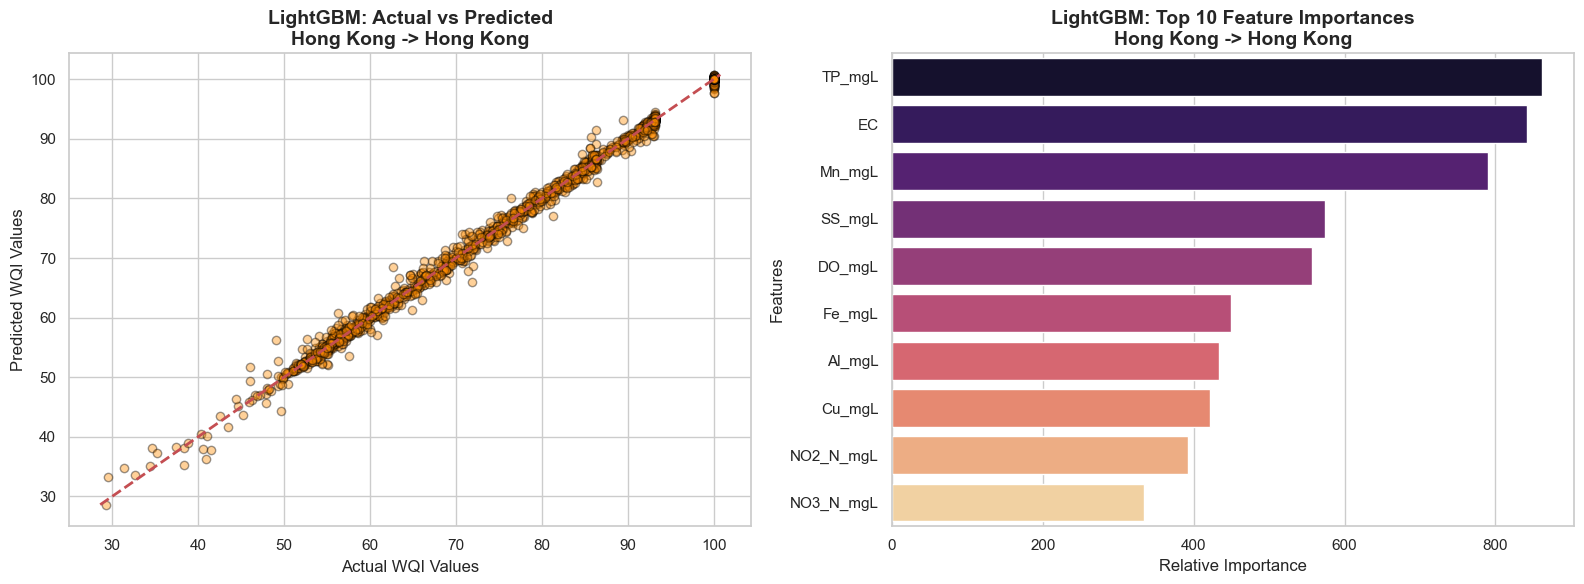

In [64]:
plot_model_importance_evaluation(
    y_true=y_test_hongkong_final,
    y_pred=y_pred_lgbm_hongkong,
    model=lgbm_model_hongkong,
    feature_names=X_train_hongkong_final.columns,
    model_name="LightGBM",
    evaluation_name="Hong Kong -> Hong Kong"
)

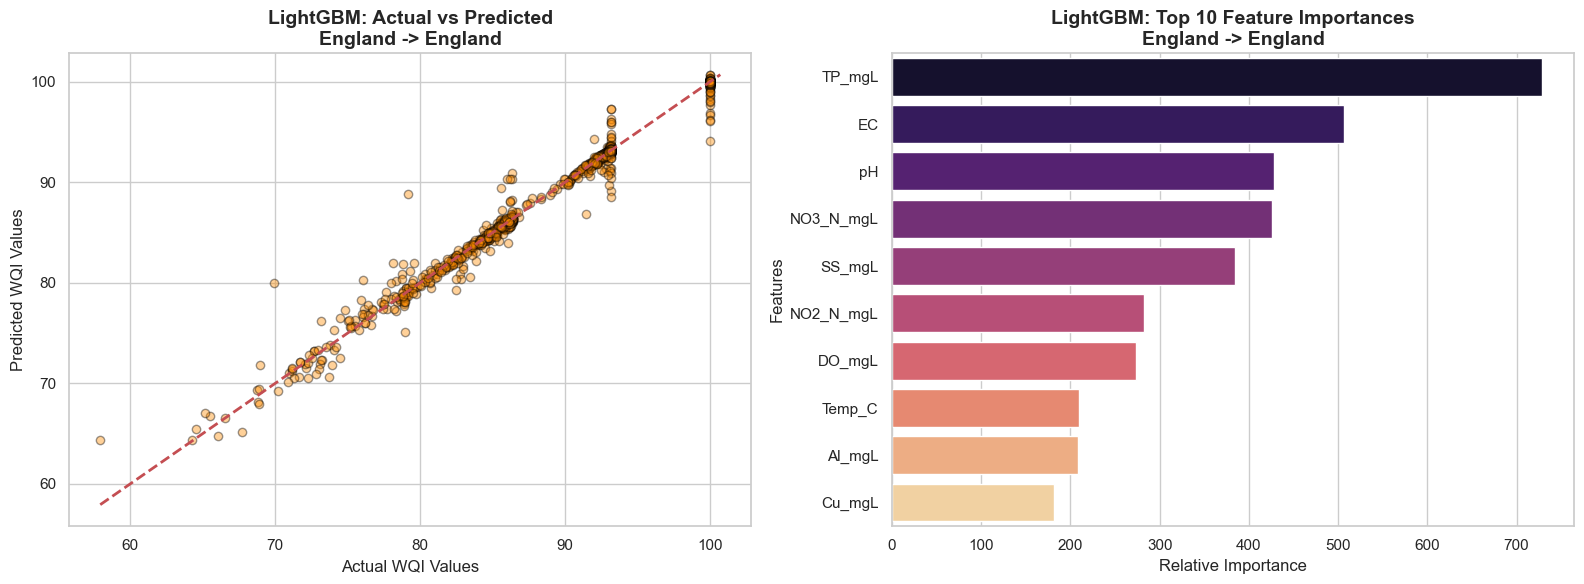

In [65]:
plot_model_importance_evaluation(
    y_true=y_test_england_final,
    y_pred=y_pred_lgbm_england,
    model=lgbm_model_england,
    feature_names=X_train_england_final.columns,
    model_name="LightGBM",
    evaluation_name="England -> England"
)

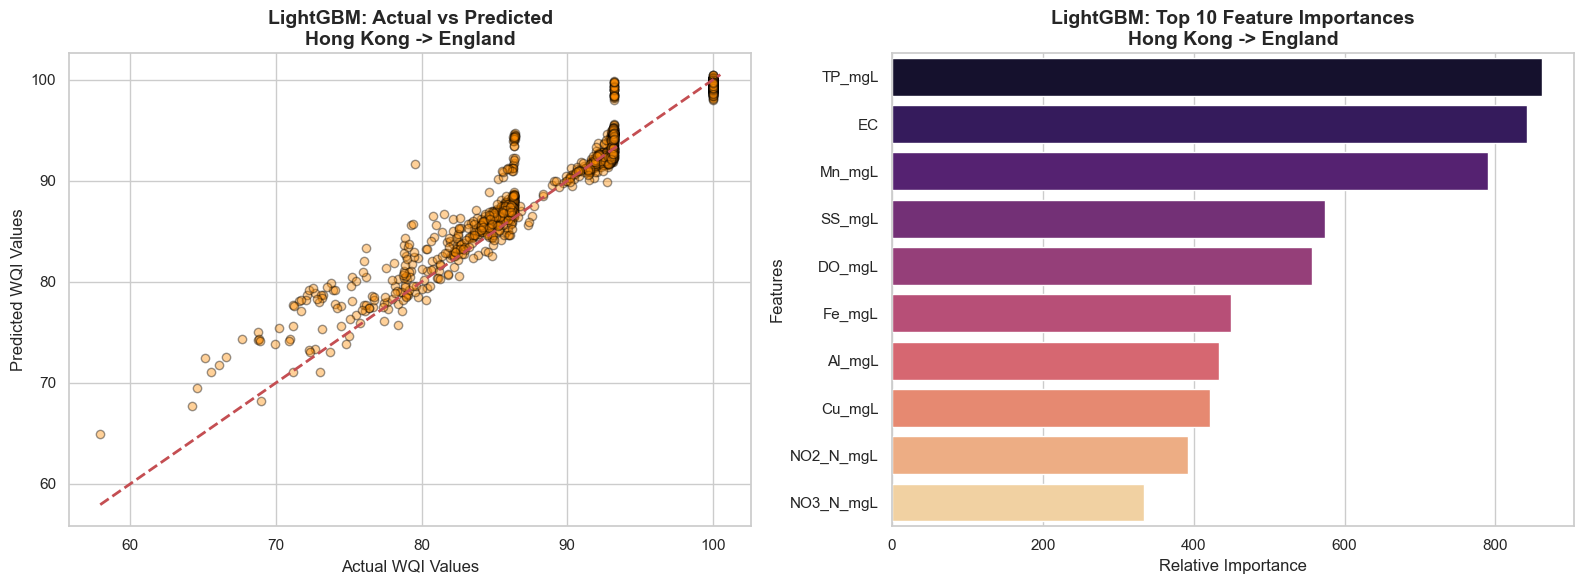

In [66]:
plot_model_importance_evaluation(
    y_true=y_test_england_final,
    y_pred=y_pred_lgbm_hongkong_to_england,
    model=lgbm_model_hongkong,
    feature_names=X_train_hongkong_final.columns,
    model_name="LightGBM",
    evaluation_name="Hong Kong -> England"
)

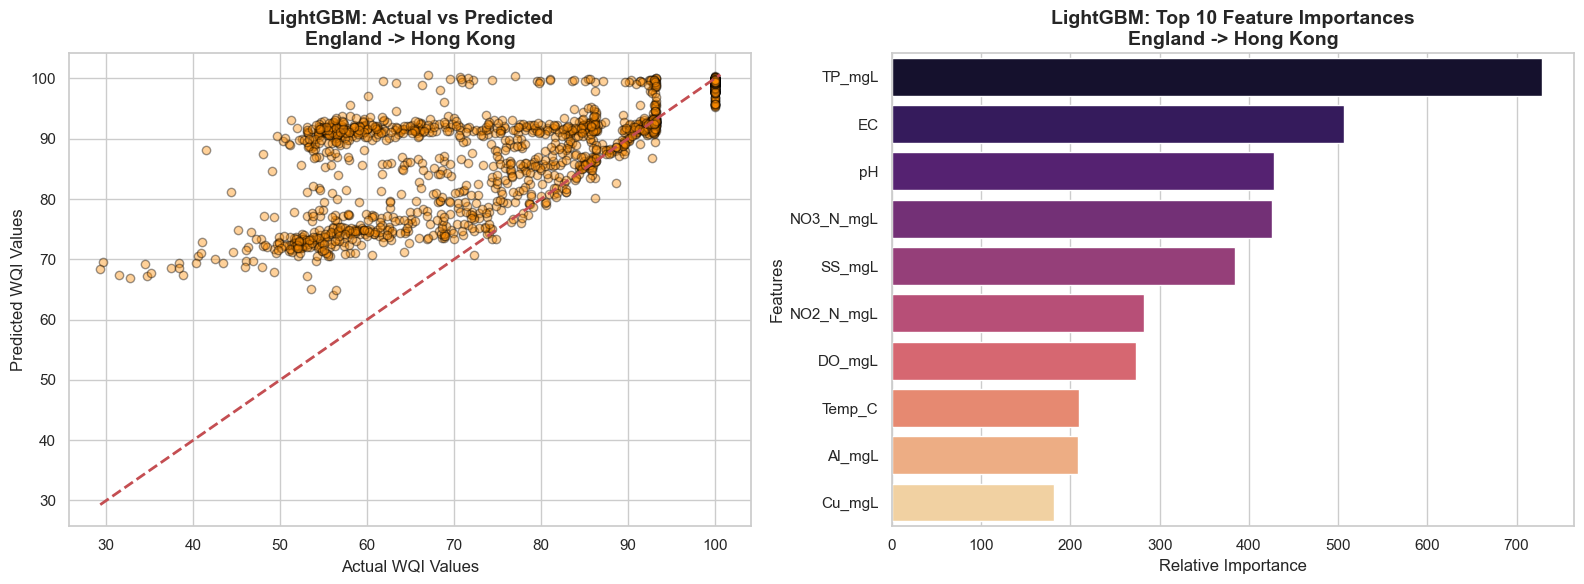

In [67]:
plot_model_importance_evaluation(
    y_true=y_test_hongkong_final,
    y_pred=y_pred_lgbm_england_to_hongkong,
    model=lgbm_model_england,
    feature_names=X_train_england_final.columns,
    model_name="LightGBM",
    evaluation_name="England -> Hong Kong"
)

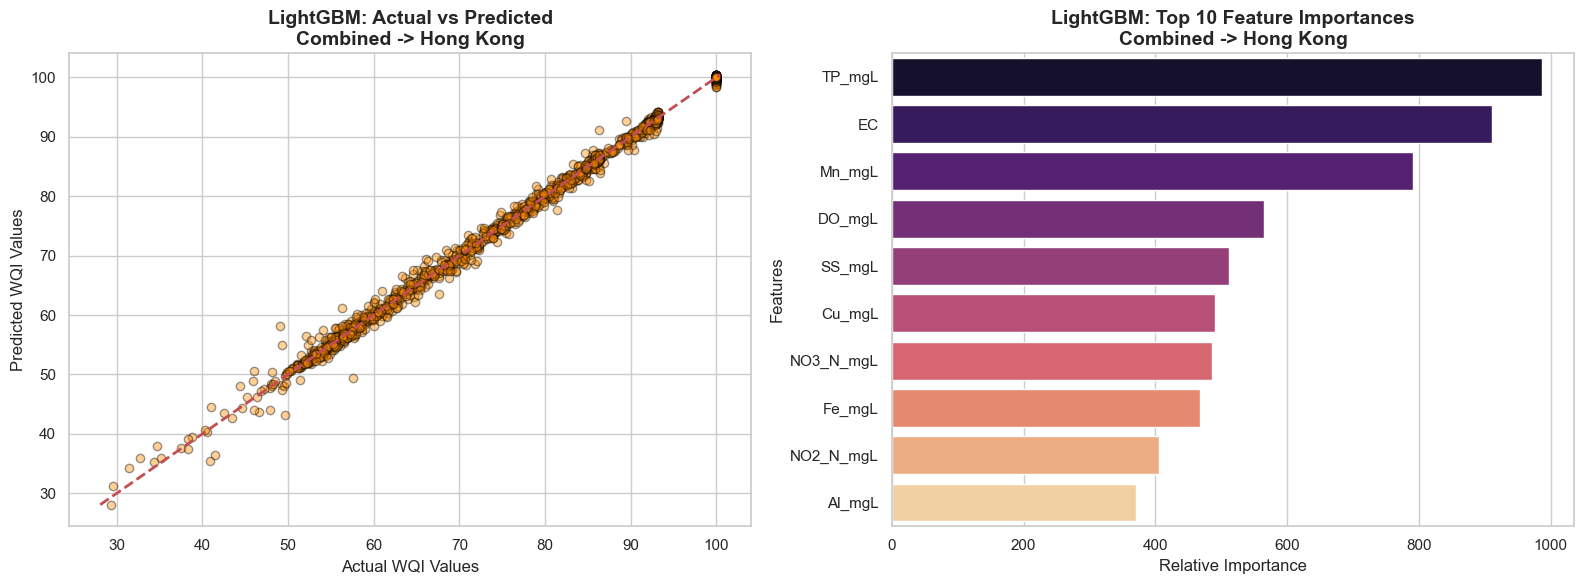

In [68]:
plot_model_importance_evaluation(
    y_true=y_test_hongkong_final,
    y_pred=y_pred_lgbm_combined_to_hongkong,
    model=lgbm_model_combined,
    feature_names=X_train_combined_final.columns,
    model_name="LightGBM",
    evaluation_name="Combined -> Hong Kong"
)

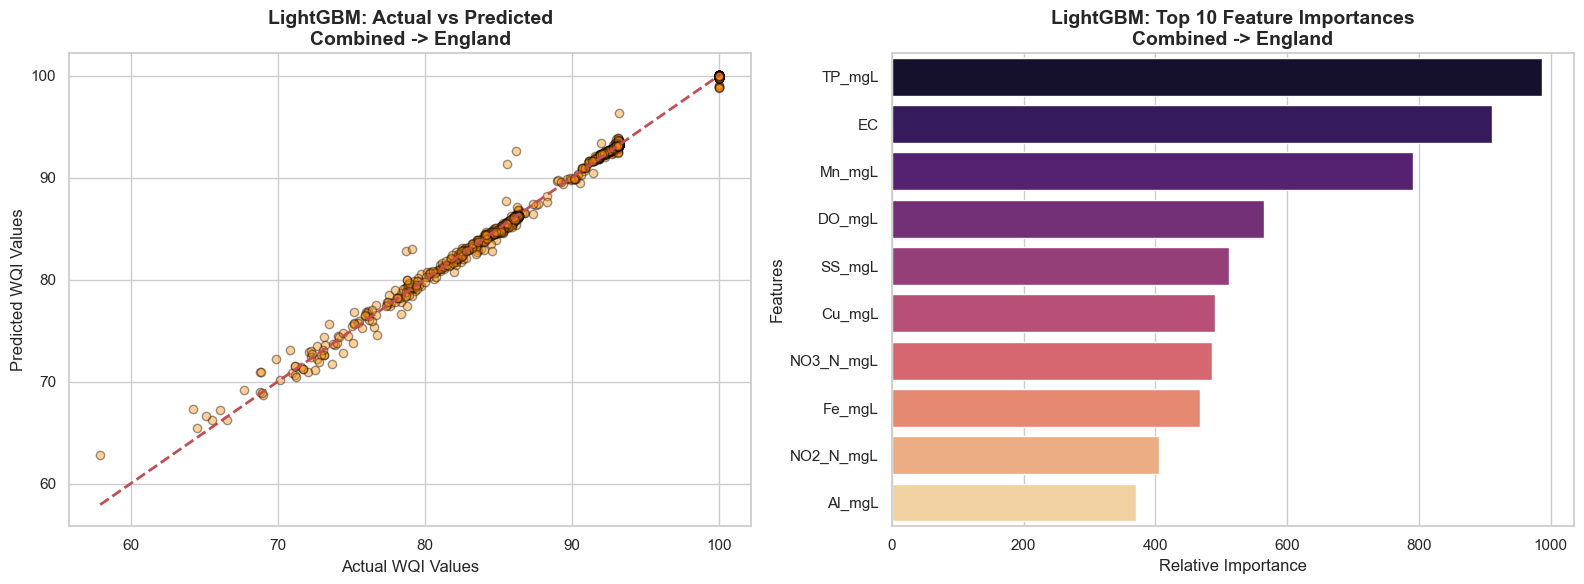

In [69]:
plot_model_importance_evaluation(
    y_true=y_test_england_final,
    y_pred=y_pred_lgbm_combined_to_england,
    model=lgbm_model_combined,
    feature_names=X_train_combined_final.columns,
    model_name="LightGBM",
    evaluation_name="Combined -> England"
)

### 🧪 **XGBoost**

In [70]:
import xgboost as xgb

# Hong Kong XGBoost
xgboost_model_hongkong = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1,
                                          subsample=0.8, colsample_bytree=0.8, random_state=SEED,
                                          objective="reg:squarederror", n_jobs=1)
# England XGBoost
xgboost_model_england = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1,
                                         subsample=0.8, colsample_bytree=0.8, random_state=SEED,
                                         objective="reg:squarederror", n_jobs=1)
# Combined XGBoost
xgboost_model_combined = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1,
                                          subsample=0.8, colsample_bytree=0.8, random_state=SEED,
                                          objective="reg:squarederror", n_jobs=1)

In [71]:
xgboost_model_hongkong = train_benchmark_ML_model(
    model=xgboost_model_hongkong,
    model_name="XGBoost",
    model_type="xgboost",
    dataset_name="HongKong",
    X_train=X_train_hongkong_final,
    y_train=y_train_hongkong_final
)


Training XGBoost Benchmark Model
XGBoost training completed.
XGBoost saved to:
/Users/nqb/Documents/water-quality-prediction-contamination-assessment/model/xgboost_benchmark_hongkong.pkl


In [72]:
xgboost_model_england = train_benchmark_ML_model(
    model=xgboost_model_england,
    model_name="XGBoost",
    model_type="xgboost",
    dataset_name="England",
    X_train=X_train_england_final,
    y_train=y_train_england_final
)


Training XGBoost Benchmark Model
XGBoost training completed.
XGBoost saved to:
/Users/nqb/Documents/water-quality-prediction-contamination-assessment/model/xgboost_benchmark_england.pkl


In [73]:
xgboost_model_combined = train_benchmark_ML_model(
    model=xgboost_model_combined,
    model_name="XGBoost",
    model_type="xgboost",
    dataset_name="Combined",
    X_train=X_train_combined_final,
    y_train=y_train_combined_final
)


Training XGBoost Benchmark Model
XGBoost training completed.
XGBoost saved to:
/Users/nqb/Documents/water-quality-prediction-contamination-assessment/model/xgboost_benchmark_combined.pkl


### ✅ **XGBoost Model Evaluation and Visual Analysis**
We evaluate the XGBoost's model performance using standard regression metrics (R2, RMSE, and MAE).

Furthermore, we generate visual plots (Actual vs. Predicted curve and Feature Importance) to clearly interpret the results and identify which data indicators are the main drivers of the water quality index.

In [74]:
# XGBoost: Hong Kong-Trained -> Hong Kong
y_pred_xgboost_hongkong, rmse_xgboost_hongkong, mae_xgboost_hongkong, r2_xgboost_hongkong = evaluate_ML_model(
    model=xgboost_model_hongkong,
    model_name="XGBoost",
    X_test=X_test_hongkong_final,
    y_test=y_test_hongkong_final,
    evaluation_name="Hong Kong -> Hong Kong"
)


XGBoost Evaluation Results
Evaluation: Hong Kong -> Hong Kong
RMSE: 0.8958
MAE:  0.4464
R2 Score: 0.9975
Number of predictions: 4545


In [75]:
# XGBoost: England-Trained -> England
y_pred_xgboost_england, rmse_xgboost_england, mae_xgboost_england, r2_xgboost_england = evaluate_ML_model(
    model=xgboost_model_england,
    model_name="XGBoost",
    X_test=X_test_england_final,
    y_test=y_test_england_final,
    evaluation_name="England -> England"
)


XGBoost Evaluation Results
Evaluation: England -> England
RMSE: 0.7411
MAE:  0.2399
R2 Score: 0.9893
Number of predictions: 2542


In [76]:
# XGBoost: Hong Kong-Trained -> England
y_pred_xgboost_hongkong_to_england, rmse_xgboost_hongkong_to_england, mae_xgboost_hongkong_to_england, r2_xgboost_hongkong_to_england = evaluate_ML_model(
    model=xgboost_model_hongkong,
    model_name="XGBoost",
    X_test=X_test_england_final,
    y_test=y_test_england_final,
    evaluation_name="Hong Kong -> England"
)


XGBoost Evaluation Results
Evaluation: Hong Kong -> England
RMSE: 2.5297
MAE:  1.7345
R2 Score: 0.8747
Number of predictions: 2542


In [77]:
# XGBoost: England-Trained -> Hong Kong
y_pred_xgboost_england_to_hongkong, rmse_xgboost_england_to_hongkong, mae_xgboost_england_to_hongkong, r2_xgboost_england_to_hongkong = evaluate_ML_model(
    model=xgboost_model_england,
    model_name="XGBoost",
    X_test=X_test_hongkong_final,
    y_test=y_test_hongkong_final,
    evaluation_name="England -> Hong Kong"
)


XGBoost Evaluation Results
Evaluation: England -> Hong Kong
RMSE: 13.3759
MAE:  8.6182
R2 Score: 0.4341
Number of predictions: 4545


In [78]:
# XGBoost: Combined-Trained -> Hong Kong
y_pred_xgboost_combined_to_hongkong, rmse_xgboost_combined_to_hongkong, mae_xgboost_combined_to_hongkong, r2_xgboost_combined_to_hongkong = evaluate_ML_model(
    model=xgboost_model_combined,
    model_name="XGBoost",
    X_test=X_test_hongkong_final,
    y_test=y_test_hongkong_final,
    evaluation_name="Combined -> Hong Kong"
)


XGBoost Evaluation Results
Evaluation: Combined -> Hong Kong
RMSE: 0.9902
MAE:  0.4857
R2 Score: 0.9969
Number of predictions: 4545


In [79]:
# XGBoost: Combined-Trained -> England
y_pred_xgboost_combined_to_england, rmse_xgboost_combined_to_england, mae_xgboost_combined_to_england, r2_xgboost_combined_to_england = evaluate_ML_model(
    model=xgboost_model_combined,
    model_name="XGBoost",
    X_test=X_test_england_final,
    y_test=y_test_england_final,
    evaluation_name="Combined -> England"
)


XGBoost Evaluation Results
Evaluation: Combined -> England
RMSE: 0.4995
MAE:  0.1716
R2 Score: 0.9951
Number of predictions: 2542


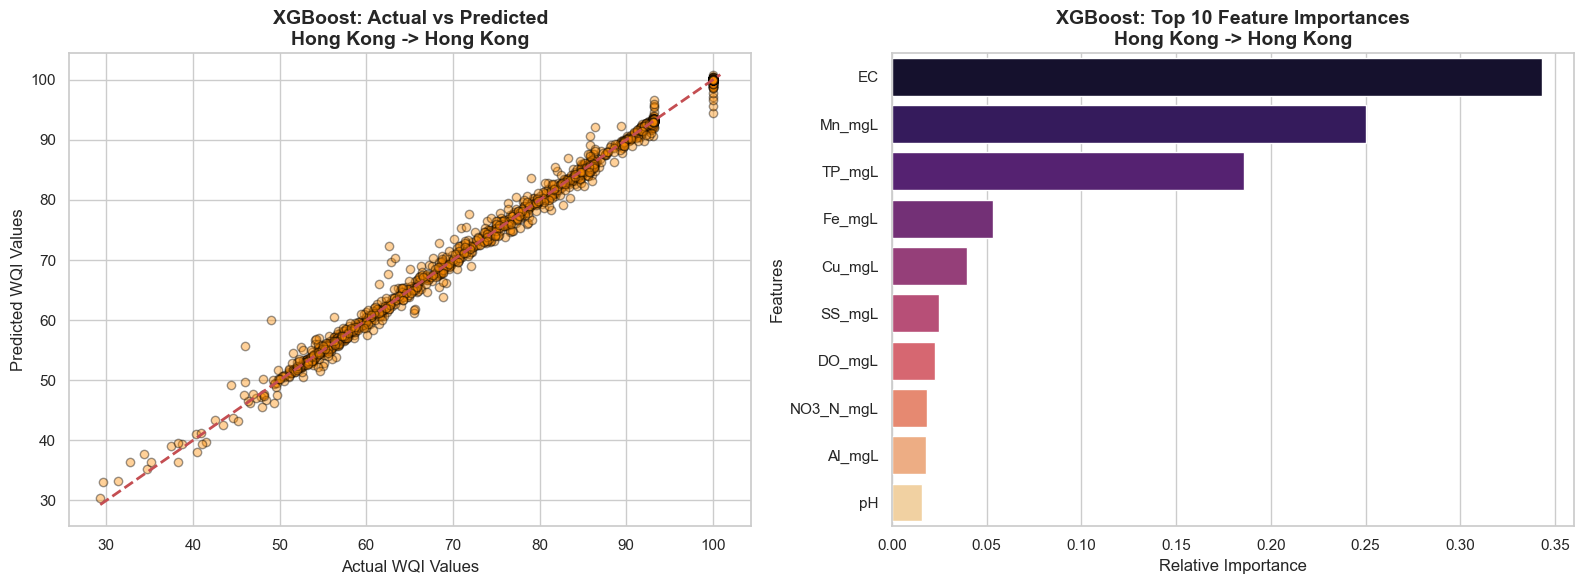

In [80]:
plot_model_importance_evaluation(
    y_true=y_test_hongkong_final,
    y_pred=y_pred_xgboost_hongkong,
    model=xgboost_model_hongkong,
    feature_names=X_train_hongkong_final.columns,
    model_name="XGBoost",
    evaluation_name="Hong Kong -> Hong Kong"
)

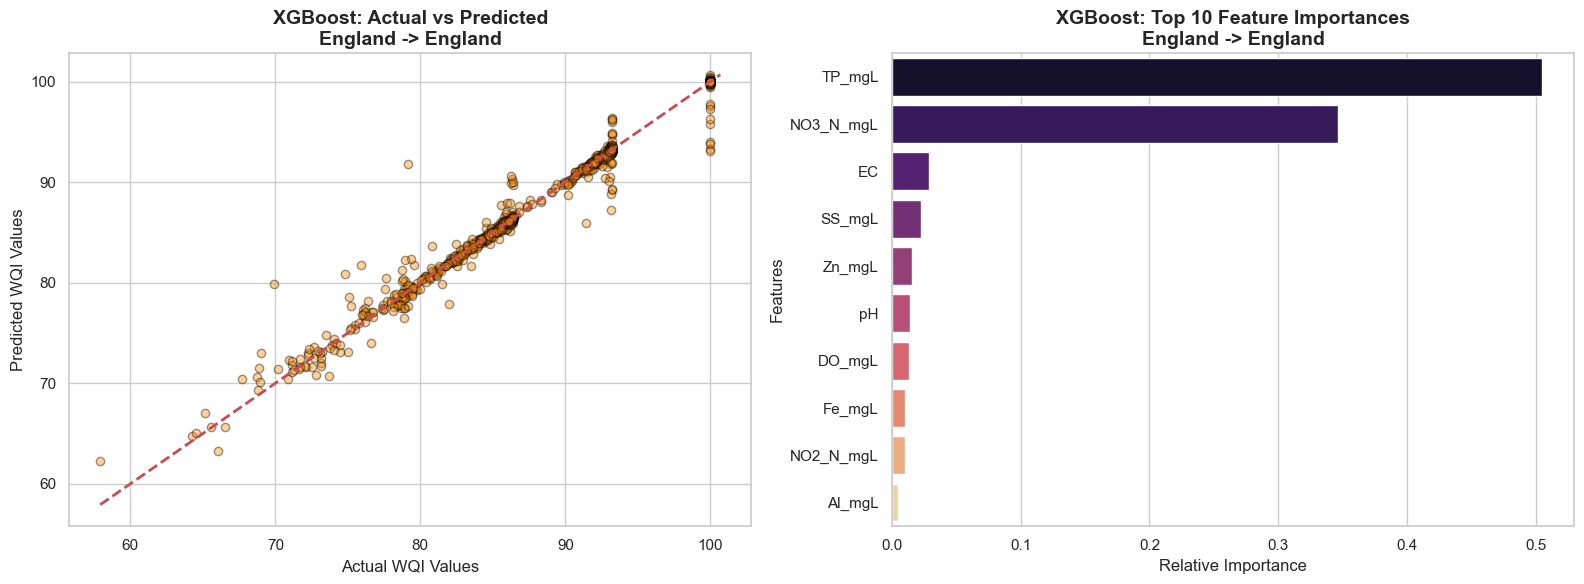

In [81]:
plot_model_importance_evaluation(
    y_true=y_test_england_final,
    y_pred=y_pred_xgboost_england,
    model=xgboost_model_england,
    feature_names=X_train_england_final.columns,
    model_name="XGBoost",
    evaluation_name="England -> England"
)

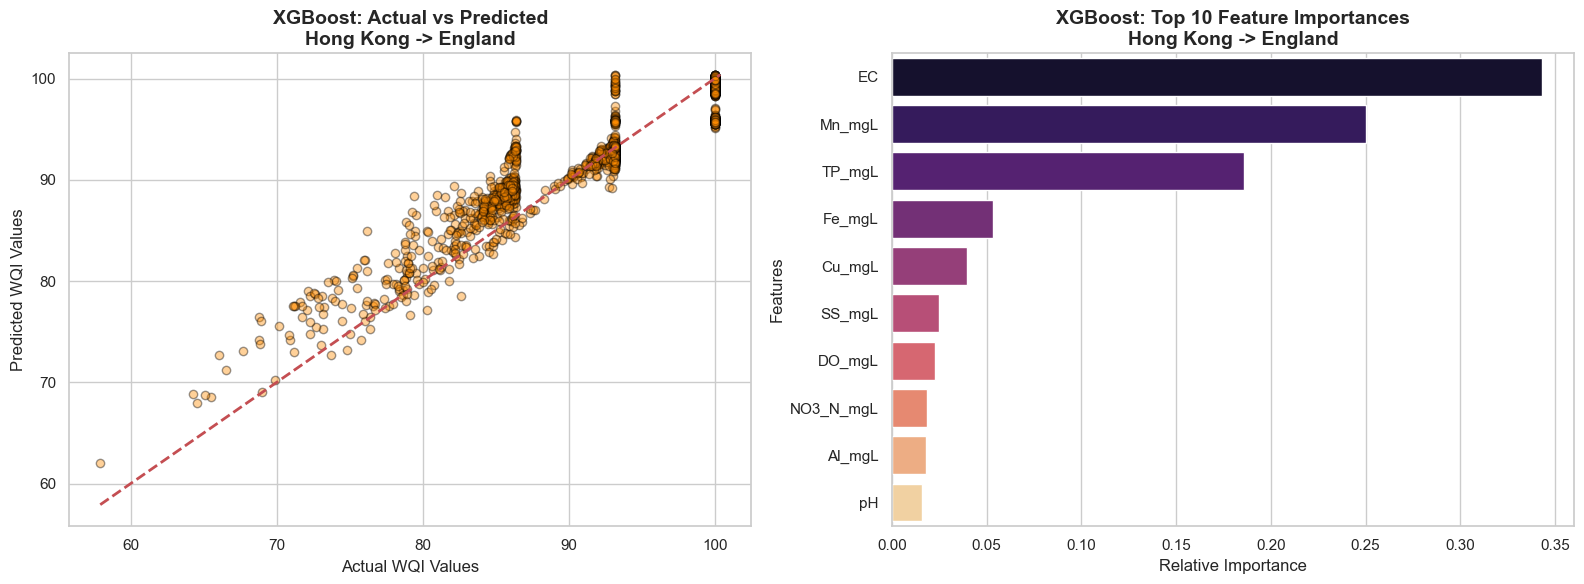

In [82]:
plot_model_importance_evaluation(
    y_true=y_test_england_final,
    y_pred=y_pred_xgboost_hongkong_to_england,
    model=xgboost_model_hongkong,
    feature_names=X_train_hongkong_final.columns,
    model_name="XGBoost",
    evaluation_name="Hong Kong -> England"
)

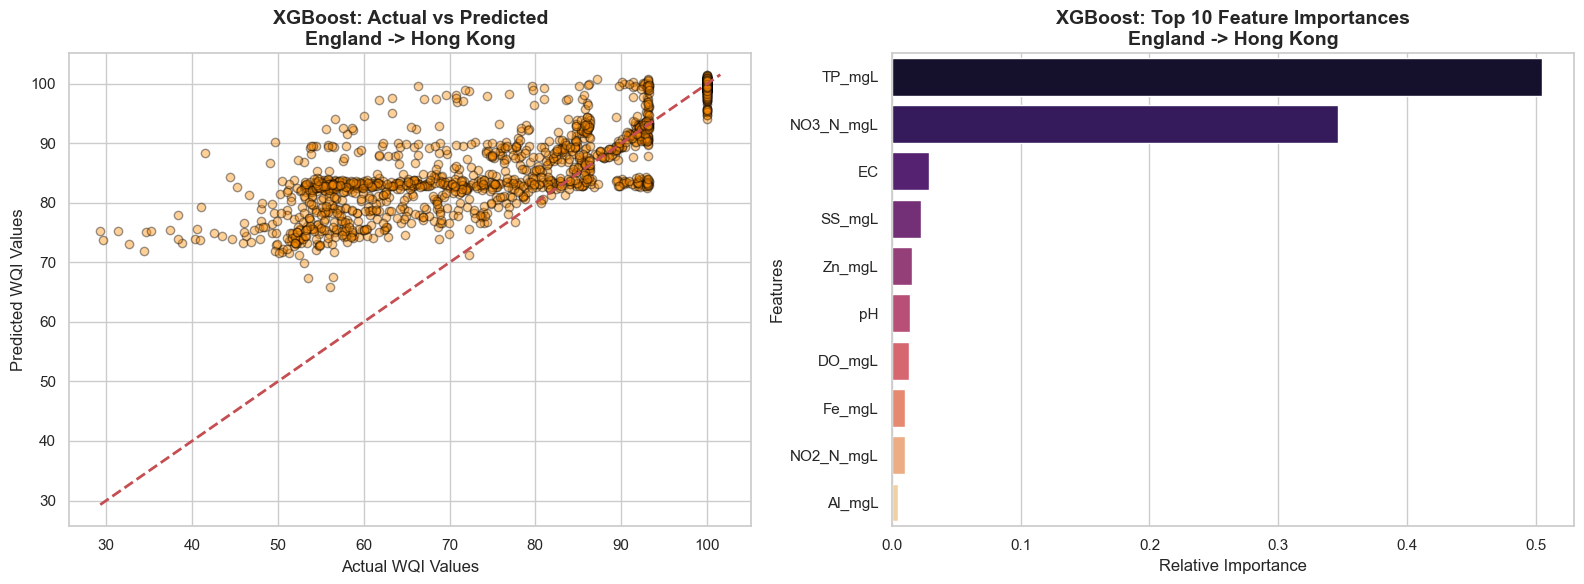

In [83]:
plot_model_importance_evaluation(
    y_true=y_test_hongkong_final,
    y_pred=y_pred_xgboost_england_to_hongkong,
    model=xgboost_model_england,
    feature_names=X_train_england_final.columns,
    model_name="XGBoost",
    evaluation_name="England -> Hong Kong"
)

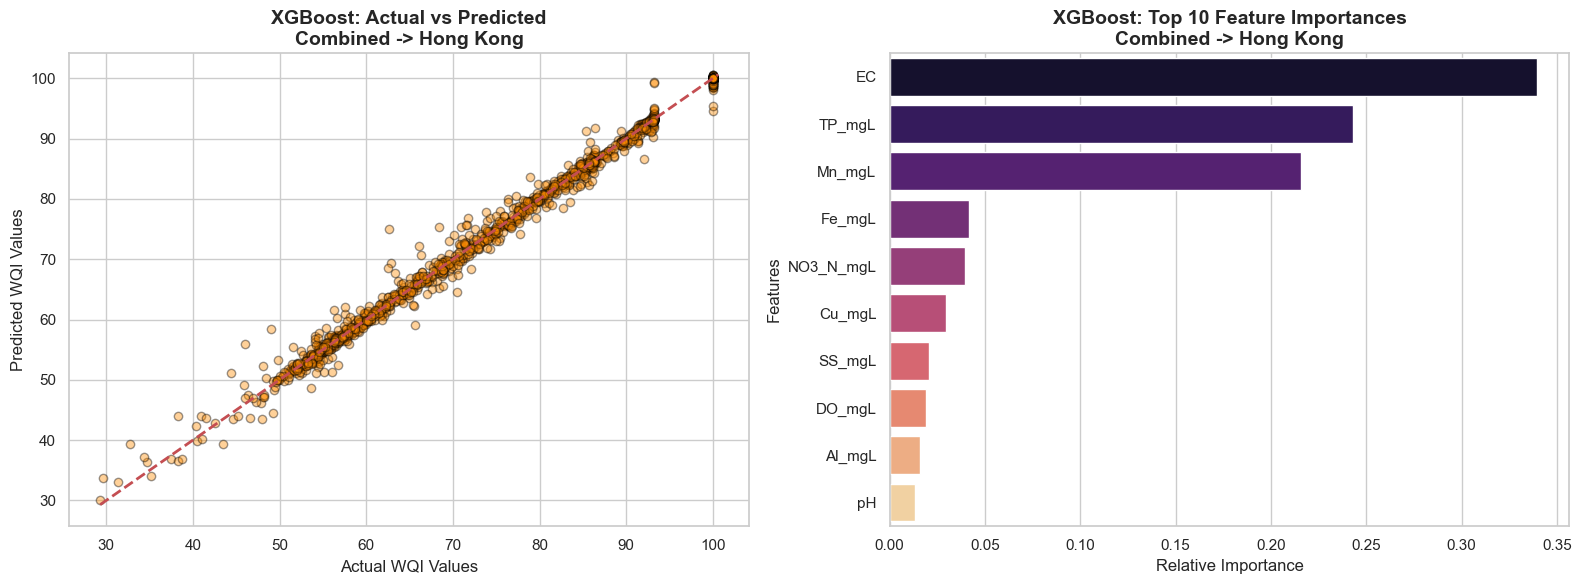

In [84]:
plot_model_importance_evaluation(
    y_true=y_test_hongkong_final,
    y_pred=y_pred_xgboost_combined_to_hongkong,
    model=xgboost_model_combined,
    feature_names=X_train_combined_final.columns,
    model_name="XGBoost",
    evaluation_name="Combined -> Hong Kong"
)

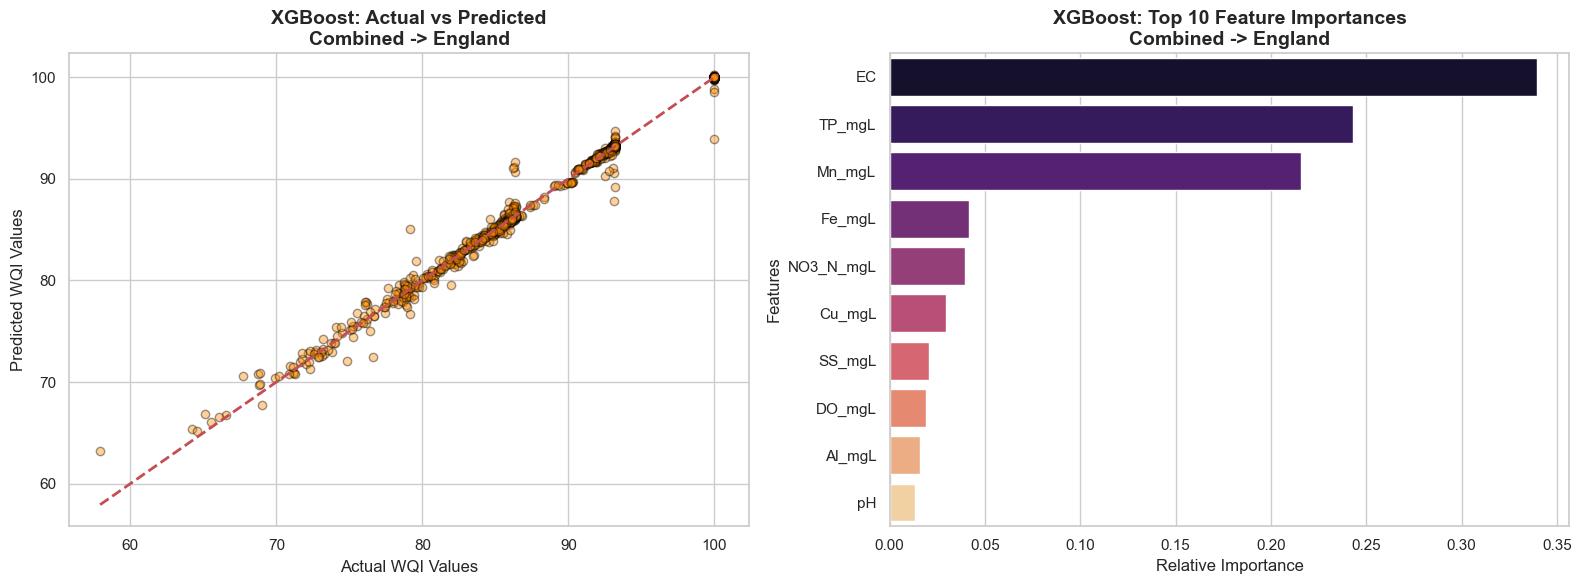

In [85]:
plot_model_importance_evaluation(
    y_true=y_test_england_final,
    y_pred=y_pred_xgboost_combined_to_england,
    model=xgboost_model_combined,
    feature_names=X_train_combined_final.columns,
    model_name="XGBoost",
    evaluation_name="Combined -> England"
)

In [86]:
# Create baseline dataset using all features
df_baseline = Cleaned_River_Water_Quality_df.copy()

# Drop unused columns
cols_to_drop = ['lat_round', 'lon_round']
df_baseline = df_baseline.drop(columns=[col for col in cols_to_drop if col in df_baseline.columns])

incoming_sample_df = df_baseline.sample(n=100, random_state=SEED).reset_index(drop=True)

# Export clean data for ML modeling
incoming_sample_df.to_csv(os.path.join(data_dir, "incoming_river_water_quality.csv"), index=False)

incoming_sample_df.head(10)

,River,Date,Latitude,Longitude,EC,Temp_C,SS_mgL,pH,TP_mgL,NO2_N_mgL,...,red,blue,Country,NDVI,NDWI,MNDWI,NDBI,NDMI,NDTI,WQI
0,River Ganges,2012-11-01,22.528056,114.154444,309.0,22.8,6.10,7.10,0.360,0.300,...,12210.0,11353.5,Hong Kong,0.130729,-0.220698,-0.143207,-0.080020,0.080020,0.092642,92.298013
1,Ho Chung River,2022-01-10,22.354944,114.247028,129.0,18.9,2.80,7.10,0.030,0.006,...,15142.0,14208.0,Hong Kong,0.163079,-0.146445,-0.009108,-0.137521,0.137521,-0.017040,100.000000
2,Kai Tak River,2008-02-18,22.339389,114.197528,16799.0,20.4,9.40,7.10,1.200,2.400,...,11896.0,11233.5,Hong Kong,0.055311,-0.052427,-0.063955,0.011566,-0.011566,-0.002892,51.988529
3,Tuen Mun River,2023-03-13,22.397056,113.973278,36302.0,20.3,7.50,7.90,0.080,0.029,...,10712.0,10139.5,Hong Kong,0.037967,-0.043637,-0.014493,-0.029163,0.029163,0.005680,56.376520
4,Tin Shui Wai Nullah,2013-04-24,22.429444,113.995444,129.0,28.5,2.30,8.00,0.050,0.019,...,10959.5,10047.5,Hong Kong,0.144157,-0.150310,-0.125914,-0.024867,0.024867,0.006290,100.000000
5,Wye at Bourne End,2014-06-16,51.571176,-0.710007,667.0,13.7,7.84,7.92,0.073,0.000,...,8953.5,8274.0,England,0.198649,-0.193282,-0.134768,-0.060078,0.060078,-0.005581,93.194604
6,Tin Sum Nullah,2014-01-10,22.361889,114.169556,106.0,18.3,0.80,7.60,0.010,0.001,...,9925.0,9338.0,Hong Kong,0.157524,-0.145924,-0.086530,-0.060154,0.060154,-0.011872,100.000000
7,Cherwell at Hampton Poyle,2016-11-07,51.833191,-1.277240,923.8,6.4,3.46,7.76,0.527,0.000,...,8601.0,8210.0,England,0.382012,-0.356070,-0.183835,-0.184299,0.184299,-0.030026,84.702111
8,Ho Chung River,2021-01-28,22.354667,114.250556,14850.0,18.6,5.00,7.10,0.380,0.036,...,10582.5,9515.0,Hong Kong,0.113953,-0.124189,-0.075812,-0.048837,0.048837,0.010383,61.764918
9,Lam Tsuen River,2018-12-06,22.461389,114.147111,58.0,23.3,1.60,7.60,0.040,0.006,...,10174.5,9280.0,Hong Kong,0.219058,-0.220698,-0.143207,-0.080020,0.080020,0.001723,100.000000


### 🧪 **Hybrid DNN-XGBoost Model (Main)**
1. **DNN:** Trained to capture complex patterns and feature interactions from the input data.
2. **Feature Extraction:** Dense feature representations are extracted from the DNN's layer.
3. **XGBoost:** An XGBoost regressor is trained using these high-level extracted features to generate the final prediction.

In [87]:
# Define Hybrid DNN Architecture
class WaterQualityDNN(nn.Module):
    def __init__(self, num_features):
        super(WaterQualityDNN, self).__init__()

        self.feature_extractor = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        self.regressor = nn.Linear(64, 1)

    def forward(self, x):
        # Extract learned features
        features = self.feature_extractor(x)

        # Auxiliary DNN prediction constrained to 0-1
        output = torch.sigmoid(self.regressor(features))

        return output, features

In [88]:
# Hong Kong Hybrid DNN
set_seed(SEED)
generator_hongkong.manual_seed(SEED)

dnn_hybrid_model_hongkong = WaterQualityDNN(num_features=X_train_hongkong_final_scaled.shape[1])

In [89]:
dnn_hybrid_model_hongkong, hybrid_dnn_train_losses_hongkong, hybrid_dnn_val_losses_hongkong = train_benchmark_DL_model(
    model=dnn_hybrid_model_hongkong,
    model_name="Hybrid DNN",
    model_type="pytorch",
    dataset_name="HongKong",
    train_loader=train_loader_hongkong,
    val_loader=val_loader_hongkong,
    device=device,
    epochs=100,
    patience=5
)


Training Hybrid DNN Benchmark Model
Dataset: HongKong
Using device: cpu


Epoch [1/100] | Train Loss: 0.045594 | Val Loss: 0.009703 | Train RMSE: 21.3526 WQI | Val RMSE: 9.8504 WQI
Validation loss improved. Best model saved.


Epoch [2/100] | Train Loss: 0.006492 | Val Loss: 0.003599 | Train RMSE: 8.0574 WQI | Val RMSE: 5.9994 WQI
Validation loss improved. Best model saved.


Epoch [3/100] | Train Loss: 0.003995 | Val Loss: 0.002404 | Train RMSE: 6.3203 WQI | Val RMSE: 4.9035 WQI
Validation loss improved. Best model saved.


Epoch [4/100] | Train Loss: 0.003263 | Val Loss: 0.001679 | Train RMSE: 5.7124 WQI | Val RMSE: 4.0972 WQI
Validation loss improved. Best model saved.


Epoch [5/100] | Train Loss: 0.002647 | Val Loss: 0.001707 | Train RMSE: 5.1447 WQI | Val RMSE: 4.1316 WQI
Early Stopping Counter: 1/5


Epoch [6/100] | Train Loss: 0.002340 | Val Loss: 0.001647 | Train RMSE: 4.8374 WQI | Val RMSE: 4.0589 WQI
Validation loss improved. Best model saved.


Epoch [7/100] | Train Loss: 0.002164 | Val Loss: 0.001251 | Train RMSE: 4.6520 WQI | Val RMSE: 3.5365 WQI
Validation loss improved. Best model saved.


Epoch [8/100] | Train Loss: 0.002056 | Val Loss: 0.001286 | Train RMSE: 4.5339 WQI | Val RMSE: 3.5855 WQI
Early Stopping Counter: 1/5


Epoch [9/100] | Train Loss: 0.001924 | Val Loss: 0.001243 | Train RMSE: 4.3869 WQI | Val RMSE: 3.5251 WQI
Validation loss improved. Best model saved.


Epoch [10/100] | Train Loss: 0.001843 | Val Loss: 0.001134 | Train RMSE: 4.2933 WQI | Val RMSE: 3.3672 WQI
Validation loss improved. Best model saved.


Epoch [11/100] | Train Loss: 0.001808 | Val Loss: 0.001047 | Train RMSE: 4.2517 WQI | Val RMSE: 3.2359 WQI
Validation loss improved. Best model saved.


Epoch [12/100] | Train Loss: 0.001727 | Val Loss: 0.001425 | Train RMSE: 4.1557 WQI | Val RMSE: 3.7744 WQI
Early Stopping Counter: 1/5


Epoch [13/100] | Train Loss: 0.001708 | Val Loss: 0.001440 | Train RMSE: 4.1324 WQI | Val RMSE: 3.7946 WQI
Early Stopping Counter: 2/5


Epoch [14/100] | Train Loss: 0.001657 | Val Loss: 0.001295 | Train RMSE: 4.0711 WQI | Val RMSE: 3.5992 WQI
Early Stopping Counter: 3/5


Epoch [15/100] | Train Loss: 0.001609 | Val Loss: 0.000949 | Train RMSE: 4.0111 WQI | Val RMSE: 3.0798 WQI
Validation loss improved. Best model saved.


Epoch [16/100] | Train Loss: 0.001515 | Val Loss: 0.001757 | Train RMSE: 3.8918 WQI | Val RMSE: 4.1921 WQI
Early Stopping Counter: 1/5


Epoch [17/100] | Train Loss: 0.001571 | Val Loss: 0.000941 | Train RMSE: 3.9639 WQI | Val RMSE: 3.0676 WQI
Validation loss improved. Best model saved.


Epoch [18/100] | Train Loss: 0.001478 | Val Loss: 0.001740 | Train RMSE: 3.8443 WQI | Val RMSE: 4.1719 WQI
Early Stopping Counter: 1/5


Epoch [19/100] | Train Loss: 0.001473 | Val Loss: 0.000878 | Train RMSE: 3.8375 WQI | Val RMSE: 2.9629 WQI
Validation loss improved. Best model saved.


Epoch [20/100] | Train Loss: 0.001415 | Val Loss: 0.000855 | Train RMSE: 3.7613 WQI | Val RMSE: 2.9242 WQI
Validation loss improved. Best model saved.


Epoch [21/100] | Train Loss: 0.001439 | Val Loss: 0.000927 | Train RMSE: 3.7932 WQI | Val RMSE: 3.0450 WQI
Early Stopping Counter: 1/5


Epoch [22/100] | Train Loss: 0.001404 | Val Loss: 0.000818 | Train RMSE: 3.7466 WQI | Val RMSE: 2.8596 WQI
Validation loss improved. Best model saved.


Epoch [23/100] | Train Loss: 0.001378 | Val Loss: 0.000833 | Train RMSE: 3.7118 WQI | Val RMSE: 2.8860 WQI
Early Stopping Counter: 1/5


Epoch [24/100] | Train Loss: 0.001371 | Val Loss: 0.001428 | Train RMSE: 3.7029 WQI | Val RMSE: 3.7786 WQI
Early Stopping Counter: 2/5


Epoch [25/100] | Train Loss: 0.001328 | Val Loss: 0.000847 | Train RMSE: 3.6435 WQI | Val RMSE: 2.9103 WQI
Early Stopping Counter: 3/5


Epoch [26/100] | Train Loss: 0.001318 | Val Loss: 0.000806 | Train RMSE: 3.6308 WQI | Val RMSE: 2.8383 WQI
Validation loss improved. Best model saved.


Epoch [27/100] | Train Loss: 0.001320 | Val Loss: 0.000849 | Train RMSE: 3.6326 WQI | Val RMSE: 2.9143 WQI
Early Stopping Counter: 1/5


Epoch [28/100] | Train Loss: 0.001269 | Val Loss: 0.000806 | Train RMSE: 3.5628 WQI | Val RMSE: 2.8394 WQI
Early Stopping Counter: 2/5


Epoch [29/100] | Train Loss: 0.001273 | Val Loss: 0.000759 | Train RMSE: 3.5678 WQI | Val RMSE: 2.7550 WQI
Validation loss improved. Best model saved.


Epoch [30/100] | Train Loss: 0.001250 | Val Loss: 0.000781 | Train RMSE: 3.5357 WQI | Val RMSE: 2.7953 WQI
Early Stopping Counter: 1/5


Epoch [31/100] | Train Loss: 0.001235 | Val Loss: 0.001361 | Train RMSE: 3.5139 WQI | Val RMSE: 3.6886 WQI
Early Stopping Counter: 2/5


Epoch [32/100] | Train Loss: 0.001245 | Val Loss: 0.000741 | Train RMSE: 3.5281 WQI | Val RMSE: 2.7222 WQI
Validation loss improved. Best model saved.


Epoch [33/100] | Train Loss: 0.001216 | Val Loss: 0.000713 | Train RMSE: 3.4870 WQI | Val RMSE: 2.6711 WQI
Validation loss improved. Best model saved.


Epoch [34/100] | Train Loss: 0.001202 | Val Loss: 0.001188 | Train RMSE: 3.4673 WQI | Val RMSE: 3.4471 WQI
Early Stopping Counter: 1/5


Epoch [35/100] | Train Loss: 0.001238 | Val Loss: 0.000741 | Train RMSE: 3.5186 WQI | Val RMSE: 2.7218 WQI
Early Stopping Counter: 2/5


Epoch [36/100] | Train Loss: 0.001195 | Val Loss: 0.001736 | Train RMSE: 3.4562 WQI | Val RMSE: 4.1662 WQI
Early Stopping Counter: 3/5


Epoch [37/100] | Train Loss: 0.001169 | Val Loss: 0.000731 | Train RMSE: 3.4194 WQI | Val RMSE: 2.7032 WQI
Early Stopping Counter: 4/5


Epoch [38/100] | Train Loss: 0.001150 | Val Loss: 0.000719 | Train RMSE: 3.3916 WQI | Val RMSE: 2.6821 WQI
Early Stopping Counter: 5/5
Early stopping triggered.

Hybrid DNN Training Complete
Best Validation Loss: 0.000713
Best Validation RMSE: 2.6711 WQI
Model saved to: /Users/nqb/Documents/water-quality-prediction-contamination-assessment/model/hybrid_dnn_benchmark_hongkong.pth


In [90]:
# England Hybrid DNN
set_seed(SEED)
generator_england.manual_seed(SEED)

dnn_hybrid_model_england = WaterQualityDNN(num_features=X_train_england_final_scaled.shape[1])

In [91]:
dnn_hybrid_model_england, hybrid_dnn_train_losses_england, hybrid_dnn_val_losses_england = train_benchmark_DL_model(
    model=dnn_hybrid_model_england,
    model_name="Hybrid DNN",
    model_type="pytorch",
    dataset_name="England",
    train_loader=train_loader_england,
    val_loader=val_loader_england,
    device=device,
    epochs=100,
    patience=5
)


Training Hybrid DNN Benchmark Model
Dataset: England
Using device: cpu


Epoch [1/100] | Train Loss: 0.108442 | Val Loss: 0.054843 | Train RMSE: 32.9305 WQI | Val RMSE: 23.4187 WQI
Validation loss improved. Best model saved.


Epoch [2/100] | Train Loss: 0.026226 | Val Loss: 0.017149 | Train RMSE: 16.1945 WQI | Val RMSE: 13.0954 WQI
Validation loss improved. Best model saved.


Epoch [3/100] | Train Loss: 0.009093 | Val Loss: 0.005431 | Train RMSE: 9.5357 WQI | Val RMSE: 7.3696 WQI
Validation loss improved. Best model saved.


Epoch [4/100] | Train Loss: 0.005040 | Val Loss: 0.003092 | Train RMSE: 7.0994 WQI | Val RMSE: 5.5610 WQI
Validation loss improved. Best model saved.


Epoch [5/100] | Train Loss: 0.003463 | Val Loss: 0.002331 | Train RMSE: 5.8851 WQI | Val RMSE: 4.8279 WQI
Validation loss improved. Best model saved.


Epoch [6/100] | Train Loss: 0.002797 | Val Loss: 0.001932 | Train RMSE: 5.2885 WQI | Val RMSE: 4.3959 WQI
Validation loss improved. Best model saved.


Epoch [7/100] | Train Loss: 0.002514 | Val Loss: 0.001675 | Train RMSE: 5.0145 WQI | Val RMSE: 4.0922 WQI
Validation loss improved. Best model saved.


Epoch [8/100] | Train Loss: 0.002259 | Val Loss: 0.001452 | Train RMSE: 4.7529 WQI | Val RMSE: 3.8100 WQI
Validation loss improved. Best model saved.


Epoch [9/100] | Train Loss: 0.002090 | Val Loss: 0.001363 | Train RMSE: 4.5719 WQI | Val RMSE: 3.6924 WQI
Validation loss improved. Best model saved.


Epoch [10/100] | Train Loss: 0.002049 | Val Loss: 0.001316 | Train RMSE: 4.5271 WQI | Val RMSE: 3.6273 WQI
Validation loss improved. Best model saved.


Epoch [11/100] | Train Loss: 0.001905 | Val Loss: 0.001328 | Train RMSE: 4.3641 WQI | Val RMSE: 3.6436 WQI
Early Stopping Counter: 1/5


Epoch [12/100] | Train Loss: 0.001825 | Val Loss: 0.001178 | Train RMSE: 4.2723 WQI | Val RMSE: 3.4325 WQI
Validation loss improved. Best model saved.


Epoch [13/100] | Train Loss: 0.001769 | Val Loss: 0.001108 | Train RMSE: 4.2064 WQI | Val RMSE: 3.3284 WQI
Validation loss improved. Best model saved.


Epoch [14/100] | Train Loss: 0.001696 | Val Loss: 0.001038 | Train RMSE: 4.1178 WQI | Val RMSE: 3.2218 WQI
Validation loss improved. Best model saved.


Epoch [15/100] | Train Loss: 0.001715 | Val Loss: 0.001022 | Train RMSE: 4.1410 WQI | Val RMSE: 3.1974 WQI
Validation loss improved. Best model saved.


Epoch [16/100] | Train Loss: 0.001587 | Val Loss: 0.001030 | Train RMSE: 3.9837 WQI | Val RMSE: 3.2087 WQI
Early Stopping Counter: 1/5


Epoch [17/100] | Train Loss: 0.001541 | Val Loss: 0.000991 | Train RMSE: 3.9260 WQI | Val RMSE: 3.1487 WQI
Validation loss improved. Best model saved.


Epoch [18/100] | Train Loss: 0.001564 | Val Loss: 0.000943 | Train RMSE: 3.9542 WQI | Val RMSE: 3.0709 WQI
Validation loss improved. Best model saved.


Epoch [19/100] | Train Loss: 0.001528 | Val Loss: 0.000925 | Train RMSE: 3.9094 WQI | Val RMSE: 3.0409 WQI
Validation loss improved. Best model saved.


Epoch [20/100] | Train Loss: 0.001482 | Val Loss: 0.000863 | Train RMSE: 3.8493 WQI | Val RMSE: 2.9379 WQI
Validation loss improved. Best model saved.


Epoch [21/100] | Train Loss: 0.001487 | Val Loss: 0.000935 | Train RMSE: 3.8559 WQI | Val RMSE: 3.0584 WQI
Early Stopping Counter: 1/5


Epoch [22/100] | Train Loss: 0.001509 | Val Loss: 0.000915 | Train RMSE: 3.8852 WQI | Val RMSE: 3.0255 WQI
Early Stopping Counter: 2/5


Epoch [23/100] | Train Loss: 0.001486 | Val Loss: 0.000875 | Train RMSE: 3.8554 WQI | Val RMSE: 2.9573 WQI
Early Stopping Counter: 3/5


Epoch [24/100] | Train Loss: 0.001470 | Val Loss: 0.000854 | Train RMSE: 3.8344 WQI | Val RMSE: 2.9224 WQI
Validation loss improved. Best model saved.


Epoch [25/100] | Train Loss: 0.001393 | Val Loss: 0.000894 | Train RMSE: 3.7322 WQI | Val RMSE: 2.9905 WQI
Early Stopping Counter: 1/5


Epoch [26/100] | Train Loss: 0.001413 | Val Loss: 0.000887 | Train RMSE: 3.7593 WQI | Val RMSE: 2.9782 WQI
Early Stopping Counter: 2/5


Epoch [27/100] | Train Loss: 0.001345 | Val Loss: 0.000851 | Train RMSE: 3.6668 WQI | Val RMSE: 2.9171 WQI
Validation loss improved. Best model saved.


Epoch [28/100] | Train Loss: 0.001330 | Val Loss: 0.000848 | Train RMSE: 3.6469 WQI | Val RMSE: 2.9121 WQI
Validation loss improved. Best model saved.


Epoch [29/100] | Train Loss: 0.001369 | Val Loss: 0.000797 | Train RMSE: 3.6995 WQI | Val RMSE: 2.8225 WQI
Validation loss improved. Best model saved.


Epoch [30/100] | Train Loss: 0.001351 | Val Loss: 0.000837 | Train RMSE: 3.6762 WQI | Val RMSE: 2.8932 WQI
Early Stopping Counter: 1/5


Epoch [31/100] | Train Loss: 0.001303 | Val Loss: 0.000844 | Train RMSE: 3.6092 WQI | Val RMSE: 2.9055 WQI
Early Stopping Counter: 2/5


Epoch [32/100] | Train Loss: 0.001281 | Val Loss: 0.000790 | Train RMSE: 3.5797 WQI | Val RMSE: 2.8113 WQI
Validation loss improved. Best model saved.


Epoch [33/100] | Train Loss: 0.001296 | Val Loss: 0.000820 | Train RMSE: 3.6000 WQI | Val RMSE: 2.8629 WQI
Early Stopping Counter: 1/5


Epoch [34/100] | Train Loss: 0.001276 | Val Loss: 0.000791 | Train RMSE: 3.5721 WQI | Val RMSE: 2.8133 WQI
Early Stopping Counter: 2/5


Epoch [35/100] | Train Loss: 0.001238 | Val Loss: 0.000813 | Train RMSE: 3.5186 WQI | Val RMSE: 2.8506 WQI
Early Stopping Counter: 3/5


Epoch [36/100] | Train Loss: 0.001271 | Val Loss: 0.000782 | Train RMSE: 3.5653 WQI | Val RMSE: 2.7961 WQI
Validation loss improved. Best model saved.


Epoch [37/100] | Train Loss: 0.001250 | Val Loss: 0.000850 | Train RMSE: 3.5354 WQI | Val RMSE: 2.9154 WQI
Early Stopping Counter: 1/5


Epoch [38/100] | Train Loss: 0.001254 | Val Loss: 0.000776 | Train RMSE: 3.5412 WQI | Val RMSE: 2.7863 WQI
Validation loss improved. Best model saved.


Epoch [39/100] | Train Loss: 0.001221 | Val Loss: 0.000783 | Train RMSE: 3.4948 WQI | Val RMSE: 2.7974 WQI
Early Stopping Counter: 1/5


Epoch [40/100] | Train Loss: 0.001225 | Val Loss: 0.000765 | Train RMSE: 3.5007 WQI | Val RMSE: 2.7654 WQI
Validation loss improved. Best model saved.


Epoch [41/100] | Train Loss: 0.001235 | Val Loss: 0.000806 | Train RMSE: 3.5147 WQI | Val RMSE: 2.8391 WQI
Early Stopping Counter: 1/5


Epoch [42/100] | Train Loss: 0.001199 | Val Loss: 0.000784 | Train RMSE: 3.4633 WQI | Val RMSE: 2.7996 WQI
Early Stopping Counter: 2/5


Epoch [43/100] | Train Loss: 0.001178 | Val Loss: 0.000754 | Train RMSE: 3.4319 WQI | Val RMSE: 2.7459 WQI
Validation loss improved. Best model saved.


Epoch [44/100] | Train Loss: 0.001160 | Val Loss: 0.000753 | Train RMSE: 3.4055 WQI | Val RMSE: 2.7437 WQI
Validation loss improved. Best model saved.


Epoch [45/100] | Train Loss: 0.001168 | Val Loss: 0.000761 | Train RMSE: 3.4181 WQI | Val RMSE: 2.7578 WQI
Early Stopping Counter: 1/5


Epoch [46/100] | Train Loss: 0.001204 | Val Loss: 0.000764 | Train RMSE: 3.4699 WQI | Val RMSE: 2.7648 WQI
Early Stopping Counter: 2/5


Epoch [47/100] | Train Loss: 0.001153 | Val Loss: 0.000756 | Train RMSE: 3.3962 WQI | Val RMSE: 2.7489 WQI
Early Stopping Counter: 3/5


Epoch [48/100] | Train Loss: 0.001192 | Val Loss: 0.000754 | Train RMSE: 3.4521 WQI | Val RMSE: 2.7462 WQI
Early Stopping Counter: 4/5


Epoch [49/100] | Train Loss: 0.001166 | Val Loss: 0.000759 | Train RMSE: 3.4144 WQI | Val RMSE: 2.7550 WQI
Early Stopping Counter: 5/5
Early stopping triggered.

Hybrid DNN Training Complete
Best Validation Loss: 0.000753
Best Validation RMSE: 2.7437 WQI
Model saved to: /Users/nqb/Documents/water-quality-prediction-contamination-assessment/model/hybrid_dnn_benchmark_england.pth


In [92]:
# Combined Hybrid DNN
set_seed(SEED)
generator_combined.manual_seed(SEED)

dnn_hybrid_model_combined = WaterQualityDNN(num_features=X_train_combined_final_scaled.shape[1])

In [93]:
dnn_hybrid_model_combined, hybrid_dnn_train_losses_combined, hybrid_dnn_val_losses_combined = train_benchmark_DL_model(
    model=dnn_hybrid_model_combined,
    model_name="Hybrid DNN",
    model_type="pytorch",
    dataset_name="Combined",
    train_loader=train_loader_combined,
    val_loader=val_loader_combined,
    device=device,
    epochs=100,
    patience=5
)


Training Hybrid DNN Benchmark Model
Dataset: Combined
Using device: cpu


Epoch [1/100] | Train Loss: 0.038947 | Val Loss: 0.005894 | Train RMSE: 19.7349 WQI | Val RMSE: 7.6772 WQI
Validation loss improved. Best model saved.


Epoch [2/100] | Train Loss: 0.004540 | Val Loss: 0.002285 | Train RMSE: 6.7378 WQI | Val RMSE: 4.7805 WQI
Validation loss improved. Best model saved.


Epoch [3/100] | Train Loss: 0.003052 | Val Loss: 0.001736 | Train RMSE: 5.5249 WQI | Val RMSE: 4.1665 WQI
Validation loss improved. Best model saved.


Epoch [4/100] | Train Loss: 0.002553 | Val Loss: 0.001575 | Train RMSE: 5.0532 WQI | Val RMSE: 3.9691 WQI
Validation loss improved. Best model saved.


Epoch [5/100] | Train Loss: 0.002306 | Val Loss: 0.001308 | Train RMSE: 4.8018 WQI | Val RMSE: 3.6163 WQI
Validation loss improved. Best model saved.


Epoch [6/100] | Train Loss: 0.002104 | Val Loss: 0.001185 | Train RMSE: 4.5865 WQI | Val RMSE: 3.4419 WQI
Validation loss improved. Best model saved.


Epoch [7/100] | Train Loss: 0.001959 | Val Loss: 0.001126 | Train RMSE: 4.4263 WQI | Val RMSE: 3.3555 WQI
Validation loss improved. Best model saved.


Epoch [8/100] | Train Loss: 0.001877 | Val Loss: 0.001132 | Train RMSE: 4.3325 WQI | Val RMSE: 3.3640 WQI
Early Stopping Counter: 1/5


Epoch [9/100] | Train Loss: 0.001773 | Val Loss: 0.001059 | Train RMSE: 4.2106 WQI | Val RMSE: 3.2538 WQI
Validation loss improved. Best model saved.


Epoch [10/100] | Train Loss: 0.001729 | Val Loss: 0.000992 | Train RMSE: 4.1585 WQI | Val RMSE: 3.1501 WQI
Validation loss improved. Best model saved.


Epoch [11/100] | Train Loss: 0.001667 | Val Loss: 0.000994 | Train RMSE: 4.0831 WQI | Val RMSE: 3.1523 WQI
Early Stopping Counter: 1/5


Epoch [12/100] | Train Loss: 0.001635 | Val Loss: 0.000945 | Train RMSE: 4.0429 WQI | Val RMSE: 3.0740 WQI
Validation loss improved. Best model saved.


Epoch [13/100] | Train Loss: 0.001567 | Val Loss: 0.001022 | Train RMSE: 3.9580 WQI | Val RMSE: 3.1967 WQI
Early Stopping Counter: 1/5


Epoch [14/100] | Train Loss: 0.001538 | Val Loss: 0.000978 | Train RMSE: 3.9213 WQI | Val RMSE: 3.1273 WQI
Early Stopping Counter: 2/5


Epoch [15/100] | Train Loss: 0.001429 | Val Loss: 0.001592 | Train RMSE: 3.7799 WQI | Val RMSE: 3.9902 WQI
Early Stopping Counter: 3/5


Epoch [16/100] | Train Loss: 0.001467 | Val Loss: 0.002028 | Train RMSE: 3.8304 WQI | Val RMSE: 4.5029 WQI
Early Stopping Counter: 4/5


Epoch [17/100] | Train Loss: 0.001420 | Val Loss: 0.000797 | Train RMSE: 3.7677 WQI | Val RMSE: 2.8224 WQI
Validation loss improved. Best model saved.


Epoch [18/100] | Train Loss: 0.001372 | Val Loss: 0.000991 | Train RMSE: 3.7037 WQI | Val RMSE: 3.1475 WQI
Early Stopping Counter: 1/5


Epoch [19/100] | Train Loss: 0.001357 | Val Loss: 0.000822 | Train RMSE: 3.6836 WQI | Val RMSE: 2.8679 WQI
Early Stopping Counter: 2/5


Epoch [20/100] | Train Loss: 0.001355 | Val Loss: 0.000751 | Train RMSE: 3.6814 WQI | Val RMSE: 2.7408 WQI
Validation loss improved. Best model saved.


Epoch [21/100] | Train Loss: 0.001314 | Val Loss: 0.000788 | Train RMSE: 3.6254 WQI | Val RMSE: 2.8072 WQI
Early Stopping Counter: 1/5


Epoch [22/100] | Train Loss: 0.001315 | Val Loss: 0.000765 | Train RMSE: 3.6262 WQI | Val RMSE: 2.7665 WQI
Early Stopping Counter: 2/5


Epoch [23/100] | Train Loss: 0.001260 | Val Loss: 0.000856 | Train RMSE: 3.5503 WQI | Val RMSE: 2.9257 WQI
Early Stopping Counter: 3/5


Epoch [24/100] | Train Loss: 0.001275 | Val Loss: 0.003484 | Train RMSE: 3.5712 WQI | Val RMSE: 5.9022 WQI
Early Stopping Counter: 4/5


Epoch [25/100] | Train Loss: 0.001255 | Val Loss: 0.000774 | Train RMSE: 3.5424 WQI | Val RMSE: 2.7825 WQI
Early Stopping Counter: 5/5
Early stopping triggered.

Hybrid DNN Training Complete
Best Validation Loss: 0.000751
Best Validation RMSE: 2.7408 WQI
Model saved to: /Users/nqb/Documents/water-quality-prediction-contamination-assessment/model/hybrid_dnn_benchmark_combined.pth


In [94]:
# Extract Hong Kong Training Features
dnn_hybrid_model_hongkong.eval()
train_features_list_hongkong = []

with torch.no_grad():
    for batch_X, _ in tqdm(train_loader_extract_hongkong, desc="Extracting Hong Kong Train DNN Features"):

        batch_X = batch_X.to(device, dtype=torch.float32)
        _, batch_features = (dnn_hybrid_model_hongkong(batch_X))

        train_features_list_hongkong.append(batch_features.cpu().numpy())

train_hybrid_features_hongkong = np.vstack(train_features_list_hongkong)

print("Hong Kong train feature shape:", train_hybrid_features_hongkong.shape)

# Extract Hong Kong Test Features
test_features_list_hongkong = []

with torch.no_grad():

    for batch_X, _ in tqdm(test_loader_hongkong, desc="Extracting Hong Kong Test DNN Features"):

        batch_X = batch_X.to(device, dtype=torch.float32)
        _, batch_features = (dnn_hybrid_model_hongkong(batch_X))

        test_features_list_hongkong.append(batch_features.cpu().numpy())

test_hybrid_features_hongkong = np.vstack(test_features_list_hongkong)

print("Hong Kong test feature shape:", test_hybrid_features_hongkong.shape)

Extracting Hong Kong Train DNN Features: 100%|██████████| 64/64 [00:00<00:00, 436.36it/s]


Hong Kong train feature shape: (16361, 64)


Extracting Hong Kong Test DNN Features: 100%|██████████| 18/18 [00:00<00:00, 685.45it/s]

Hong Kong test feature shape: (4545, 64)


In [95]:
# Extract England Training Features
dnn_hybrid_model_england.eval()
train_features_list_england = []

with torch.no_grad():
    for batch_X, _ in tqdm(train_loader_extract_england, desc="Extracting England Train DNN Features"):

        batch_X = batch_X.to(device, dtype=torch.float32)
        _, batch_features = (dnn_hybrid_model_england(batch_X))

        train_features_list_england.append(batch_features.cpu().numpy())

train_hybrid_features_england = np.vstack(train_features_list_england)

print("England train feature shape:", train_hybrid_features_england.shape)

# Extract England Test Features
test_features_list_england = []

with torch.no_grad():

    for batch_X, _ in tqdm(test_loader_england, desc="Extracting England Test DNN Features"):

        batch_X = batch_X.to(device, dtype=torch.float32)
        _, batch_features = (dnn_hybrid_model_england(batch_X))

        test_features_list_england.append(batch_features.cpu().numpy())

test_hybrid_features_england = np.vstack(test_features_list_england)

print("England test feature shape:", test_hybrid_features_england.shape)

Extracting England Train DNN Features: 100%|██████████| 36/36 [00:00<00:00, 540.66it/s]


England train feature shape: (9148, 64)


Extracting England Test DNN Features: 100%|██████████| 10/10 [00:00<00:00, 535.22it/s]

England test feature shape: (2542, 64)


In [96]:
# Extract Combined Training Features
dnn_hybrid_model_combined.eval()
train_features_list_combined = []

with torch.no_grad():
    for batch_X, _ in tqdm(train_loader_extract_combined, desc="Extracting Combined Train DNN Features"):

        batch_X = batch_X.to(device, dtype=torch.float32)
        _, batch_features = (dnn_hybrid_model_combined(batch_X))

        train_features_list_combined.append(batch_features.cpu().numpy())

train_hybrid_features_combined = np.vstack(train_features_list_combined)

print("Combined train feature shape:", train_hybrid_features_combined.shape)

# Extract Combined Test Features
test_features_list_combined = []

with torch.no_grad():

    for batch_X, _ in tqdm(test_loader_combined, desc="Extracting Combined Test DNN Features"):

        batch_X = batch_X.to(device, dtype=torch.float32)
        _, batch_features = (dnn_hybrid_model_combined(batch_X))

        test_features_list_combined.append(batch_features.cpu().numpy())

test_hybrid_features_combined = np.vstack(test_features_list_combined)

print("Combined test feature shape:", test_hybrid_features_combined.shape)

Extracting Combined Train DNN Features: 100%|██████████| 100/100 [00:00<00:00, 684.57it/s]


Combined train feature shape: (25509, 64)


Extracting Combined Test DNN Features: 100%|██████████| 28/28 [00:00<00:00, 614.25it/s]

Combined test feature shape: (7087, 64)


In [97]:
# Hybrid: Hong Kong-Trained -> England
dnn_hybrid_model_hongkong.eval()
hybrid_features_hongkong_to_england_list = []

with torch.no_grad():

    for batch_X, _ in tqdm(test_loader_hongkong_to_england, desc="Hong Kong Hybrid Features -> England"):

        batch_X = batch_X.to(device, dtype=torch.float32)
        _, features = (dnn_hybrid_model_hongkong(batch_X))

        hybrid_features_hongkong_to_england_list.append(features.cpu().numpy())

hybrid_features_hongkong_to_england = np.vstack(hybrid_features_hongkong_to_england_list)

Hong Kong Hybrid Features -> England: 100%|██████████| 10/10 [00:00<00:00, 447.43it/s]


In [98]:
# Hybrid: England-Trained -> Hong Kong
dnn_hybrid_model_england.eval()
hybrid_features_england_to_hongkong_list = []

with torch.no_grad():
    for batch_X, _ in tqdm(test_loader_england_to_hongkong, desc="England Hybrid Features -> Hong Kong"):

        batch_X = batch_X.to(device,dtype=torch.float32)
        _, features = (dnn_hybrid_model_england(batch_X))

        hybrid_features_england_to_hongkong_list.append(features.cpu().numpy())

hybrid_features_england_to_hongkong = np.vstack(hybrid_features_england_to_hongkong_list)

England Hybrid Features -> Hong Kong: 100%|██████████| 18/18 [00:00<00:00, 596.64it/s]


In [99]:
# Hybrid: Combined-Trained -> Hong Kong
dnn_hybrid_model_combined.eval()
hybrid_features_combined_to_hongkong_list = []

with torch.no_grad():

    for batch_X, _ in tqdm(test_loader_combined_to_hongkong, desc="Combined Hybrid Features -> Hong Kong"):

        batch_X = batch_X.to(device, dtype=torch.float32)
        _, features = dnn_hybrid_model_combined(batch_X)

        hybrid_features_combined_to_hongkong_list.append(features.cpu().numpy())

hybrid_features_combined_to_hongkong = np.vstack(hybrid_features_combined_to_hongkong_list)

Combined Hybrid Features -> Hong Kong: 100%|██████████| 18/18 [00:00<00:00, 573.67it/s]


In [100]:
# Hybrid: Combined-Trained -> England
dnn_hybrid_model_combined.eval()
hybrid_features_combined_to_england_list = []

with torch.no_grad():

    for batch_X, _ in tqdm(test_loader_combined_to_england, desc="Combined Hybrid Features -> England"):

        batch_X = batch_X.to(device, dtype=torch.float32)
        _, features = dnn_hybrid_model_combined(batch_X)

        hybrid_features_combined_to_england_list.append(features.cpu().numpy())

hybrid_features_combined_to_england = np.vstack(hybrid_features_combined_to_england_list)

Combined Hybrid Features -> England: 100%|██████████| 10/10 [00:00<00:00, 528.23it/s]


In [101]:
# Train Hong Kong Hybrid DNN-XGBoost
hybrid_dnn_xgb_model_hongkong = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1,
                                                 subsample=0.8, colsample_bytree=0.8, random_state=SEED,
                                                 objective="reg:squarederror", n_jobs=1
)

hybrid_dnn_xgb_model_hongkong.fit(train_hybrid_features_hongkong, y_train_hongkong_final)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [102]:
# Train England Hybrid DNN-XGBoost
hybrid_dnn_xgb_model_england = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1,
                                                 subsample=0.8, colsample_bytree=0.8, random_state=SEED,
                                                 objective="reg:squarederror", n_jobs=1
)

hybrid_dnn_xgb_model_england.fit(train_hybrid_features_england, y_train_england_final)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [103]:
# Train Combined Hybrid DNN-XGBoost
hybrid_dnn_xgb_model_combined = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1,
                                                 subsample=0.8, colsample_bytree=0.8, random_state=SEED,
                                                 objective="reg:squarederror",n_jobs=1
)

hybrid_dnn_xgb_model_combined.fit(train_hybrid_features_combined, y_train_combined_final)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [104]:
# Hong Kong Hybrid Evaluation
y_pred_hybrid_hongkong = (hybrid_dnn_xgb_model_hongkong.predict(test_hybrid_features_hongkong))

y_test_hybrid_hongkong = np.asarray(y_test_hongkong_final)

rmse_hybrid_hongkong = np.sqrt(mean_squared_error(y_test_hybrid_hongkong, y_pred_hybrid_hongkong))
mae_hybrid_hongkong = mean_absolute_error(y_test_hybrid_hongkong, y_pred_hybrid_hongkong)
r2_hybrid_hongkong = r2_score(y_test_hybrid_hongkong, y_pred_hybrid_hongkong)

print(
    "Hybrid DNN-XGBoost Evaluation Results "
    "for Hong Kong Dataset:"
)

print(f"RMSE: {rmse_hybrid_hongkong:.4f}")
print(f"MAE:  {mae_hybrid_hongkong:.4f}")
print(f"R2 Score: {r2_hybrid_hongkong:.4f}")

Hybrid DNN-XGBoost Evaluation Results for Hong Kong Dataset:
RMSE: 2.3428
MAE:  1.5517
R2 Score: 0.9826


In [105]:
# England Hybrid Evaluation
y_pred_hybrid_england = (hybrid_dnn_xgb_model_england.predict(test_hybrid_features_england))

y_test_hybrid_england = np.asarray(y_test_england_final)

rmse_hybrid_england = np.sqrt(mean_squared_error(y_test_hybrid_england, y_pred_hybrid_england))
mae_hybrid_england = mean_absolute_error(y_test_hybrid_england, y_pred_hybrid_england)
r2_hybrid_england = r2_score(y_test_hybrid_england, y_pred_hybrid_england)

print(
    "Hybrid DNN-XGBoost Evaluation Results "
    "for England Dataset:"
)

print(f"RMSE: {rmse_hybrid_england:.4f}")
print(f"MAE:  {mae_hybrid_england:.4f}")
print(f"R2 Score: {r2_hybrid_england:.4f}")

Hybrid DNN-XGBoost Evaluation Results for England Dataset:
RMSE: 2.3515
MAE:  1.6593
R2 Score: 0.8918


In [106]:
y_pred_hybrid_hongkong_to_england = (hybrid_dnn_xgb_model_hongkong.predict(hybrid_features_hongkong_to_england))
y_test_hybrid_hongkong_to_england = np.asarray(y_test_england_final)

rmse_hybrid_hongkong_to_england = np.sqrt(mean_squared_error(y_test_hybrid_hongkong_to_england, y_pred_hybrid_hongkong_to_england))
mae_hybrid_hongkong_to_england = mean_absolute_error(y_test_hybrid_hongkong_to_england, y_pred_hybrid_hongkong_to_england)
r2_hybrid_hongkong_to_england = r2_score(y_test_hybrid_hongkong_to_england,y_pred_hybrid_hongkong_to_england)

print(
    "Hybrid DNN-XGBoost Results "
    "Hong Kong-Trained -> England:"
)

print(f"RMSE: {rmse_hybrid_hongkong_to_england:.4f}")
print(f"MAE:  {mae_hybrid_hongkong_to_england:.4f}")
print(f"R2 Score: {r2_hybrid_hongkong_to_england:.4f}")

Hybrid DNN-XGBoost Results Hong Kong-Trained -> England:
RMSE: 5.1934
MAE:  4.3117
R2 Score: 0.4721


In [107]:
y_pred_hybrid_england_to_hongkong = (hybrid_dnn_xgb_model_england.predict(hybrid_features_england_to_hongkong))
y_test_hybrid_england_to_hongkong = np.asarray(y_test_hongkong_final)

rmse_hybrid_england_to_hongkong = np.sqrt(mean_squared_error(y_test_hybrid_england_to_hongkong, y_pred_hybrid_england_to_hongkong))
mae_hybrid_england_to_hongkong = mean_absolute_error(y_test_hybrid_england_to_hongkong, y_pred_hybrid_england_to_hongkong)
r2_hybrid_england_to_hongkong = r2_score(y_test_hybrid_england_to_hongkong, y_pred_hybrid_england_to_hongkong)

print(
    "Hybrid DNN-XGBoost Results "
    "England-Trained → Hong Kong:"
)

print(f"RMSE: {rmse_hybrid_england_to_hongkong:.4f}")
print(f"MAE:  {mae_hybrid_england_to_hongkong:.4f}")
print(f"R2 Score: {r2_hybrid_england_to_hongkong:.4f}")

Hybrid DNN-XGBoost Results England-Trained → Hong Kong:
RMSE: 11.3718
MAE:  7.8799
R2 Score: 0.5910


In [108]:
y_pred_hybrid_combined_to_hongkong = (hybrid_dnn_xgb_model_combined.predict(hybrid_features_combined_to_hongkong))
y_test_hybrid_combined_to_hongkong = np.asarray(y_test_hongkong_final)

rmse_hybrid_combined_to_hongkong = np.sqrt(mean_squared_error(y_test_hybrid_combined_to_hongkong, y_pred_hybrid_combined_to_hongkong))
mae_hybrid_combined_to_hongkong = mean_absolute_error(y_test_hybrid_combined_to_hongkong, y_pred_hybrid_combined_to_hongkong)
r2_hybrid_combined_to_hongkong = r2_score(y_test_hybrid_combined_to_hongkong, y_pred_hybrid_combined_to_hongkong)

print(
    "Hybrid DNN-XGBoost Results "
    "Combined-Trained -> Hong Kong:"
)

print(f"RMSE: {rmse_hybrid_combined_to_hongkong:.4f}")
print(f"MAE:  {mae_hybrid_combined_to_hongkong:.4f}")
print(f"R2 Score: {r2_hybrid_combined_to_hongkong:.4f}")

Hybrid DNN-XGBoost Results Combined-Trained -> Hong Kong:
RMSE: 2.2967
MAE:  1.5165
R2 Score: 0.9833


In [109]:
y_pred_hybrid_combined_to_england = (hybrid_dnn_xgb_model_combined.predict(hybrid_features_combined_to_england))
y_test_hybrid_combined_to_england = np.asarray(y_test_england_final)

rmse_hybrid_combined_to_england = np.sqrt(mean_squared_error(y_test_hybrid_combined_to_england, y_pred_hybrid_combined_to_england))
mae_hybrid_combined_to_england = mean_absolute_error(y_test_hybrid_combined_to_england, y_pred_hybrid_combined_to_england)
r2_hybrid_combined_to_england = r2_score(y_test_hybrid_combined_to_england, y_pred_hybrid_combined_to_england)

print(
    "Hybrid DNN-XGBoost Results "
    "Combined-Trained -> England:"
)

print(f"RMSE: {rmse_hybrid_combined_to_england:.4f}")
print(f"MAE:  {mae_hybrid_combined_to_england:.4f}")
print(f"R2 Score: {r2_hybrid_combined_to_england:.4f}")

Hybrid DNN-XGBoost Results Combined-Trained -> England:
RMSE: 2.2367
MAE:  1.5679
R2 Score: 0.9021


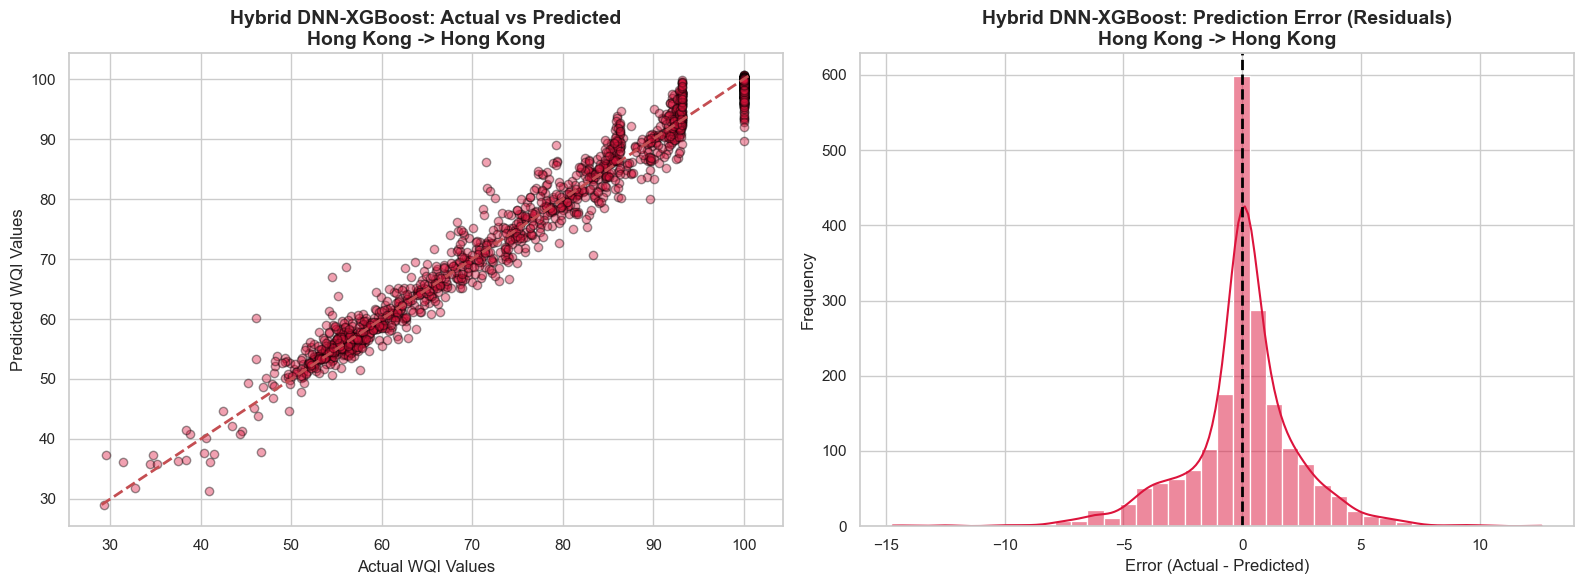

In [110]:
plot_model_residual_evaluation(
    y_test_hybrid_hongkong,
    y_pred_hybrid_hongkong,
    model_name="Hybrid DNN-XGBoost",
    evaluation_name="Hong Kong -> Hong Kong",
    color="crimson"
)

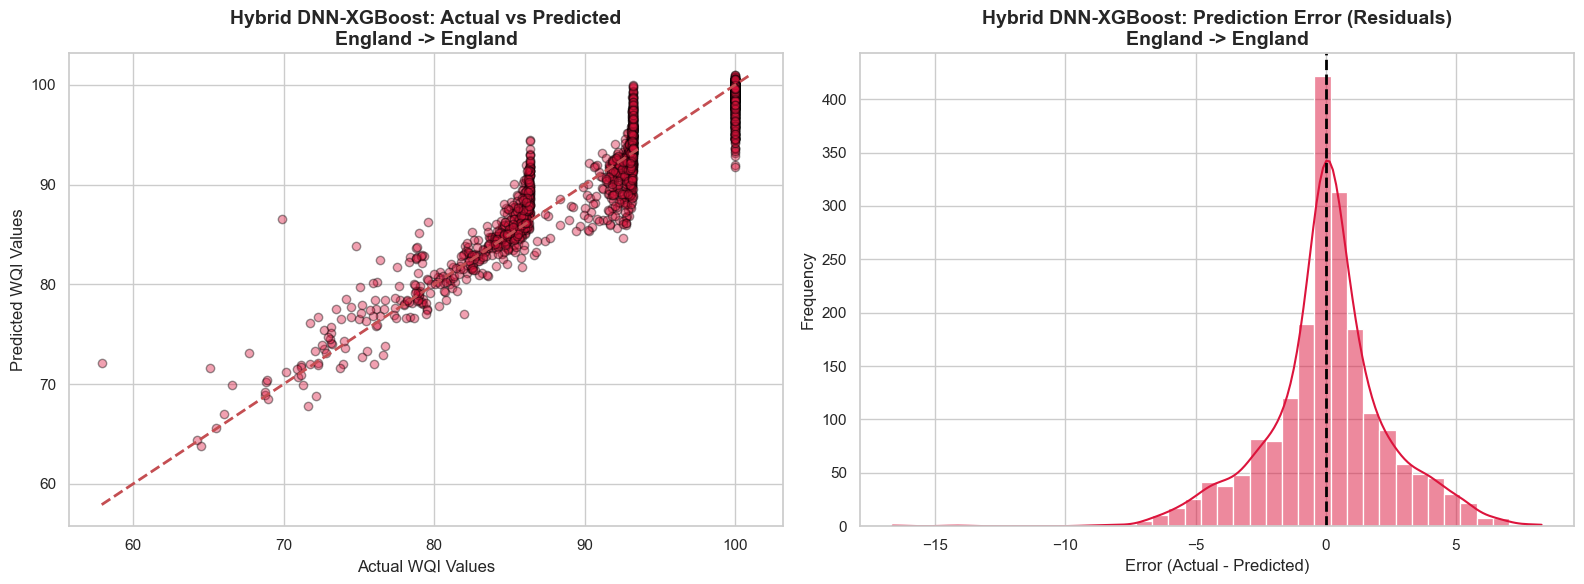

In [111]:
plot_model_residual_evaluation(
    y_test_hybrid_england,
    y_pred_hybrid_england,
    model_name="Hybrid DNN-XGBoost",
    evaluation_name="England -> England",
    color="crimson"
)

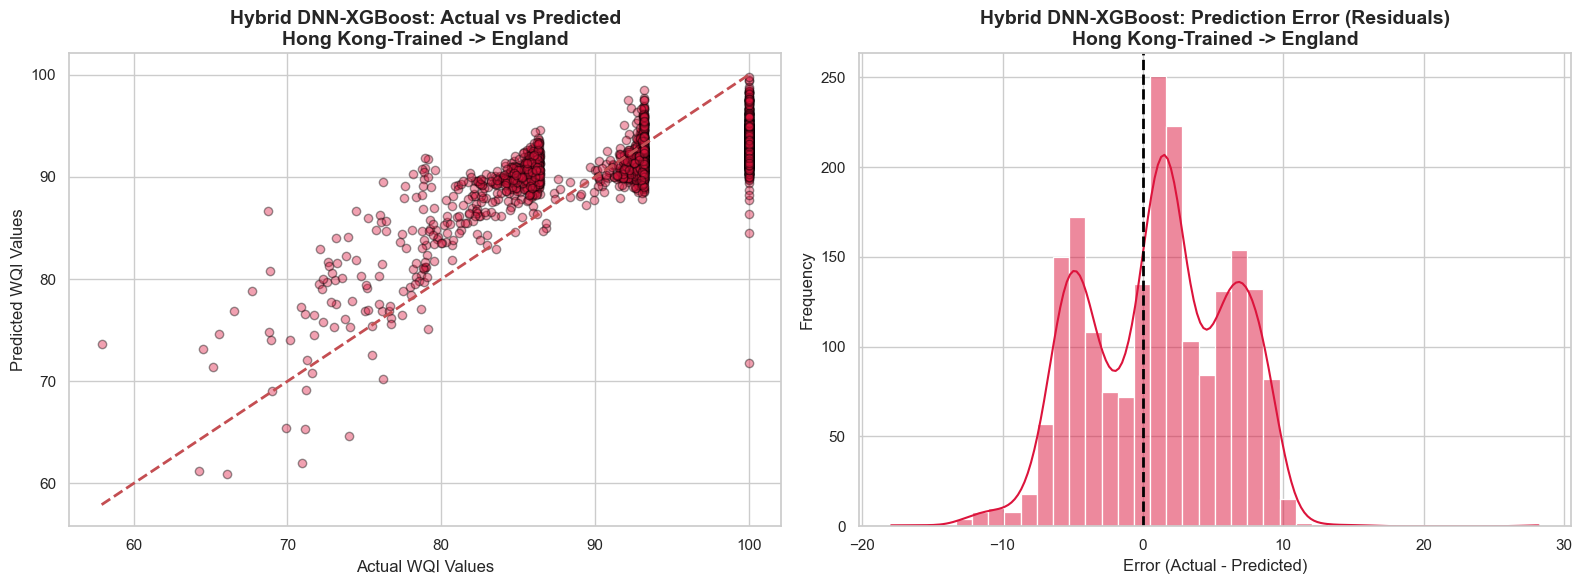

In [112]:
plot_model_residual_evaluation(
    y_test_hybrid_hongkong_to_england,
    y_pred_hybrid_hongkong_to_england,
    model_name="Hybrid DNN-XGBoost",
    evaluation_name="Hong Kong-Trained -> England",
    color="crimson"
)

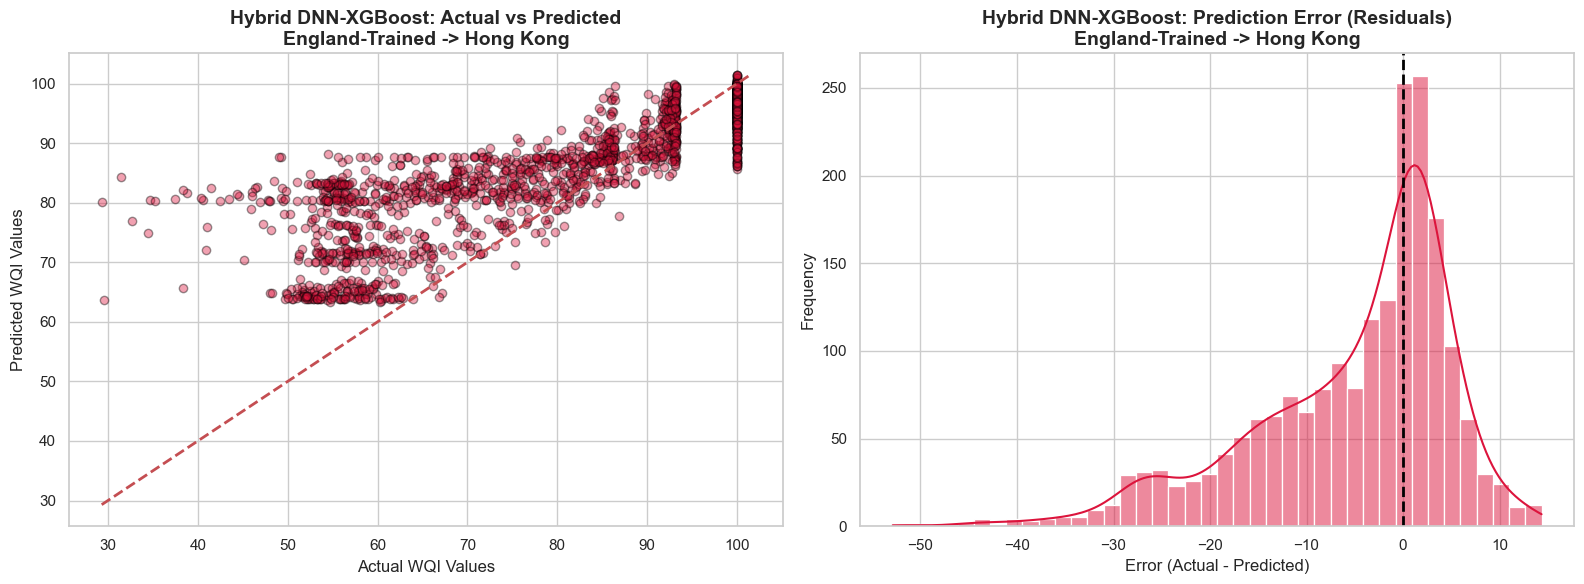

In [113]:
plot_model_residual_evaluation(
    y_test_hybrid_england_to_hongkong,
    y_pred_hybrid_england_to_hongkong,
    model_name="Hybrid DNN-XGBoost",
    evaluation_name="England-Trained -> Hong Kong",
    color="crimson"
)

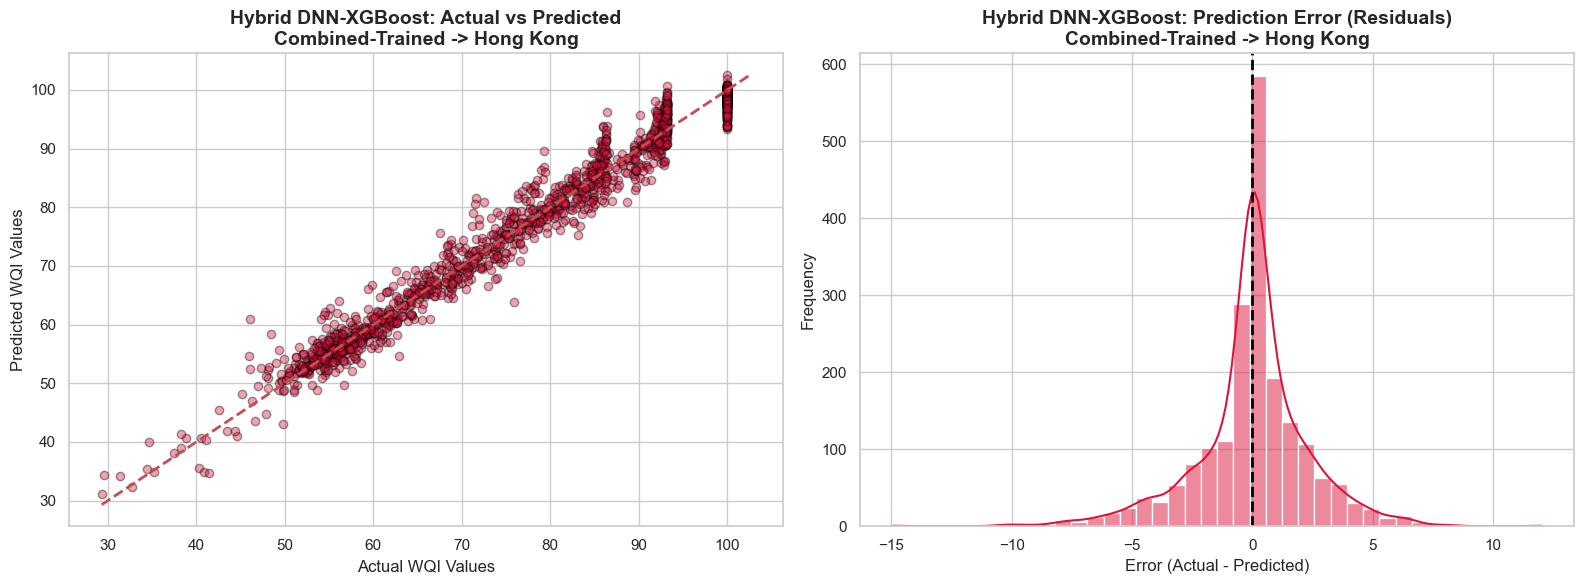

In [114]:
plot_model_residual_evaluation(
    y_test_hybrid_combined_to_hongkong,
    y_pred_hybrid_combined_to_hongkong,
    model_name="Hybrid DNN-XGBoost",
    evaluation_name="Combined-Trained -> Hong Kong",
    color="crimson"
)

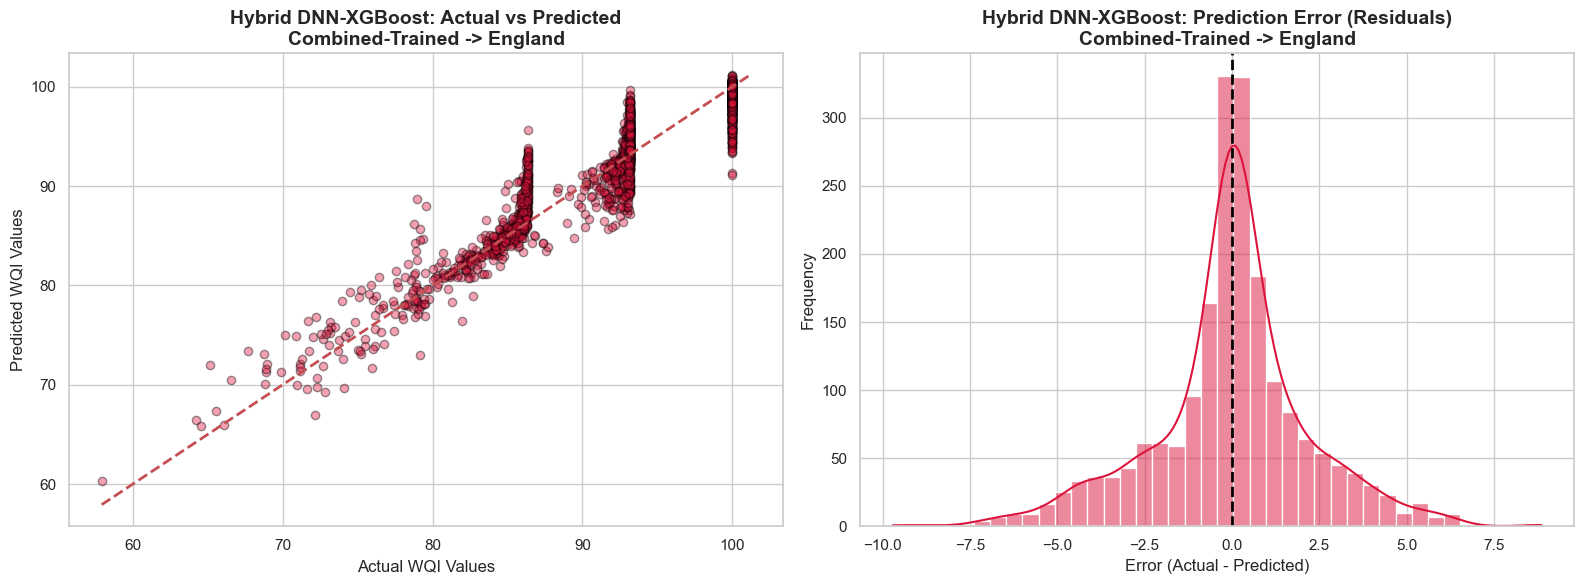

In [115]:
plot_model_residual_evaluation(
    y_test_hybrid_combined_to_england,
    y_pred_hybrid_combined_to_england,
    model_name="Hybrid DNN-XGBoost",
    evaluation_name="Combined-Trained -> England",
    color="crimson"
)

In [116]:
# Final Model Evaluation Results

final_evaluation_results = pd.DataFrame([
    # Hong Kong Dataset
    {
        "Evaluation": "Hong Kong",
        "Model": "DNN",
        "RMSE": rmse_dnn_hongkong,
        "MAE": mae_dnn_hongkong,
        "R2": r2_dnn_hongkong
    },
    {
        "Evaluation": "Hong Kong",
        "Model": "LightGBM",
        "RMSE": rmse_lgbm_hongkong,
        "MAE": mae_lgbm_hongkong,
        "R2": r2_lgbm_hongkong
    },
    {
        "Evaluation": "Hong Kong",
        "Model": "XGBoost",
        "RMSE": rmse_xgboost_hongkong,
        "MAE": mae_xgboost_hongkong,
        "R2": r2_xgboost_hongkong
    },
    {
        "Evaluation": "Hong Kong",
        "Model": "Hybrid DNN-XGBoost",
        "RMSE": rmse_hybrid_hongkong,
        "MAE": mae_hybrid_hongkong,
        "R2": r2_hybrid_hongkong
    },
    
    # England Dataset
    {
        "Evaluation": "England",
        "Model": "DNN",
        "RMSE": rmse_dnn_england,
        "MAE": mae_dnn_england,
        "R2": r2_dnn_england
    },
    {
        "Evaluation": "England",
        "Model": "LightGBM",
        "RMSE": rmse_lgbm_england,
        "MAE": mae_lgbm_england,
        "R2": r2_lgbm_england
    },
    {
        "Evaluation": "England",
        "Model": "XGBoost",
        "RMSE": rmse_xgboost_england,
        "MAE": mae_xgboost_england,
        "R2": r2_xgboost_england
    },
    {
        "Evaluation": "England",
        "Model": "Hybrid DNN-XGBoost",
        "RMSE": rmse_hybrid_england,
        "MAE": mae_hybrid_england,
        "R2": r2_hybrid_england
    },
    # Hong Kong-Trained -> England
    {
        "Evaluation": "Hong Kong -> England",
        "Model": "DNN",
        "RMSE": rmse_dnn_hongkong_to_england,
        "MAE": mae_dnn_hongkong_to_england,
        "R2": r2_dnn_hongkong_to_england
    },
    {
        "Evaluation": "Hong Kong -> England",
        "Model": "LightGBM",
        "RMSE": rmse_lgbm_hongkong_to_england,
        "MAE": mae_lgbm_hongkong_to_england,
        "R2": r2_lgbm_hongkong_to_england
    },
    {
        "Evaluation": "Hong Kong -> England",
        "Model": "XGBoost",
        "RMSE": rmse_xgboost_hongkong_to_england,
        "MAE": mae_xgboost_hongkong_to_england,
        "R2": r2_xgboost_hongkong_to_england
    },
    {
        "Evaluation": "Hong Kong -> England",
        "Model": "Hybrid DNN-XGBoost",
        "RMSE": rmse_hybrid_hongkong_to_england,
        "MAE": mae_hybrid_hongkong_to_england,
        "R2": r2_hybrid_hongkong_to_england
    },
    # England-Trained -> Hong Kong
    {
        "Evaluation": "England -> Hong Kong",
        "Model": "DNN",
        "RMSE": rmse_dnn_england_to_hongkong,
        "MAE": mae_dnn_england_to_hongkong,
        "R2": r2_dnn_england_to_hongkong
    },
    {
        "Evaluation": "England -> Hong Kong",
        "Model": "LightGBM",
        "RMSE": rmse_lgbm_england_to_hongkong,
        "MAE": mae_lgbm_england_to_hongkong,
        "R2": r2_lgbm_england_to_hongkong
    },
    {
        "Evaluation": "England -> Hong Kong",
        "Model": "XGBoost",
        "RMSE": rmse_xgboost_england_to_hongkong,
        "MAE": mae_xgboost_england_to_hongkong,
        "R2": r2_xgboost_england_to_hongkong
    },
    {
        "Evaluation": "England -> Hong Kong",
        "Model": "Hybrid DNN-XGBoost",
        "RMSE": rmse_hybrid_england_to_hongkong,
        "MAE": mae_hybrid_england_to_hongkong,
        "R2": r2_hybrid_england_to_hongkong
    },
    # Combined-Trained -> Hong Kong
    {
        "Evaluation": "Combined -> Hong Kong",
        "Model": "DNN",
        "RMSE": rmse_dnn_combined_to_hongkong,
        "MAE": mae_dnn_combined_to_hongkong,
        "R2": r2_dnn_combined_to_hongkong
    },
    {
        "Evaluation": "Combined -> Hong Kong",
        "Model": "LightGBM",
        "RMSE": rmse_lgbm_combined_to_hongkong,
        "MAE": mae_lgbm_combined_to_hongkong,
        "R2": r2_lgbm_combined_to_hongkong
    },
    {
        "Evaluation": "Combined -> Hong Kong",
        "Model": "XGBoost",
        "RMSE": rmse_xgboost_combined_to_hongkong,
        "MAE": mae_xgboost_combined_to_hongkong,
        "R2": r2_xgboost_combined_to_hongkong
    },
    {
        "Evaluation": "Combined -> Hong Kong",
        "Model": "Hybrid DNN-XGBoost",
        "RMSE": rmse_hybrid_combined_to_hongkong,
        "MAE": mae_hybrid_combined_to_hongkong,
        "R2": r2_hybrid_combined_to_hongkong
    },

    # Combined-Trained -> England
    {
        "Evaluation": "Combined -> England",
        "Model": "DNN",
        "RMSE": rmse_dnn_combined_to_england,
        "MAE": mae_dnn_combined_to_england,
        "R2": r2_dnn_combined_to_england
    },
    {
        "Evaluation": "Combined -> England",
        "Model": "LightGBM",
        "RMSE": rmse_lgbm_combined_to_england,
        "MAE": mae_lgbm_combined_to_england,
        "R2": r2_lgbm_combined_to_england
    },
    {
        "Evaluation": "Combined -> England",
        "Model": "XGBoost",
        "RMSE": rmse_xgboost_combined_to_england,
        "MAE": mae_xgboost_combined_to_england,
        "R2": r2_xgboost_combined_to_england
    },
    {
        "Evaluation": "Combined -> England",
        "Model": "Hybrid DNN-XGBoost",
        "RMSE": rmse_hybrid_combined_to_england,
        "MAE": mae_hybrid_combined_to_england,
        "R2": r2_hybrid_combined_to_england
    }

])

# Round metrics
final_evaluation_results[["RMSE", "MAE", "R2"]] = final_evaluation_results[["RMSE", "MAE", "R2"]].round(4)

final_evaluation_results

,Evaluation,Model,RMSE,MAE,R2
0,Hong Kong,DNN,2.6738,2.0419,0.9774
1,Hong Kong,LightGBM,0.8009,0.4450,0.9980
2,Hong Kong,XGBoost,0.8958,0.4464,0.9975
3,Hong Kong,Hybrid DNN-XGBoost,2.3428,1.5517,0.9826
4,England,DNN,2.7578,2.1782,0.8511
5,England,LightGBM,0.6706,0.2521,0.9912
6,England,XGBoost,0.7411,0.2399,0.9893
7,England,Hybrid DNN-XGBoost,2.3515,1.6593,0.8918
8,Hong Kong -> England,DNN,4.6116,3.8298,0.5838
9,Hong Kong -> England,LightGBM,1.7391,1.1076,0.9408


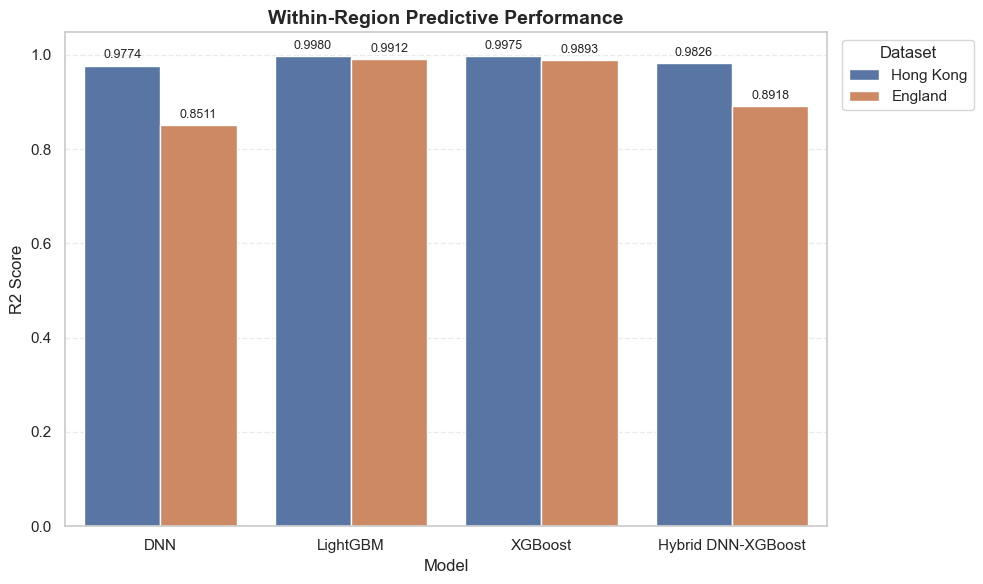

In [117]:
# ============================================================
# Within-Region R2 Comparison
# Models on X-axis
# Hong Kong and England as legend
# ============================================================

# Keep only within-region evaluations
within_region_r2 = final_evaluation_results[final_evaluation_results["Evaluation"].isin(["Hong Kong", "England"])].copy()

model_order = ["DNN", "LightGBM", "XGBoost", "Hybrid DNN-XGBoost"]

plt.figure(figsize=(10, 6))

ax = sns.barplot(data=within_region_r2, x="Model", y="R2",
                 hue="Evaluation", order=model_order,
                 hue_order=["Hong Kong", "England"]
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3, fontsize=9)

ax.set_title("Within-Region Predictive Performance", fontsize=14, fontweight="bold")

ax.set_xlabel("Model", fontsize=12)
ax.set_ylabel("R2 Score", fontsize=12)

ax.legend(title="Dataset", loc="upper left", bbox_to_anchor=(1.01, 1), frameon=True)

ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

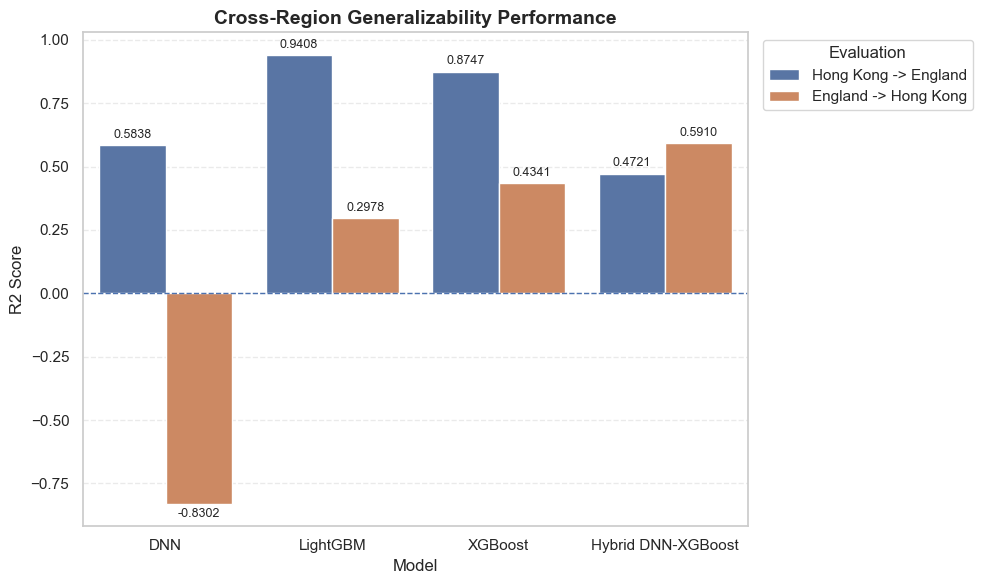

In [118]:
# ============================================================
# Cross-Region Generalizability R2 Comparison
# Models on X-axis
# Cross-region directions as legend
# ============================================================

# Keep only cross-region evaluations
cross_region_r2 = final_evaluation_results[final_evaluation_results["Evaluation"].isin(["Hong Kong -> England", "England -> Hong Kong"])].copy()

model_order = ["DNN", "LightGBM", "XGBoost", "Hybrid DNN-XGBoost"]

plt.figure(figsize=(10, 6))

ax = sns.barplot(data=cross_region_r2, x="Model", y="R2",
                 hue="Evaluation", order=model_order, hue_order=["Hong Kong -> England", "England -> Hong Kong"]
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3, fontsize=9)

ax.set_title("Cross-Region Generalizability Performance", fontsize=14, fontweight="bold")

ax.set_xlabel("Model", fontsize=12)
ax.set_ylabel("R2 Score", fontsize=12)

ax.legend(title="Evaluation", loc="upper left", bbox_to_anchor=(1.01, 1), frameon=True)

# Zero reference line because cross-region R2 can be negative
ax.axhline(y=0, linestyle="--", linewidth=1)

ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

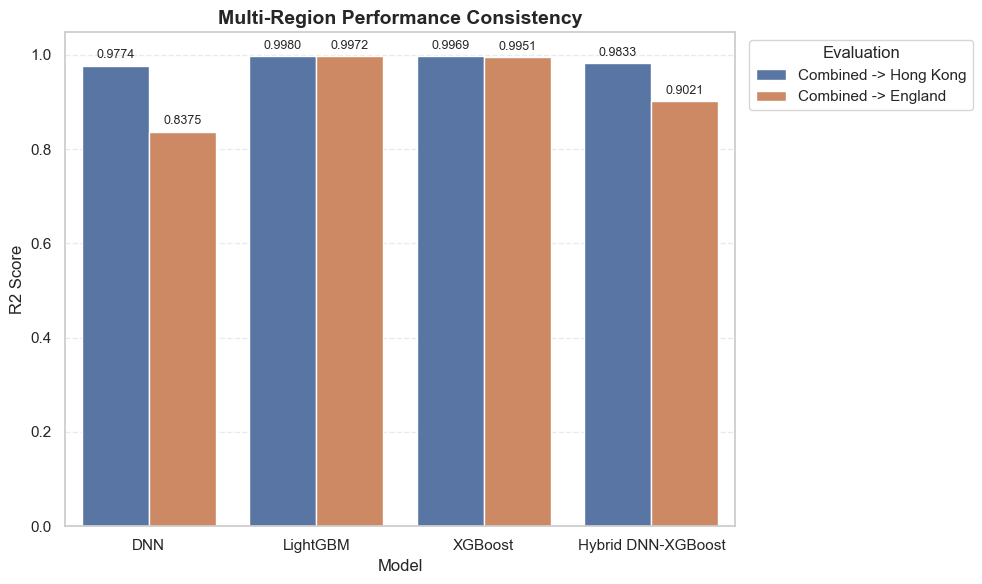

In [119]:
# ============================================================
# Multi-Region R2 Comparison
# Models on X-axis
# Combined -> Hong Kong and Combined -> England as legend
# ============================================================

# Keep only multi-region evaluations
multi_region_r2 = final_evaluation_results[
    final_evaluation_results["Evaluation"].isin(["Combined -> Hong Kong", "Combined -> England"])].copy()

model_order = ["DNN", "LightGBM", "XGBoost", "Hybrid DNN-XGBoost"]

plt.figure(figsize=(10, 6))

ax = sns.barplot(data=multi_region_r2, x="Model", y="R2",
                 hue="Evaluation", order=model_order,
                 hue_order=["Combined -> Hong Kong", "Combined -> England"]
)

# Add R2 values above bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3, fontsize=9)

ax.set_title("Multi-Region Performance Consistency", fontsize=14, fontweight="bold")

ax.set_xlabel("Model", fontsize=12)
ax.set_ylabel("R2 Score", fontsize=12)

ax.legend(title="Evaluation", loc="upper left", bbox_to_anchor=(1.01, 1), frameon=True)

ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [120]:
feature_comparison = pd.DataFrame({
    "Hong Kong Mean":
        Hong_Kong_River_Water_Quality_df[feature_names].mean(),

    "England Mean":
        England_River_Water_Quality_df[feature_names].mean(),

    "Hong Kong Median":
        Hong_Kong_River_Water_Quality_df[feature_names].median(),

    "England Median":
        England_River_Water_Quality_df[feature_names].median(),

    "Hong Kong Standard Deviation":
        Hong_Kong_River_Water_Quality_df[feature_names].std(),

    "England Standard Deviation":
        England_River_Water_Quality_df[feature_names].std(),

    "Hong Kong Min":
        Hong_Kong_River_Water_Quality_df[feature_names].min(),

    "England Min":
        England_River_Water_Quality_df[feature_names].min(),

    "Hong Kong Max":
        Hong_Kong_River_Water_Quality_df[feature_names].max(),

    "England Max":
        England_River_Water_Quality_df[feature_names].max()
})

feature_comparison.round(4)

,Hong Kong Mean,England Mean,Hong Kong Median,England Median,Hong Kong Standard Deviation,England Standard Deviation,Hong Kong Min,England Min,Hong Kong Max,England Max
EC,5566.1044,644.7449,291.0000,593.7000,10424.9072,140.1182,2.0000,9.5000,56672.0000,6002.1000
Temp_C,24.4726,12.4958,25.1000,12.4000,4.4043,4.9873,8.9000,-0.2000,37.1000,27.4000
SS_mgL,17.4655,10.5650,4.8000,6.8700,85.2948,13.1887,0.2500,0.0000,6600.0000,334.6200
pH,7.5540,7.7486,7.5000,7.6600,0.5113,0.2547,3.3000,4.5800,11.4000,9.0200
TP_mgL,0.5014,0.2685,0.1200,0.2100,1.3742,0.2396,0.0100,0.0060,72.0000,2.8400
NO2_N_mgL,0.1063,0.0310,0.0240,0.0152,0.2465,0.0659,0.0010,0.0000,4.7000,2.8333
NO3_N_mgL,1.0548,7.4459,0.6400,6.6173,1.3123,4.0371,0.0010,0.0000,40.0000,36.7227
DO_mgL,7.6318,8.3760,7.9000,8.0000,1.8301,3.1964,0.7000,1.6100,18.6000,121.6000
Al_mgL,0.1663,0.0416,0.0700,0.0520,2.3518,0.0497,0.0250,0.0000,320.0000,1.3602
Fe_mgL,0.3251,0.0767,0.1500,0.1080,0.6496,0.0646,0.0250,0.0000,26.0000,0.9032


In [121]:
mean_hongkong = Hong_Kong_River_Water_Quality_df[feature_names].mean()
mean_england = England_River_Water_Quality_df[feature_names].mean()

std_hongkong = Hong_Kong_River_Water_Quality_df[feature_names].std()
std_england = England_River_Water_Quality_df[feature_names].std()

pooled_std = np.sqrt((std_hongkong**2 + std_england**2) / 2)
standardized_difference = ((mean_hongkong - mean_england).abs() / pooled_std)

distribution_shift = (standardized_difference.sort_values(ascending=False).to_frame("Standardized Difference"))

distribution_shift

,Standardized Difference
Temp_C,2.545648
NO3_N_mgL,2.129124
NDWI,1.014467
NDVI,0.779602
MNDWI,0.693212
EC,0.667557
Mn_mgL,0.555456
Fe_mgL,0.538169
blue,0.500577
red,0.499233


In [ ]:
!gsutil cp model/* gs://river-water-quality-bucket/model/

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying file://model/best_hybrid_nn_xgb_model.pkl [Content-Type=application/octet-stream]...
Copying file://model/best_nn_model.pth [Content-Type=application/octet-stream]...
Copying file://model/feature_cols.pkl [Content-Type=application/octet-stream]...
Copying file://model/scaler.pkl [Content-Type=application/octet-stream]...      
- [4 files][  1.3 MiB/  1.3 MiB]                                                
==> NOTE: You are performing a sequence of gsutil operations that may
run significantly faster if you instead use gsutil -m cp ... Please
see the -m section under "gsutil help options" for further information
about when gsutil -m can be advantageous.

Copying file://model/xgb_model.pkl [Content-Type=application/octet-stre